# I. Ship Motion Prediction

## Prediction Horizons in Ship Motion and Maritime AI

Artificial intelligence has recently been applied to a wide range of prediction problems in maritime engineering. Depending on the prediction horizon, the objectives, input information, physical characteristics, and suitable AI models differ significantly. Therefore, selecting an appropriate prediction framework requires understanding both the temporal scale of the problem and the underlying physical dynamics.

**Short-term prediction** mainly focuses on predicting ship motions over the next few seconds to several tens of seconds. Typical applications include **helicopter landing assistance**, **electric propulsion control during acceleration**, and real-time motion stabilization. Since the future dynamics are dominated by the ship's inertia, historical motion time series alone often provide sufficient information without explicitly modeling external disturbances. Consequently, recurrent neural networks (RNNs), Temporal Convolutional Networks (TCNs), and their modern variants have become the dominant AI architectures for this task.

**Medium-term prediction** extends the forecasting horizon to several tens of seconds or several minutes. In this regime, external environmental disturbances—including **waves, wind, and ocean currents**—become increasingly important, and AI models must learn the interactions between ship dynamics and these environmental conditions. Recent research has shifted from simulation-based studies toward **full-scale onboard measurements**, where real operational data are used to improve the realism and robustness of prediction models.

**Long-term prediction** primarily relies on operational data rather than motion responses. Large-scale datasets, such as **AIS trajectories**, weather information, and voyage records, are commonly used to develop AI models for **fuel consumption estimation**, **Estimated Time of Arrival (ETA)** prediction, and **route optimization**. Because these problems involve large spatial and temporal scales, foundation models and large-scale sequence modeling techniques have recently attracted considerable attention.

**Maneuvering prediction** differs from the previous categories because ship motions often change relatively slowly during maneuvering operations. This makes it difficult for deep learning models to learn sufficiently informative temporal features from conventional maneuvering datasets. One of the major research challenges is therefore the development of **random maneuvering scenarios**, which generate diverse dynamic responses and provide richer datasets for training AI-based maneuvering prediction models.

The following table summarizes the major differences among short-term, medium-term, long-term, and maneuvering prediction problems in terms of prediction horizon, objectives, input information, dominant physical characteristics, representative research topics, and commonly adopted AI methodologies.

| Category | Short-term | Medium-term | Long-term | Maneuvering |
|---|---|---|---|---|
| **Prediction Horizon** | A few seconds to several tens of seconds | Several tens of seconds to several minutes | Several tens of minutes to several days | Several tens of seconds to several minutes |
| **Primary Objective** | Immediate motion prediction and control | Future ship motion prediction | Voyage planning and operational efficiency analysis | Maneuvering performance and trajectory prediction |
| **Input Information** | Historical ship motion time series | Ship motion with external disturbances (waves, wind, current, etc.) | AIS, weather, and operational information | Rudder angle, propeller RPM, and ship motion |
| **External Disturbances** | Generally unnecessary | Essential | Environmental and operational information incorporated | Control inputs are the primary external excitation |
| **Dominant Physical Characteristics** | Inertia-dominated dynamics | Nonlinear motion and wave–ship interaction | Operational patterns and environmental variation | Slowly varying dynamics |
| **Representative Research Topics** | Motion Prediction | Motion Prediction, Wave Prediction, Parametric Roll | ETA Prediction, Fuel Consumption Estimation, Route Optimization | Maneuvering Prediction, Motion Coefficient Estimation |
| **AI Research Characteristics** | Time-series pattern learning | Physics-aware AI, Multi-modal Learning | Large-scale Sequence Modeling | Hybrid Physics + AI |

# II. Evolution of Time-Series Forecasting Technologies

This section summarizes the technological evolution in the field of Time Series Forecasting (TSF) over the three-year period from 2023 to 2026. Recent time-series data analysis models are shifting away from merely predicting the future based on historical data toward understanding the geometric structure of data, complex interactions among variables, and the incorporation of physical laws. Studies presented at top-tier artificial intelligence conferences such as ICLR, NeurIPS, ICML, AAAI, and KDD have called for a fundamental reconsideration of everything from the basic units used to process time-series data to model optimization methods.[1] This report analyzes these technological trends and discusses their applicability to autonomous operation domains requiring high levels of safety, particularly ship operation.

## 1. Reconstruction of Transformer Architectures: Focusing on PatchTST and iTransformer

The role of Transformers in time-series forecasting began to change in 2023. The computational inefficiency and loss of local semantic information caused by early Transformer models, which directly adopted the sequential tokenization approach used in natural language processing (NLP), began to be alleviated with the emergence of new architectures.[3]

### 1.1 PatchTST: Interpreting a Time Series as 64 Words

PatchTST introduced an approach that divides and processes time-series data into patches rather than handling each individual time point separately. Conventional Transformer-based models treated the scalar value at each time point as a single token, resulting in an attention-map complexity of $O(L^2)$, which is proportional to the square of the sequence length $L$. In contrast, PatchTST groups adjacent time points into patches and reduces the computational complexity to $O((L/P)^2)$, where $P$ denotes the patch size.[3][5]

This patching strategy not only reduces computational cost but also helps preserve the local semantics of time-series data. A single time point is often insufficient to convey meaningful information by itself, whereas data grouped into patches more clearly reveal patterns such as trends and seasonality.[6] PatchTST also introduced self-supervised learning based on masked patch reconstruction and demonstrated that robust representations can be learned from large-scale unlabeled time-series datasets.[3]

### 1.2 iTransformer: Architectural Inversion and the Capture of Multivariate Correlations

Introduced in 2024, iTransformer proposed a new direction for multivariate time-series forecasting by inverting the Transformer architecture in the temporal and variable dimensions. Unlike conventional models that generate tokens along the temporal axis, iTransformer treats the entire sequence of each variable or channel as a single token.[4]

In this inverted structure, the self-attention mechanism learns inter-variate correlations rather than temporal dependencies.[4] Temporal patterns are instead learned by the feedforward network (FFN) applied independently to each token, which has been reported to be effective in mitigating the non-stationarity of time-series data.[4] iTransformer has demonstrated strong efficiency and multivariate integration capability, particularly on datasets such as meteorological data in which physical relationships among variables are clearly defined.[9]

| Comparison Item | PatchTST | iTransformer |
|---|---|---|
| Token construction unit | Temporal patches | Entire sequence of each variable |
| Attention target | Temporal context within the same variable | Correlations among different variables |
| Computational complexity | $O((L/P)^2)$ | Structure mainly dependent on the number of variables $C$ |
| Main advantage | Optimized processing of long look-back windows | Multivariate information integration and handling of non-stationarity |

## 2. Modern CNNs: The Rise of TimesNet and ModernTCN

In the TSF field, which had been dominated by Transformers, CNN-based models regained competitiveness by adopting modern architectural designs. This can be interpreted as the result of overcoming the limitations of standard CNNs while reflecting the inherent characteristics of time-series data.[10]

### 2.1 2D CNN for Multivariate Time Series (Example 2)

A 2D CNN for multivariate time series arranges multiple variables in multivariate time-series data as rows of an image and simultaneously learns spatial correlations among variables and temporal dynamics. Unlike 1D-based approaches that process each feature as an independent channel, this method directly extracts spatial characteristics through 2D kernels when different variables are physically or logically adjacent.

The input data are organized as a two-dimensional grid of shape $(N, T)$, where $N$ denotes the number of variables and $T$ denotes the temporal length. A 2D convolution kernel slides across this grid and jointly identifies local relationships among variables and temporal patterns. This method is particularly effective in domains where the positional relationships among variables are important, such as sensor data and electroencephalogram analysis. It also offers extensibility by allowing various CNN architectures already validated in computer vision, including ResNet and DenseNet, to be flexibly applied to time-series analysis.

### 2.2 TCN (Temporal Convolutional Network)

A TCN combines causal convolution and dilated convolution to effectively capture long-range dependencies in time-series data. Unlike RNN-based models that require sequential computation, a TCN enables parallel processing through convolution operations and adopts a causal structure so that future data do not affect predictions of the past.

Dilated convolution, which is the core component of a TCN, exponentially increases the spacing between filter elements as the network becomes deeper, allowing the model to secure a very wide receptive field with a relatively small number of layers. A residual connection structure is also introduced to address the vanishing-gradient problem that may occur as the network depth increases and to support stable training. Because TCNs can flexibly process sequences without being restricted to a fixed input length, they have demonstrated high computational efficiency and performance across various domains, including time-series forecasting and classification.

### 2.3 TimesNet: Two-Dimensional Transformation of 1D Time Series and Multi-Periodicity Modeling

TimesNet exploits the fact that real-world time-series data often contain multiple periodicities, such as daily, weekly, and annual cycles. TimesNet extracts dominant periods from the data using the Fast Fourier Transform (FFT) and reconstructs the original one-dimensional time series as a two-dimensional tensor based on those periods.[10]

In the reconstructed 2D tensor, each row represents inter-period variations, whereas each column represents intra-period variations. This transformation allows a 2D convolution kernel to efficiently learn complex time-series patterns in a manner similar to learning textures in images.[10] TimesNet demonstrated consistent performance not only in forecasting but also across major time-series tasks such as missing-value imputation and anomaly detection, suggesting its potential as a general-purpose backbone.[12]

However, this method is not well suited to ship-motion data because ship motions often do not exhibit clearly distinguishable periodicity.

#### 2.3.1 Model Comparison Paper

Paper Title: TimesNet: Temporal 2D-Variation Modeling for General Time Series Analysis
Authors: Haixu Wu, Tengge Hu, et al. (ICLR 2023)

The study theoretically and experimentally demonstrated why transforming a one-dimensional time series into a two-dimensional representation based on multiple periods is more effective than conventional 1D CNNs, including TCNs, and Transformers. The performance evaluation tables in the paper, Tables 1 and 2, show that TimesNet achieved lower errors in terms of MSE and MAE than existing CNN- and Transformer-based models, including TCN, across various tasks such as long-term forecasting, missing-value imputation, and anomaly detection.https://arxiv.org/abs/2210.02186

The experimental-results section of the paper showed that TCNs were unable to sufficiently capture global patterns because of the limitations of their local receptive fields, whereas TimesNet mitigated this problem through the two-dimensional transformation and consequently achieved higher forecasting performance.

#### 2.3.2 Comparison of Model Selection Criteria

| Comparison Item | 2D CNN (TimesNet Approach) | TCN (Temporal Convolutional Network) |
|---|---|---|
| Most suitable data | Data with complex periodicity | Data in which causality and sequence order are important |
| Main advantage | High pattern-capturing ability by simultaneously learning intra-period and inter-period variations | Simple structure, fast parallel computation, and high memory efficiency |
| Main disadvantage | Higher computational complexity than TCN because of FFT and 2D transformation | May be vulnerable to highly complex aperiodic patterns because of fixed dilation settings |
| Performance ranking | Close to the latest SOTA performance | Maintains stable upper-middle-tier performance |

### 2.4 ModernTCN: A ConvNeXt-Based Model (Example 3)

ModernTCN modernizes the conventional Temporal Convolutional Network based on ConvNeXt, a model originally developed in the field of computer vision. To address the narrow receptive-field limitation of conventional TCNs, ModernTCN introduces large-kernel decomposition and depth-wise separable convolution.[11]

This architecture is designed to simultaneously obtain the global information-processing capability of Transformers and the computational efficiency of CNNs. In particular, it maintains channel independence during computation while selectively integrating inter-variable dependencies when necessary, resulting in fast inference speed and low memory usage even on large-scale datasets.[11] These characteristics make it suitable for autonomous ship-operation control systems in which real-time processing is critical.[14]

## 3. Analysis of Multivariate Time-Series Strategies: Theory and Practice of Channel Independence

When processing multivariate time series, the question of whether channel independence (CI) or channel dependence (CD) is more appropriate has been one of the central topics in TSF research over the past three years.[16]

### 3.1 Emergence and Background of the CI Strategy

The CI strategy treats each variable in a multivariate time series as a separate, independent univariate time series and processes all variables using shared model weights.[3] This strategy became a mainstream approach after PatchTST and DLinear demonstrated improved performance through its use.

The effectiveness of CI can be explained by three major factors. First, complex correlations among different variables may act as noise and induce overfitting, and CI can reduce this problem.[16] Second, because the same model processes multiple variables, the effective amount of training data is expanded by the number of variables, resulting in a sample-expansion effect.[17] Third, for data in which individual variables have different scales and distributional properties, CI enables the model to capture the unique temporal patterns of each channel more clearly.[17]

### 3.2 Hybrid Strategies: Balancing CI and CD (Examples 4 and 5)

However, the CI strategy has the limitation that it cannot sufficiently reflect clear interactions among variables, such as causal relationships among economic indicators. To address this limitation, the following hybrid strategies have recently been proposed.[16]

Channel clustering groups variables with similar characteristics and applies CD within each group while applying CI across different groups. Research on the Channel Clustering Module (CCM) reported that this approach can reduce model complexity while improving forecasting accuracy by an average of 2.4% to 7.2%.[16]

The mixed-channels strategy maintains the data-expansion effect while mixing selected channels so that the attention mechanism can selectively learn correlations among variables.[17]

SRA Decider uses statistical indicators such as the Spearman correlation coefficient to dynamically select CI or CD pathways in real time according to the characteristics of the data.[20]

| Strategy | Advantages | Disadvantages | Representative Models |
|---|---|---|---|
| Channel-Independent | Prevention of overfitting, data-augmentation effect, and robustness | Loss of interactions among variables | PatchTST, DLinear |
| Channel-Dependent | Ability to capture complex correlations | Rapid increase in computational cost and high sensitivity to noise | Crossformer, iTransformer |
| Hybrid (Clustering) | Balance between efficiency and accuracy | Overhead caused by the clustering algorithm | CCM, MCformer |

## 4. Automated Model Optimization: Optuna-Based SMBO and NAS Cases

As time-series forecasting models have become increasingly complex, the process of identifying optimal hyperparameters and architectures has become a decisive factor in research success. In particular, the use of Sequential Model-Based Optimization (SMBO) frameworks such as Optuna has become widespread.[21]

### 4.1 Optuna Mechanism and Application to TSF

Optuna uses a define-by-run approach that allows users to dynamically define the search space within the training loop.[21] This is advantageous for Neural Architecture Search (NAS), in which structural changes such as the number of layers or attention heads must be explored in time-series models.[8]

In particular, the Tree-structured Parzen Estimator (TPE) sampler intensively explores parameter regions expected to provide strong performance based on previous trial results. It can also be combined with pruning algorithms that terminate unpromising experiments early, thereby reducing computational-resource consumption.[21] According to a study presented at AAAI 2024, the use of a meta-learning-based surrogate model reduced computational cost to approximately 10% of that required by conventional HEBO while simultaneously improving forecasting accuracy.[24]

### 4.2 Multi-Objective Optimization

In edge-computing environments such as autonomous ship operations, not only forecasting accuracy but also inference latency and memory usage must be optimized. Multi-objective optimization tools such as Optuna’s GPSampler can be used to explore the Pareto front and identify trade-offs between accuracy and efficiency.[23] On a highly volatile electricity-consumption forecasting dataset, models subjected to this type of automated tuning were reported to achieve significantly lower error rates than manually tuned models.[26]

## 5. Physics-Informed Models and Ship-Motion Prediction

To ensure the safety of autonomous ships, predictions must comply with the dynamic characteristics of the vessel rather than merely follow historical trajectories. This requirement has become a central motivation for recent research on Physics-Informed Neural Networks (PINNs).[27]

### 5.1 Mathematical Formulation of Ship Dynamics and Integration into the Loss Function

Ship motions result from the combination of multiple physical characteristics. Physics-informed models add a physics loss to the conventional data loss so that the outputs of a neural network are encouraged to satisfy the governing physical equations.[28] For example, the output of a network predicting ship position can be differentiated to calculate acceleration, and the model can then be trained to minimize the residual produced when the calculated acceleration is substituted into the physical equations.[28]

### 5.2 Performance of PINNs and Hamiltonian Models in Marine Environments

Applications of PINNs to ship-trajectory prediction have shown that they can substantially reduce Estimated Time of Arrival (ETA) errors compared with purely data-driven models, even when only limited data are available.[28] In particular, for submarines or Autonomous Underwater Vehicles (AUVs) performing complex maneuvers in three-dimensional space, Hamiltonian Neural ODE models designed to preserve the total energy of the system have demonstrated favorable performance.[27]

Experimental results showed that a model incorporating physical laws maintained a position error of approximately 3.3 cm after 10 seconds even under complex control inputs. In contrast, the error of a black-box model increased to as much as 5.4 m, indicating a loss of physical consistency.[27] This difference is important for collision-avoidance algorithms in autonomous navigation systems.[27]

## 6. Comparative Analysis for Computational Efficiency and Hardware Deployment

Before deploying a model on an onboard system for an autonomous ship, the number of parameters and inference speed must be compared.[32]

### 6.1 Comparison of Resource Consumption by Architecture

| Model Family | Main Model | Parameter Efficiency | Inference-Speed Characteristics | Suitable Hardware |
|---|---|---|---|---|
| Transformer | PatchTST | Moderate (0.5M–2M) | Patching reduces the burden of long sequences | High-performance GPU/NPU |
| Modern CNN | TimesNet | Very high (from approximately 0.02 MB) | Includes overhead from 2D transformation | Mobile/embedded GPU |
| Linear/MLP | DLinear | Highest level | Extremely fast because of matrix operations | Low-power CPU/FPGA |
| RNN | Bi-LSTM | Low because of sequential processing | Bottleneck occurs with long sequences | General-purpose embedded device |
| SSM | S-Mamba | High | Very fast because of linear complexity | Latest AI accelerators |

### 6.2 Selection of Optimal Models for Autonomous Ship-Operation Environments

For tasks in which real-time processing is the highest priority, such as collision avoidance, ModernTCN or DLinear-based models may be suitable because of their high computational speed. ModernTCN is particularly advantageous for processing data from numerous sensors on large ships in real time because it uses the parallel-processing capability of convolution.[11]

For tasks requiring a long look-back window, such as long-term route planning and weather-response analysis, PatchTST or iTransformer may be appropriate.[3] iTransformer is particularly effective in jointly analyzing the effects of external environmental variables such as wind direction, current, and wave height.[9]

For safety-critical functions with sparse data, physical consistency is important. Therefore, PINN- or Hamiltonian-based models may be suitable for engine-load prediction or ship-motion prediction under extreme weather conditions.[27] These models can provide reliable predictions even when only limited sea-trial data are available.[28]

For periodic-signal analysis, such as engine-vibration analysis or fault diagnosis, FFT-based TimesNet is advantageous when the data exhibit clear periodicity.[10]

## 7. Summary

PatchTST and iTransformer restructured the global information-processing capability of Transformers to better reflect the characteristics of time-series data, while TimesNet and ModernTCN reinterpreted the computational efficiency of CNNs using modern architectural principles.[3]

In particular, the performance of the channel-independence strategy in multivariate processing suggests that separating information according to the data structure may be more important for improving performance than simply combining larger amounts of information.[17] The introduction of physics-informed models into ship-motion prediction also demonstrates that AI is evolving beyond statistical inference toward systems capable of reflecting the constraints of the physical world.[27]

Future time-series forecasting technologies are likely to evolve into hybrid forms that combine time-series foundation models, which learn general patterns from large-scale data, with the physical laws of specific domains.[1] In real-world applications such as autonomous ships, it will be necessary to simultaneously ensure inference efficiency and prediction reliability based on these technological advances.[31]

## Works cited

[1] *1st ICLR Workshop on Time Series in the Age of Large Models* - OpenReview
https://openreview.net/pdf?id=dN9Sxy675T

[2] *Awesome time series forecasting papers and codes* - GitHub
https://github.com/TongjiFinLab/awesome-time-series-forecasting

[3] *PatchTST: Turning 64 Words Into a Time Series Prediction* | by Dong-Keon Kim | Medium
https://medium.com/@kdk199604/patchtst-turning-64-words-into-a-time-series-prediction-7f99477933c1

[4] *iTransformer: The Latest Breakthrough in Time Series Forecasting*
https://www.datasciencewithmarco.com/blog/itransformer-the-latest-breakthrough-in-time-series-forecasting

[5] *A Time Series is Worth 64 Words: Long-term Forecasting with ...*
https://openreview.net/forum?id=Jbdc0vTOcol

[6] *A Time Series is Worth 64 Words: Long-term Forecasting with Transformers* - ResearchGate
https://www.researchgate.net/publication/365820556_A_Time_Series_is_Worth_64_Words_Long-term_Forecasting_with_Transformers

[7] *PatchTST: A Breakthrough in Time Series Forecasting* - Data Science With Marco
https://www.datasciencewithmarco.com/blog/patchtst-a-breakthrough-in-time-series-forecasting

[8] *Optimizing Time Series Forecasting Architectures: A Hierarchical Neural Architecture Search Approach* - arXiv
https://arxiv.org/html/2406.05088v2

[9] *Benchmarking State Space Models, Transformers, and Recurrent Networks for US Grid Forecasting* - arXiv
https://arxiv.org/html/2602.21415v1

[10] *timesnet: temporal 2d-variation modeling* - arXiv
https://arxiv.org/pdf/2210.02186v2/1000

[11] *ModernTCN: A Modern Pure Convolution Structure for General Time Series Analysis* | OpenReview
https://openreview.net/forum?id=vpJMJerXHU

[12] *TimesNet: Temporal 2D-Variation Modeling for General Time Series Analysis*
https://www.researchgate.net/publication/364194544_TimesNet_Temporal_2D-Variation_Modeling_for_General_Time_Series_Analysis

[13] *A Multi-Scale Time–Frequency Complementary Load Forecasting Method for Integrated Energy Systems* - MDPI
https://www.mdpi.com/1996-1073/18/12/3103

[14] *MODERNTCN: A MODERN PURE CONVOLUTION STRUCTURE FOR GENERAL TIME SERIES ANALYSIS* - ICLR Proceedings
https://proceedings.iclr.cc/paper_files/paper/2024/file/86b1437c1e4c3b3c4debff98234a67e7-Paper-Conference.pdf

[15] *ICLR Poster ModernTCN: A Modern Pure Convolution Structure for General Time Series Analysis*
https://iclr.cc/virtual/2024/poster/17520

[16] *From Similarity to Superiority: Channel Clustering for Time Series Forecasting* | OpenReview  
https://openreview.net/forum?id=MDgn9aazo0

[17] *MCformer: Multivariate Time Series Forecasting with Mixed-Channels Transformer* - arXiv  
https://arxiv.org/html/2403.09223v1

[18] *Channel Dependence, Limited Lookback Windows, and the Simplicity of Datasets: How Biased is Time Series Forecasting?* - arXiv
https://arxiv.org/html/2502.09683v1

[19] *Revitalizing Multivariate Time Series Forecasting: Learnable Decomposition with Inter-Series Dependencies and Intra-Series Variations Model* - PolyU Institutional Research Archive
https://ira.lib.polyu.edu.hk/bitstream/10397/108075/1/1452_revitalizing_multivariate_time.pdf

[20] *PatchMamba: Multivariate Time Series Forecasting Model Based on Patch Attention and Mamba*
http://poster-openaccess.com/files/ICIC2025/2630.pdf

[21] *Hyperparameter Optimization with Optuna* - Medium
https://medium.com/@mjgmario/hyperparameter-optimization-with-optuna-8fca06ea5491

[22] *Optuna: A hyperparameter optimization framework* - GitHub
https://github.com/optuna/optuna

[23] *Optuna - A hyperparameter optimization framework*
https://optuna.org/

[24] *Neural Architecture and Hyperparameter ...* - AAAI Publications
https://ojs.aaai.org/index.php/AAAI/article/view/39622/43583

[25] *Dynamic Hyperparameter Importance for Efficient Multi-Objective Optimization*
https://www.researchgate.net/publication/399522473_Dynamic_Hyperparameter_Importance_for_Efficient_Multi-Objective_Optimization

[26] *(PDF) Forecasting Highly Volatile Time Series: An Approach Based on Encoder–Only Transformers* - ResearchGate
https://www.researchgate.net/publication/400037306_Forecasting_Highly_Volatile_Time_Series_An_Approach_Based_on_Encoder-Only_Transformers

[27] *Physics-Informed Dynamics Modeling: Accurate Long-Term Prediction of Underwater Vehicles with Hamiltonian Neural ODEs* - ResearchGate
https://www.researchgate.net/publication/397216913_Physics-Informed_Dynamics_Modeling_Accurate_Long-Term_Prediction_of_Underwater_Vehicles_with_Hamiltonian_Neural_ODEs

[28] *Physics-Informed Neural Networks for Vessel Trajectory Prediction: Learning Time-Discretized Kinematic Dynamics via Finite Differences* - arXiv
https://arxiv.org/html/2506.12029v1

[30] *Machine Learning for Modeling Underwater Vehicle Dynamics: Overview and Insights* - Digital Repositori Mypolycc
https://repositori.mypolycc.edu.my/bitstream/123456789/6894/1/Machine%20Learning%20for%20Modeling%20Underwater%20Vehicles%20Dynamics.pdf

[31] *Automatic Control and Routing of Marine Vessels* - MDPI
https://mdpi-res.com/bookfiles/book/6435/Automatic_Control_and_Routing_of_Marine_Vessels.pdf?v=1775005621

[32] *Advancements in Deep Learning Techniques for Time Series Forecasting in Maritime Applications: A Comprehensive Review* - MDPI
https://www.mdpi.com/2078-2489/15/8/507

[33] *SwinConvNeXt: a fused deep learning architecture for Real-time garbage image classification* - PMC 
https://pmc.ncbi.nlm.nih.gov/articles/PMC11889143/

[34] *TimesNet: Temporal 2D-Variation Modeling for General Time Series Analysis* - 	arXiv:2210.02186, accessed April 16, 2026. 
https://arxiv.org/abs/2210.02186/



# III. Example of Neural Network Models

## 1. Check the Database 

### 1.1. Categorical database

#### Grid-Based Ship Motion Database

The first dataset consists of **64 grid-based operating conditions** generated from combinations of wave heading, mean wave period, and significant wave height. All simulation data were obtained using the **KCS (KRISO Container Ship)** model, which is widely used as a benchmark vessel in ship hydrodynamics and autonomous navigation research.

Each simulation file contains six-degree-of-freedom (6-DOF) ship motion responses recorded over time. This example loads a single dataset (`090_Tm_9.5_HS_3.5.out`) and visualizes the primary motion variables, including surge, heave, rotational motion, and translational/rotational velocities. The purpose of this visualization is to verify the structure of the raw simulation output and to provide an overview of the temporal behavior of the ship under a representative wave condition.


In [16]:
import re
import matplotlib.pyplot as plt

plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
    "axes.unicode_minus": False
})

def format_math_labels(label):
    label = str(label)
    
    if not re.search(r'<(greek|sub|sup)>', label, flags=re.IGNORECASE):
        return label
        
    greek_mapping = {
        'a': 'alpha', 'b': 'beta', 'g': 'gamma', 'd': 'delta', 
        'e': 'epsilon', 'z': 'zeta', 'h': 'eta', 'q': 'theta', 
        'i': 'iota', 'k': 'kappa', 'l': 'lambda', 'm': 'mu', 
        'n': 'nu', 'x': 'xi', 'p': 'pi', 'r': 'rho', 
        's': 'sigma', 't': 'tau', 'u': 'upsilon', 'f': 'phi', 
        'c': 'chi', 'y': 'psi', 'w': 'omega'
    }
    
    def replace_greek(match):
        char = match.group(1).lower()
        latex_name = greek_mapping.get(char, char)
        return f"\\{latex_name}"
    
    label = re.sub(r'<greek>(.*?)</greek>', replace_greek, label, flags=re.IGNORECASE)
    label = re.sub(r'<sub>(.*?)</sub>', r'_{\1}', label, flags=re.IGNORECASE)
    label = re.sub(r'<sup>(.*?)</sup>', r'^{\1}', label, flags=re.IGNORECASE)
    
    return f"${label}$"

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_359460/2405917951.py:10: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_path, skiprows=1, sep='\s+', names=column_names, engine='python')


--- File: 090_Tm_9.5_HS_3.5.out ---
   t(s)         x1(m)         x2(m)       x3(rad)       x4(m/s)       x5(m/s)  \
0   0.1  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
1   0.2  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
2   0.3 -5.692539e-10 -1.279603e-09 -1.657641e-08 -1.622922e-09 -5.026911e-11   
3   0.4 -2.062058e-09 -1.279068e-09 -8.653565e-08 -4.142708e-09  2.449873e-09   
4   0.5 -3.985028e-09  9.613750e-09 -2.684763e-07 -1.317172e-09  1.496388e-08   

      x6(rad/s)  
0  0.000000e+00  
1  0.000000e+00  
2 -7.565340e-09  
3 -3.864943e-08  
4 -1.178788e-07  


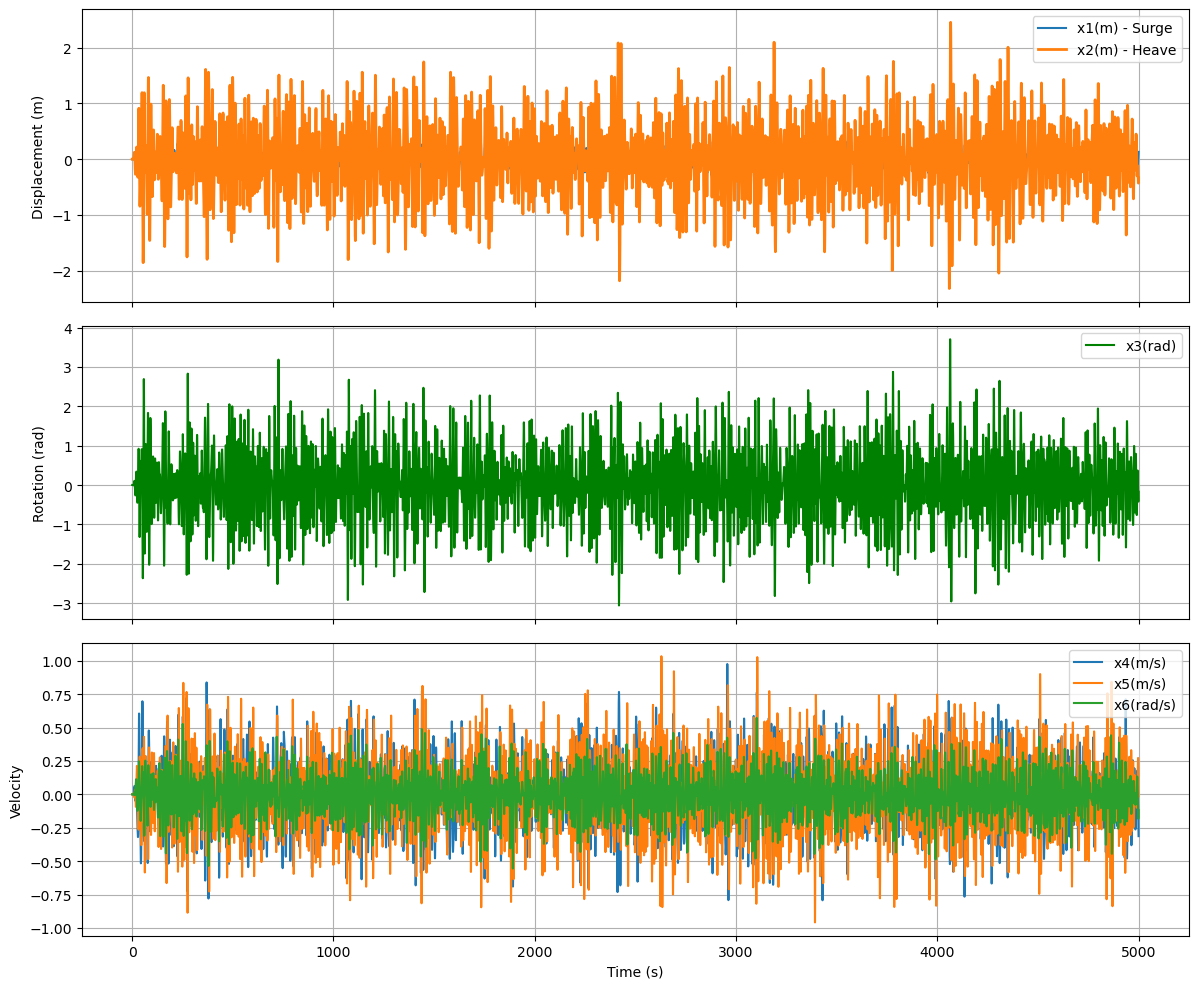

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def test_load_single_file(file_path):
    column_names = ['t(s)', 'x1(m)', 'x2(m)', 'x3(rad)', 'x4(m/s)', 'x5(m/s)', 'x6(rad/s)']
    try:
        df = pd.read_csv(file_path, skiprows=1, sep='\s+', names=column_names, engine='python')
        return df
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

data_dir = "dataset_grid"
sample_file = "090_Tm_9.5_HS_3.5.out"  
path = os.path.join(data_dir, sample_file)

df = test_load_single_file(path)

if df is not None:
    print(f"--- File: {sample_file} ---")
    print(df.head()) 
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # (1) x1, x2 (Surge, Heave)
    axes[0].plot(df['t(s)'], df['x1(m)'], label='x1(m) - Surge')
    axes[0].plot(df['t(s)'], df['x2(m)'], label='x2(m) - Heave', linewidth=2)
    axes[0].set_ylabel('Displacement (m)')
    axes[0].legend()
    axes[0].grid(True)
    
    # (2) x3 (Pitch/Yaw)
    axes[1].plot(df['t(s)'], df['x3(rad)'], color='green', label='x3(rad)')
    axes[1].set_ylabel('Rotation (rad)')
    axes[1].legend()
    axes[1].grid(True)
    
    # (3) x4, x5, x6 
    axes[2].plot(df['t(s)'], df['x4(m/s)'], label='x4(m/s)')
    axes[2].plot(df['t(s)'], df['x5(m/s)'], label='x5(m/s)')
    axes[2].plot(df['t(s)'], df['x6(rad/s)'], label='x6(rad/s)')
    axes[2].set_ylabel('Velocity')
    axes[2].set_xlabel('Time (s)')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: DataFrame is None. Please check the file path and format.")

#### Visualization of Multivariate Ship Motion Time Series

After converting the original simulation outputs into CSV format, the multivariate time-series data can be visualized more clearly. This example illustrates the ship motion dataset corresponding to a wave heading of **90°**, a mean wave period of **9.5 s**, and a significant wave height of **9.5 m**.

The figure displays six motion variables simultaneously. Translational motions are plotted on the left axis, while rotational motions are plotted on the right axis. Greek symbols and subscripts are automatically converted into mathematical notation, providing publication-quality visualization. Such plots are useful for understanding the relationships among multiple motion variables before constructing deep learning models.

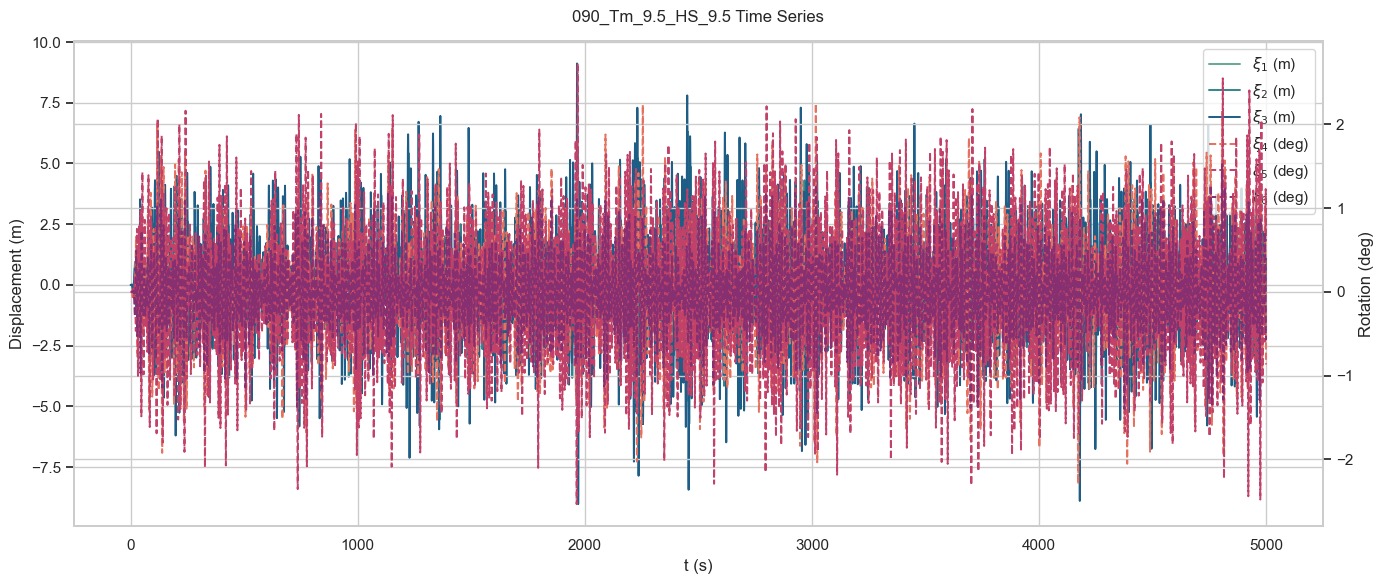

In [ ]:
from pathlib import Path
import html
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")

GREEK_MATH_MAP = {
    "a": r"\alpha", "b": r"\beta", "c": r"\chi", "d": r"\delta",
    "e": r"\epsilon", "f": r"\phi", "g": r"\gamma", "h": r"\eta",
    "i": r"\iota", "j": r"\varphi", "k": r"\kappa", "l": r"\lambda",
    "m": r"\mu", "n": r"\nu", "o": r"o", "p": r"\pi",
    "q": r"\theta", "r": r"\rho", "s": r"\sigma", "t": r"\tau",
    "u": r"\upsilon", "v": r"\varpi", "w": r"\omega", "x": r"\xi",
    "y": r"\psi", "z": r"\zeta",
    "A": r"A", "B": r"B", "C": r"X", "D": r"\Delta",
    "E": r"E", "F": r"\Phi", "G": r"\Gamma", "H": r"H",
    "I": r"I", "J": r"\varPhi", "K": r"K", "L": r"\Lambda",
    "M": r"M", "N": r"N", "O": r"O", "P": r"\Pi",
    "Q": r"\Theta", "R": r"P", "S": r"\Sigma", "T": r"T",
    "U": r"\Upsilon", "V": r"\varPi", "W": r"\Omega", "X": r"\Xi",
    "Y": r"\Psi", "Z": r"Z",
}


def greek_to_mathtext(text: str) -> str:
    return "".join(GREEK_MATH_MAP.get(ch, ch) for ch in text)


def format_column_label(label: str) -> str:
    label = html.unescape(label)

    # Keep Greek symbols and their following subscript in one mathtext block.
    label = re.sub(
        r"<greek>(.*?)</greek>\s*<sub>(.*?)</sub>",
        lambda m: f"${greek_to_mathtext(m.group(1))}_{{{m.group(2)}}}$",
        label,
        flags=re.IGNORECASE,
    )
    label = re.sub(
        r"<greek>(.*?)</greek>",
        lambda m: f"${greek_to_mathtext(m.group(1))}$",
        label,
        flags=re.IGNORECASE,
    )
    label = re.sub(
        r"<sub>(.*?)</sub>",
        lambda m: f"$_{{{m.group(1)}}}$",
        label,
        flags=re.IGNORECASE,
    )
    label = re.sub(r"<[^>]+>", "", label)
    return label.strip()


df = pd.read_csv(CSV_PATH)

time_col = df.columns[0]
left_cols = list(df.columns[1:4])   # columns 2, 3, 4: m
right_cols = list(df.columns[4:7])  # columns 5, 6, 7: deg
label_map = {col: format_column_label(col) for col in df.columns}

sns.set_theme(style="whitegrid", context="notebook")
fig, ax_left = plt.subplots(figsize=(14, 6))
ax_right = ax_left.twinx()

left_palette = sns.color_palette("crest", n_colors=len(left_cols))
right_palette = sns.color_palette("flare", n_colors=len(right_cols))

for col, color in zip(left_cols, left_palette):
    sns.lineplot(data=df, x=time_col, y=col, ax=ax_left, label=label_map[col], color=color, linewidth=1.4)

for col, color in zip(right_cols, right_palette):
    sns.lineplot(data=df, x=time_col, y=col, ax=ax_right, label=label_map[col], color=color, linewidth=1.4, linestyle="--")

ax_left.set_title("090_Tm_9.5_HS_9.5 Time Series", pad=14)
ax_left.set_xlabel(label_map[time_col])
ax_left.set_ylabel("Displacement (m)")
ax_right.set_ylabel("Rotation (deg)")

# Merge legends from the left and right axes into one legend.
left_handles, left_labels = ax_left.get_legend_handles_labels()
right_handles, right_labels = ax_right.get_legend_handles_labels()
ax_left.legend(left_handles + right_handles, left_labels + right_labels, loc="upper right", frameon=True)
if ax_right.get_legend() is not None:
    ax_right.get_legend().remove()

fig.tight_layout()
plt.show()


#### Visualization of the Incident Wave Elevation

In addition to the ship motion responses, the corresponding incident wave elevation is stored separately for each operating condition. This cell visualizes the wave elevation time series associated with the same environmental condition used in the previous ship motion example.

The wave elevation serves as an important reference for understanding the relationship between external wave excitation and the resulting ship motions. These wave signals are also used as target outputs or auxiliary information in several deep learning models developed for ship motion prediction and wave reconstruction.

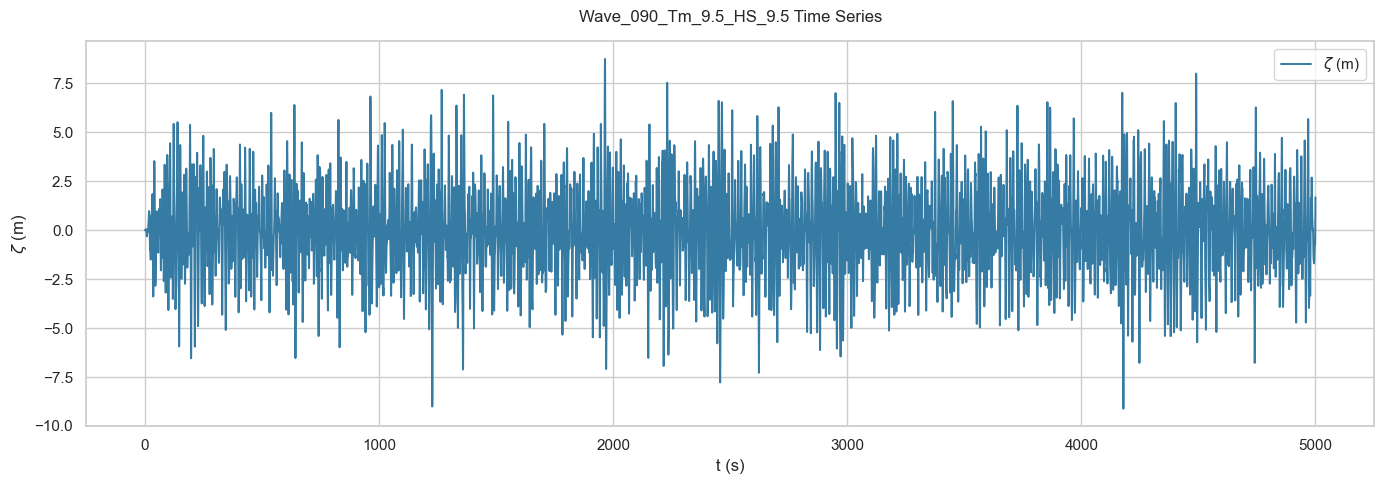

In [2]:
WAVE_CSV_PATH = Path("dataset_grid/Wave_090_Tm_9.5_HS_9.5.csv")

wave_df = pd.read_csv(WAVE_CSV_PATH)
wave_time_col = wave_df.columns[0]
wave_height_col = wave_df.columns[1]
wave_label_map = {col: format_column_label(col) for col in wave_df.columns}

sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=wave_df,
    x=wave_time_col,
    y=wave_height_col,
    ax=ax,
    label=wave_label_map[wave_height_col],
    color=sns.color_palette("mako", n_colors=3)[1],
    linewidth=1.4,
)

ax.set_title("Wave_090_Tm_9.5_HS_9.5 Time Series", pad=14)
ax.set_xlabel(wave_label_map[wave_time_col])
ax.set_ylabel(wave_label_map[wave_height_col])
ax.legend(loc="upper right", frameon=True)

fig.tight_layout()
plt.show()


### 1.2. Regression Database

Unlike the grid-based classification dataset, the regression dataset was generated to support supervised learning tasks for continuous ship motion prediction. Each simulation case is uniquely identified by four environmental and operational parameters: **wave heading ($\chi_M$)**, **mean wave period (Tm)**, **significant wave height (Hs)**, and **ship speed (V)**. The dataset is stored in CSV format, where the filename itself contains the simulation conditions.

This notebook first parses all filenames to automatically extract the corresponding simulation parameters and constructs a condition table summarizing the entire dataset. Duplicate cases are removed to ensure that each operating condition appears only once.

To evaluate the coverage of the dataset, two polar plots are generated. The radial axis represents the significant wave height, while the angular axis represents the wave heading. The first plot uses color to indicate the mean wave period (Tm), whereas the second uses ship speed (V). These visualizations make it straightforward to verify whether the dataset uniformly covers the intended environmental conditions.

Finally, histograms are generated for all four parameters (wave heading, mean wave period, significant wave height, and ship speed). These distributions provide an overview of the parameter space used for model training and help identify possible imbalances or missing operating conditions before constructing regression models.

Parsed unique conditions: 1015
Heading unique: [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180]
Tm range: 4.60 ~ 19.50
Hs range: 0.50 ~ 14.50
V  range: 5.00 ~ 12.30


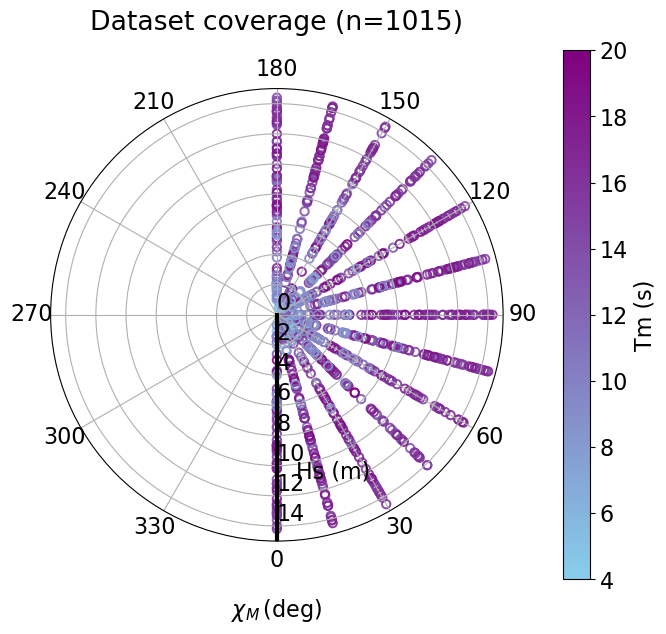

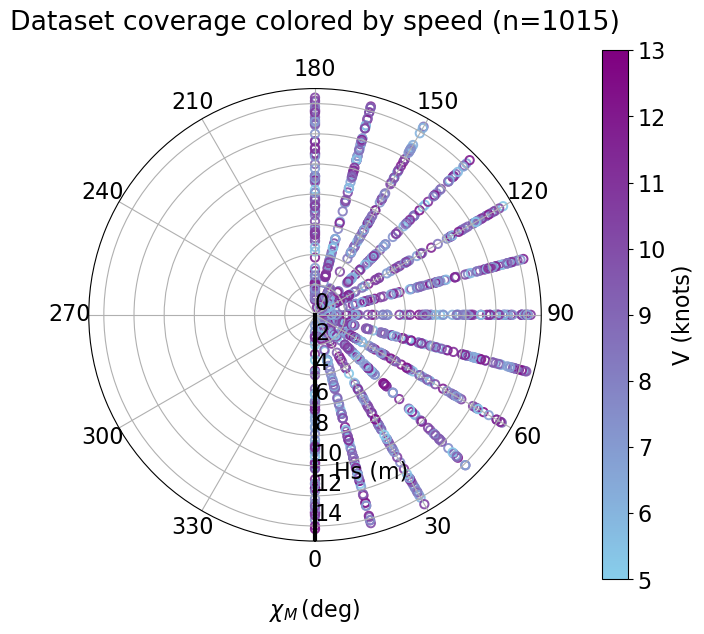

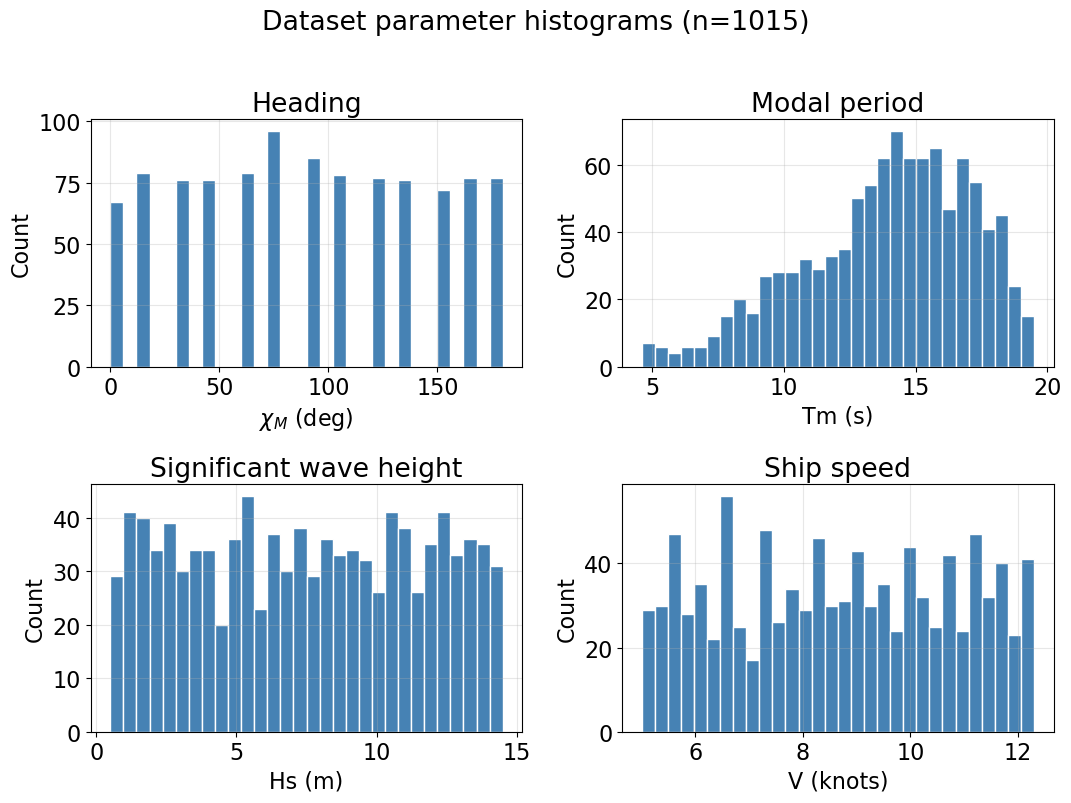

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize

# =============================
# Global font size control
# =============================
FONT_SIZE = 16
plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
})

DATA_DIR = Path("dataset")
OUT_DIR = Path("results_dataset_view")
OUT_DIR.mkdir(parents=True, exist_ok=True)

NAME_RE = re.compile(
    r"^(?:Wave_)?(?P<heading>\d+)_Tm_(?P<Tm>[0-9.]+)_HS_(?P<HS>[0-9.]+)_V_(?P<V>[0-9.]+)\.csv$",
    re.IGNORECASE,
)

# ---------- parse filenames ----------
rows = []
for path in sorted(DATA_DIR.glob("*.csv")):
    m = NAME_RE.match(path.name)
    if m is None:
        continue
    rows.append({
        "path": str(path),
        "name": path.name,
        "is_wave_prefix": path.name.startswith("Wave_"),
        "heading_deg": float(m.group("heading")),
        "Tm": float(m.group("Tm")),
        "HS": float(m.group("HS")),
        "V": float(m.group("V")),
    })

if not rows:
    raise RuntimeError(f"No parsable CSV files found in {DATA_DIR}")

df = (
    pd.DataFrame(rows)
    .sort_values(["is_wave_prefix", "name"])
    .drop_duplicates(subset=["heading_deg", "Tm", "HS", "V"], keep="first")
    .reset_index(drop=True)
)
df.to_csv(OUT_DIR / "dataset_condition_table.csv", index=False)

heading = df["heading_deg"].to_numpy()
hs = df["HS"].to_numpy()
tm = df["Tm"].to_numpy()
speed = df["V"].to_numpy()
rmax = float(np.ceil(hs.max() + 0.5))

print(f"Parsed unique conditions: {len(df)}")
print(f"Heading unique: {sorted(df['heading_deg'].unique().astype(int).tolist())}")
print(f"Tm range: {df['Tm'].min():.2f} ~ {df['Tm'].max():.2f}")
print(f"Hs range: {df['HS'].min():.2f} ~ {df['HS'].max():.2f}")
print(f"V  range: {df['V'].min():.2f} ~ {df['V'].max():.2f}")


def make_polar_scatter(heading_deg, hs, color_values, *, rmax, vmin, vmax, cbar_label, title, out_path=None):
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})

    # South = 0 deg, North = 180 deg, counterclockwise
    ax.set_theta_zero_location("S")
    ax.set_theta_direction(1)

    theta_ticks = np.arange(0, 360, 30)
    ax.set_thetagrids(theta_ticks, labels=[f"{t}" for t in theta_ticks])
    ax.set_xlabel(r"$\chi_{M}\,(\mathrm{deg})$", labelpad=18)

    ax.set_rlim(0, rmax)
    r_step = 1.0 if rmax <= 8 else 2.0
    ax.set_rticks(np.arange(0, rmax + 0.1, r_step))
    ax.set_rlabel_position(0)
    ax.tick_params(axis="y", pad=14)

    cmap = LinearSegmentedColormap.from_list("sky_to_purple", ["skyblue", "purple"])
    norm = Normalize(vmin=vmin, vmax=vmax)

    theta = np.deg2rad(heading_deg)
    edge_cols = cmap(norm(color_values))
    ax.scatter(
        theta, hs,
        marker="o",
        facecolors="none",
        edgecolors=edge_cols,
        linewidths=1.4,
        alpha=0.9,
    )

    ax.plot([0, 0], [0, rmax], linewidth=3.0, color="black", zorder=2)
    ax.text(np.deg2rad(7), 0.7 * rmax, "Hs (m)", rotation=0, ha="left", va="center")

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.10, shrink=0.85)
    cbar.set_label(cbar_label)

    ax.set_title(title, pad=20)
    ax.grid(True)
    plt.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


# 1) color = Tm
make_polar_scatter(
    heading, hs, tm,
    rmax=rmax,
    vmin=float(np.floor(tm.min())),
    vmax=float(np.ceil(tm.max())),
    cbar_label="Tm (s)",
    title=f"Dataset coverage (n={len(df)})",
    out_path=OUT_DIR / "dataset_polar_Hs_heading_color_Tm.png",
)

# 2) color = V
make_polar_scatter(
    heading, hs, speed,
    rmax=rmax,
    vmin=float(np.floor(speed.min())),
    vmax=float(np.ceil(speed.max())),
    cbar_label="V (knots)",
    title=f"Dataset coverage colored by speed (n={len(df)})",
    out_path=OUT_DIR / "dataset_polar_Hs_heading_color_V.png",
)

# 3) histograms
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
specs = [
    ("heading_deg", r"$\chi_{M}$ (deg)", "Heading"),
    ("Tm", "Tm (s)", "Modal period"),
    ("HS", "Hs (m)", "Significant wave height"),
    ("V", "V (knots)", "Ship speed"),
]
for ax, (col, xlabel, title) in zip(axes, specs):
    ax.hist(df[col].to_numpy(), bins=30, color="steelblue", edgecolor="white")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Dataset parameter histograms (n={len(df)})", y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / "dataset_parameter_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. TimesNet(TimeCNN)
### 2.1. Basic TimeCNN

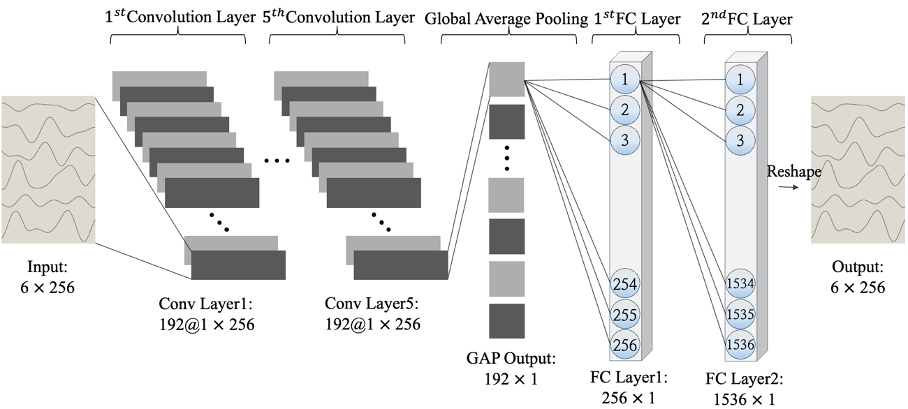

After training the first TimeCNN model, the best-performing checkpoint is loaded to evaluate its prediction performance on an unseen time-series segment. The saved model contains not only the trained network weights but also the preprocessing information, including the input/output configuration, normalization parameters, and the names of the motion variables. This ensures that inference is performed using exactly the same settings as those used during training.

In this example, a representative ship-motion sequence is extracted from the KCS dataset under a wave heading of **90°**, a mean wave period of **9.5 s**, and a significant wave height of **9.5 m**. A 256-step input sequence is provided to the trained TimeCNN model to predict the subsequent 256 time steps.

The resulting figure compares the input sequence, the ground-truth future motions, and the predicted motions for all six degrees of freedom (6-DOF). The vertical dashed line indicates the transition between the observed input window and the prediction horizon. This visualization provides a straightforward assessment of the model's ability to capture both the temporal dynamics and the overall trends of future ship motions.

Loading complete
Used columns: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
Input shape: (256, 6)
Prediction shape: (256, 6)


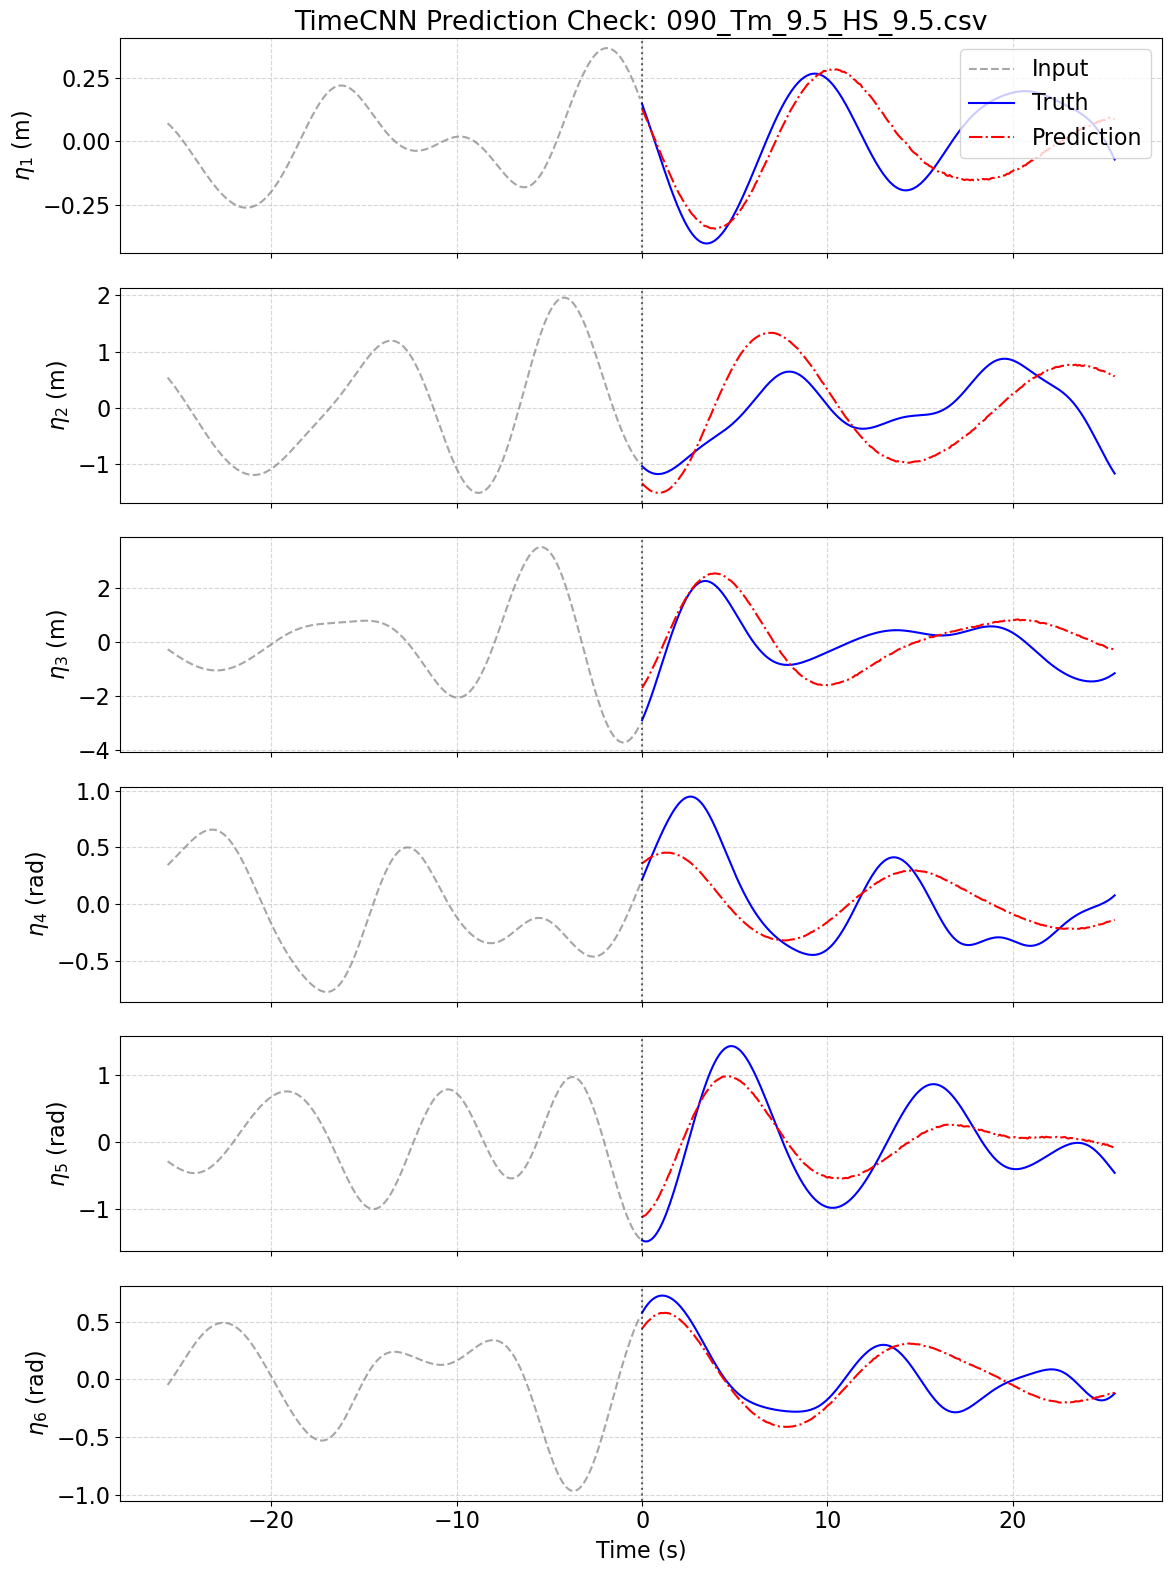

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FlexibleTimeCNN(nn.Module):
    def __init__(
        self,
        in_dof=6,
        channels=64,
        kernel_sizes=None,
        use_bn=True,
        dropout=0.0,
    ):
        super().__init__()

        self.layers = nn.ModuleList()
        for i, ks in enumerate(kernel_sizes):
            padding = ks // 2
            in_ch = in_dof if i == 0 else channels

            conv = nn.Conv1d(
                in_channels=in_ch,
                out_channels=channels,
                kernel_size=ks,
                stride=1,
                padding=padding,
            )
            bn = nn.BatchNorm1d(channels) if use_bn else nn.Identity()
            self.layers.append(nn.Sequential(conv, bn, nn.ReLU()))

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        for block in self.layers:
            x = block(x)
        x = self.dropout(x)
        x = x.permute(0, 2, 1)
        return x

class TimeCNNRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=256,
        out_len=256,
        cnn_channels=64,
        kernel_sizes=None,
        conv_use_bn=True,
        conv_dropout=0.0,
    ):
        super().__init__()
        self.out_dof = out_dof
        self.out_len = out_len

        self.cnn = FlexibleTimeCNN(
            in_dof=in_dof,
            channels=cnn_channels,
            kernel_sizes=kernel_sizes,
            use_bn=conv_use_bn,
            dropout=conv_dropout,
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(cnn_channels, 256),
            nn.ReLU(),
            nn.Linear(256, out_len * out_dof),
            nn.Sigmoid(),
        )

    def forward(self, src):
        x = self.cnn(src)
        x = x.permute(0, 2, 1)
        x = self.global_pool(x)
        x = self.fc(x)
        x = x.view(-1, self.out_len, self.out_dof)
        return x

MODEL_PATH = "models_TimeCNN/timecnn_dataset_grid_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
dof_cols = checkpoint["dof_cols"]
time_col = checkpoint["time_col"]
data_min = checkpoint["data_min"]
data_range = checkpoint["data_range"]

model = TimeCNNRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    cnn_channels=model_config["cnn_channels"],
    kernel_sizes=model_config["kernel_sizes"],
    conv_use_bn=model_config["conv_use_bn"],
    conv_dropout=model_config["conv_dropout"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loading complete")
print("Used columns:", dof_cols)

CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

start_idx = 210

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("Selected start_idx results in IN_LEN + OUT_LEN exceeding data length.")

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_scaled = model(x_tensor).squeeze(0).cpu().numpy()

y_pred_raw = y_pred_scaled * data_range + data_min

print("Input shape:", x_raw.shape)
print("Prediction shape:", y_pred_raw.shape)

fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)

sampling_rate = 0.1
t_input = np.arange(-IN_LEN, 0) * sampling_rate
t_future = np.arange(OUT_LEN) * sampling_rate

latex_labels = [
    r"$\eta_1$ (m)", r"$\eta_2$ (m)", r"$\eta_3$ (m)", 
    r"$\eta_4$ (rad)", r"$\eta_5$ (rad)", r"$\eta_6$ (rad)"
]

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", color="gray", alpha=0.7, label="Input")
    ax.plot(t_future, y_true_raw[:, i], color="blue", label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], color="red", linestyle="-.", label="Prediction")
    
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    
    ax.set_ylabel(latex_labels[i]) 
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_title(f"TimeCNN Prediction Check: {CSV_PATH.name}")
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

### 2.2. Optuna Training

### Prediction Example Using the Optuna-Optimized TimeCNN

To improve the prediction performance of the baseline TimeCNN model, hyperparameter optimization was performed using **Optuna**. During the optimization process, multiple model configurations were automatically explored by varying architectural parameters such as the number of residual blocks, convolution kernel sizes, dilation rates, channel dimensions, dropout rate, and pooling size. Each trial was trained and evaluated independently, and the corresponding model checkpoint was saved for later analysis.

This example demonstrates how to load one of the trained Optuna models and evaluate its prediction performance on an unseen ship-motion sequence. Similar to the previous example, a 256-step input sequence is used to predict the following 256 time steps. The resulting figure compares the observed input, the ground-truth future motions, and the predicted motions for all six degrees of freedom (6-DOF). By replacing the checkpoint file (e.g., `trial_0.pt` or `timecnn_optuna_best_full.pt`), users can easily compare the prediction performance of different Optuna trials and identify the most effective model architecture.

모델 로드 완료
사용 컬럼: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
모델 설정: {'model_type': 'Optuna-Dilated-Residual-TimeCNN', 'trial_number': 0, 'in_dof': 6, 'out_dof': 6, 'in_len': 256, 'out_len': 256, 'n_layers': 5, 'channels': 128, 'kernel_sizes': [5, 7, 11, 9, 11], 'dilations': [1, 2, 4, 8, 16], 'dropout': 0.3058807004866907, 'pool_out_len': 4, 'optimizer': 'AdamW', 'lr': 0.00021969913513340345, 'batch_size': 64, 'dilation_mode': 'exp', 'receptive_field': 281}
입력 shape: (256, 6)
예측 shape: (256, 6)


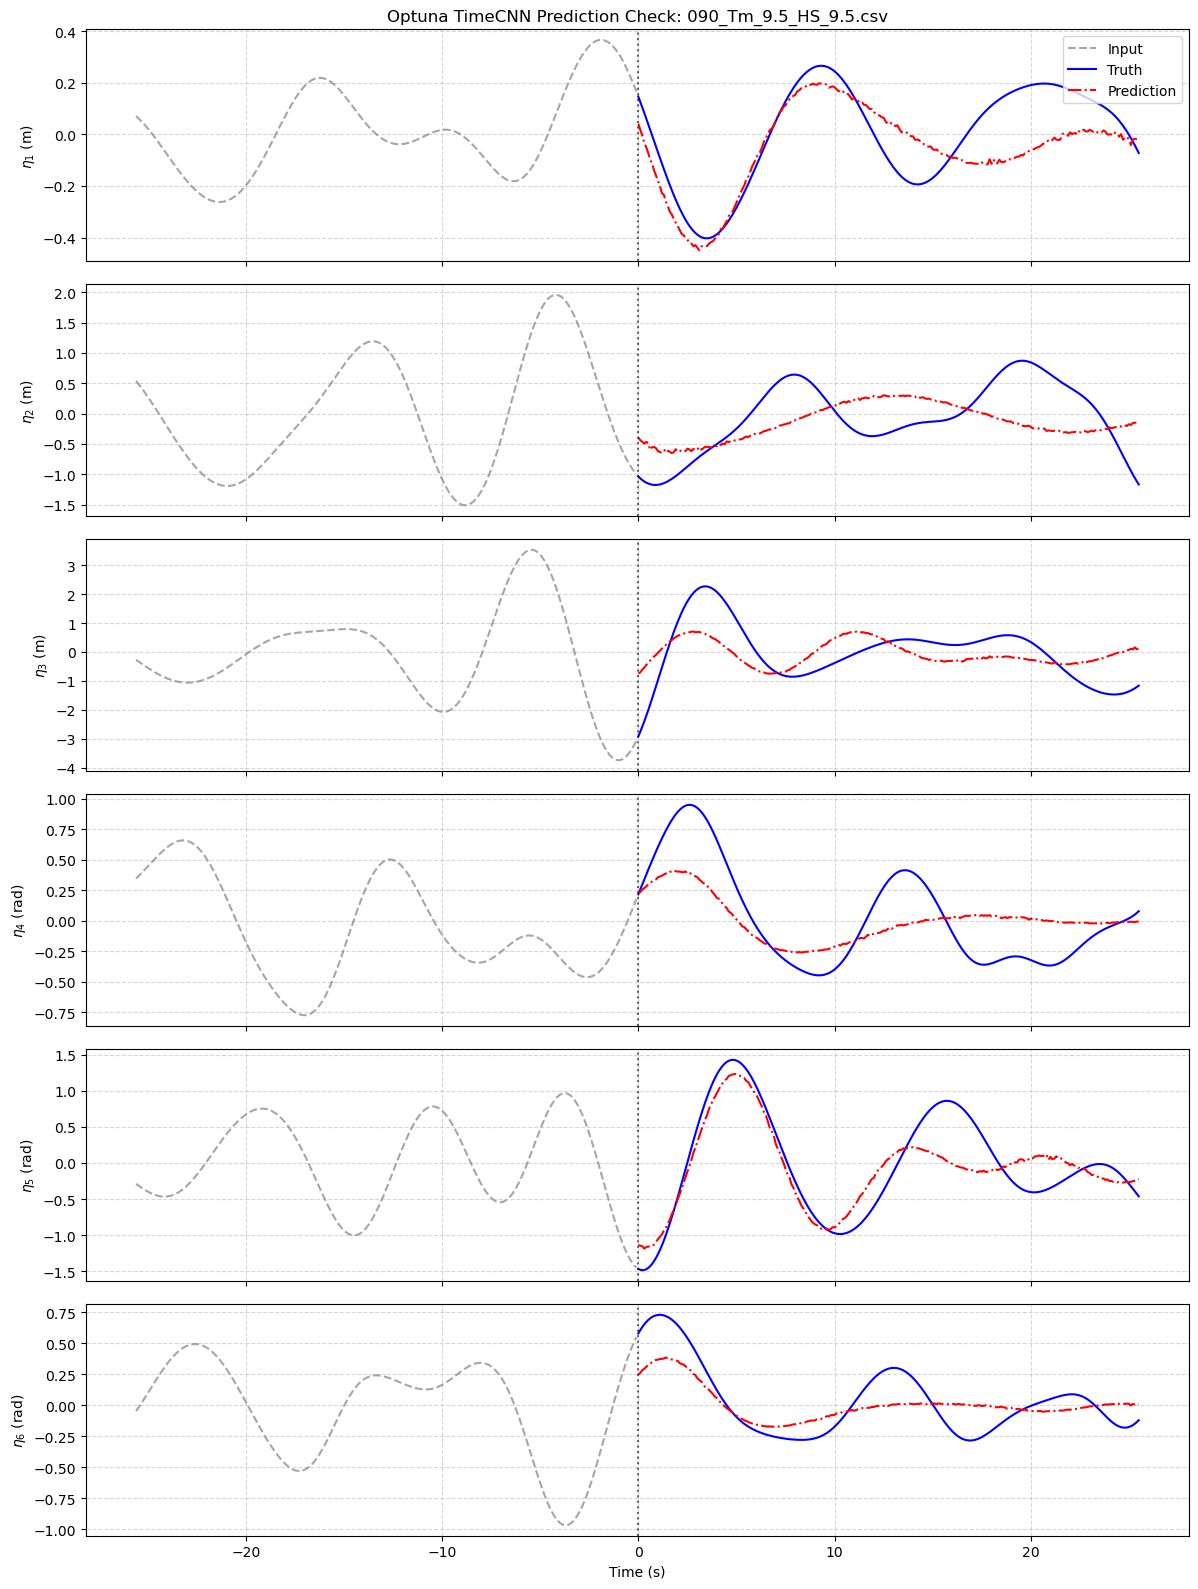

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()

        if kernel_size % 2 == 0:
            raise ValueError(f"kernel_size는 홀수여야 합니다. 현재 값: {kernel_size}")

        padding = (kernel_size - 1) * dilation // 2

        self.conv = nn.Conv1d(
            in_ch,
            out_ch,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation,
            bias=True,
        )
        self.bn = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.shortcut = nn.Identity()
        if in_ch != out_ch:
            self.shortcut = nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=True)

    def forward(self, x):
        res = self.shortcut(x)
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = x + res
        x = self.relu(x)
        return x

class OptunaTimeCNN(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.in_len = config["in_len"]
        self.out_len = config["out_len"]
        self.out_dof = config["out_dof"]
        self.pool_out_len = config["pool_out_len"]

        layers = []
        curr_ch = config["in_dof"]

        for i in range(config["n_layers"]):
            layers.append(
                ResidualBlock(
                    in_ch=curr_ch,
                    out_ch=config["channels"],
                    kernel_size=config["kernel_sizes"][i],
                    dilation=config["dilations"][i],
                    dropout=config["dropout"],
                )
            )
            curr_ch = config["channels"]

        self.feature_extractor = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(self.pool_out_len)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(config["channels"] * self.pool_out_len, 256),
            nn.ReLU(),
            nn.Dropout(config["dropout"]),
            nn.Linear(256, self.out_len * self.out_dof),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)   # (B, C, T)
        x = self.feature_extractor(x)
        x = self.pool(x)         # (B, C, pool_out_len)
        x = self.fc(x)
        x = x.view(-1, self.out_len, self.out_dof)
        return x

# MODEL_PATH = "models_TimeCNN/timecnn_optuna_best_full.pt"
MODEL_PATH = "models_TimeCNN/trials/trial_0.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
dof_cols = checkpoint["dof_cols"]
time_col = checkpoint["time_col"]
data_min = checkpoint["data_min"].astype(np.float32)
data_range = checkpoint["data_range"].astype(np.float32)

model = OptunaTimeCNN(model_config).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loading complete")
print("Used columns:", dof_cols)
print("Model config:", model_config)

CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

start_idx = 210

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("Selected start_idx results in IN_LEN + OUT_LEN exceeding data length.")

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_scaled = model(x_tensor).squeeze(0).cpu().numpy()

# clipping the predictions to [0, 1] range to avoid any out-of-bounds values
# y_pred_scaled = np.clip(y_pred_scaled, 0.0, 1.0)

# inverse scaling
y_pred_raw = y_pred_scaled * data_range + data_min

print("Input shape:", x_raw.shape)
print("Prediction shape:", y_pred_raw.shape)

fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)

sampling_interval = 0.1
t_input = np.arange(-IN_LEN, 0) * sampling_interval
t_future = np.arange(OUT_LEN) * sampling_interval

latex_labels = [
    r"$\eta_1$ (m)", r"$\eta_2$ (m)", r"$\eta_3$ (m)",
    r"$\eta_4$ (rad)", r"$\eta_5$ (rad)", r"$\eta_6$ (rad)"
]

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", color="gray", alpha=0.7, label="Input")
    ax.plot(t_future, y_true_raw[:, i], color="blue", label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], color="red", linestyle="-.", label="Prediction")
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    ax.set_ylabel(latex_labels[i])
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_title(f"Optuna TimeCNN Prediction Check: {CSV_PATH.name}")
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 3. ModernTCN
  
ModernTCN is a modern convolutional neural network architecture designed specifically for time-series analysis by incorporating the design philosophy of ConvNeXt into Temporal Convolutional Networks (TCNs). The input tensor has the shape **(B, T, C) = (B, 256, 6)** and is internally transformed into **(B, C, T)** for one-dimensional convolution. A stem convolution first projects the six input channels into a **128-channel feature space** using a kernel size of **7** while preserving the temporal length through appropriate padding.

The backbone consists of **six stacked ModernTCN blocks**, each employing **depthwise convolution** (`groups = channels`) to perform channel-wise temporal filtering independently. After depthwise convolution, **Channel-wise Layer Normalization** is applied to stabilize feature normalization. A **pointwise (1×1) convolution** is then used to mix information across channels, while the **GELU activation function** improves nonlinear representation capability. Dropout is incorporated within each block for regularization, and residual connections are used throughout the backbone to ensure stable gradient propagation in deep networks. Unlike conventional TCNs, the proposed implementation does **not** employ dilated convolutions; instead, the receptive field increases linearly with the kernel size and the number of stacked blocks. The backbone preserves the temporal dimension throughout feature extraction and produces an output tensor with the shape **(B, T, C)**.

After feature extraction, **Global Average Pooling (GAP)** compresses the temporal dimension into a compact global representation of shape **(B, C, 1)**. The pooled features are flattened and passed through a fully connected prediction head consisting of a **256-unit hidden layer**, which generates the final output. The output layer first predicts a tensor of shape **(B, OUT_LEN × DOF)** and then reshapes it into the final prediction with dimensions **(B, 256, 6)**.

This notebook demonstrates how to load the best-performing ModernTCN checkpoint and evaluate its prediction performance on an unseen ship-motion sequence. A 256-step input window is used to predict the following 256 time steps, and the predicted ship motions are compared with the corresponding ground-truth trajectories for all six degrees of freedom (6-DOF). The resulting visualization provides a direct comparison of the observed input sequence, the reference future motions, and the model predictions, allowing the temporal forecasting capability of ModernTCN to be qualitatively evaluated.


Using device: cuda:0
cuDNN enabled: False
Loading complete
time_col: t (s)
dof_cols: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
model_type: ModernTCN
Input shape: (256, 6)
Prediction shape: (256, 6)


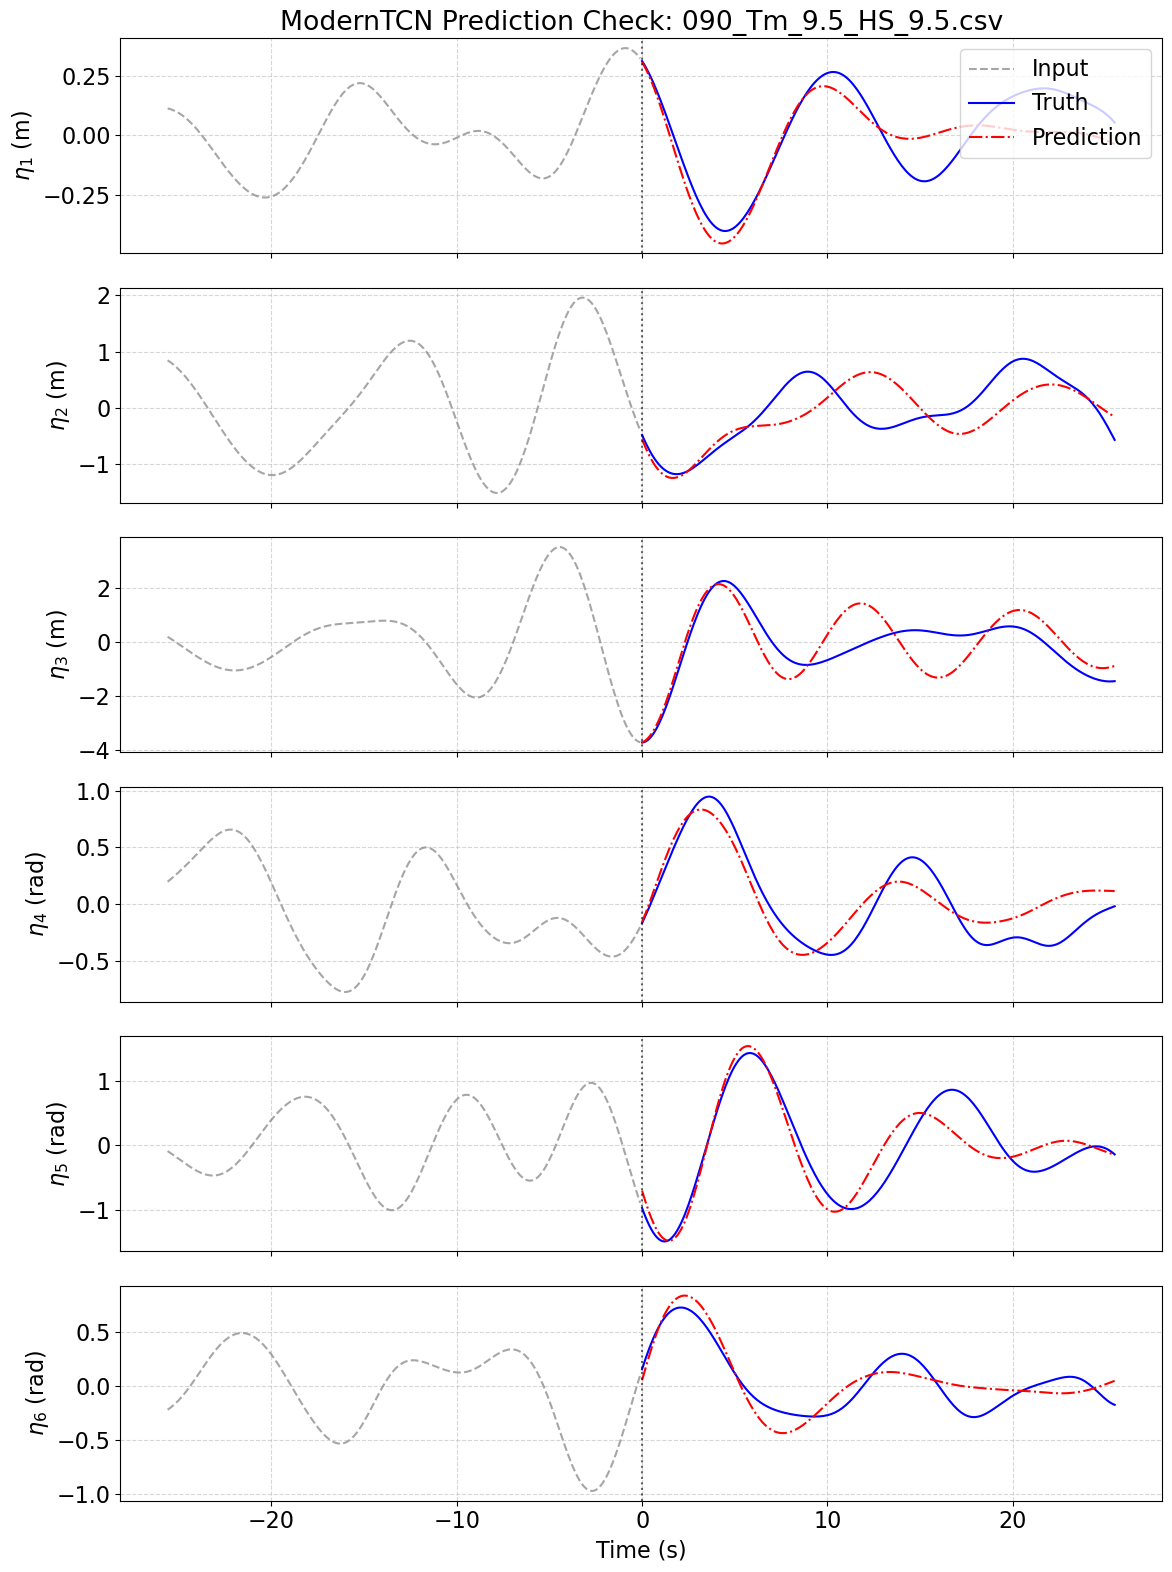

In [6]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    conda_lib = str(Path(conda_prefix) / "lib")
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = (
            f"{conda_lib}:{ld_library_path}" if ld_library_path else conda_lib
        )

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0,1")

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.backends.cudnn.enabled = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("cuDNN enabled:", torch.backends.cudnn.enabled)

class PermuteToChannelsFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)

class PermuteToTimeFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)

class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x

class ModernTCNBlock(nn.Module):
    def __init__(self, channels, kernel_size=31, expansion=2.0, dropout=0.1):
        super().__init__()

        hidden_dim = int(channels * expansion)
        padding = kernel_size // 2

        self.dwconv = nn.Conv1d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=channels,
            bias=True,
        )

        self.norm = ChannelLayerNorm(channels)

        self.pwffn = nn.Sequential(
            nn.Conv1d(channels, hidden_dim, kernel_size=1, bias=True),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, channels, kernel_size=1, bias=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        residual = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwffn(x)
        x = x + residual
        return x

class ModernTCNBackbone(nn.Module):
    def __init__(
        self,
        in_dof=6,
        channels=128,
        num_blocks=6,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
    ):
        super().__init__()

        stem_padding = stem_kernel_size // 2

        self.input_proj = nn.Sequential(
            PermuteToChannelsFirst(),
            nn.Conv1d(in_dof, channels, kernel_size=stem_kernel_size, padding=stem_padding, bias=True),
        )

        self.blocks = nn.ModuleList([
            ModernTCNBlock(
                channels=channels,
                kernel_size=kernel_size,
                expansion=expansion,
                dropout=dropout,
            )
            for _ in range(num_blocks)
        ])

        self.out_permute = PermuteToTimeFirst()

    def forward(self, x):
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        x = self.out_permute(x)
        return x

class ModernTCNRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=256,
        out_len=256,
        channels=128,
        num_blocks=6,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
        head_hidden_dim=256,
    ):
        super().__init__()

        self.out_len = out_len
        self.out_dof = out_dof

        self.backbone = ModernTCNBackbone(
            in_dof=in_dof,
            channels=channels,
            num_blocks=num_blocks,
            kernel_size=kernel_size,
            expansion=expansion,
            dropout=dropout,
            stem_kernel_size=stem_kernel_size,
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len * out_dof),
            nn.Sigmoid(),
        )

    def forward(self, src):
        x = self.backbone(src)
        x = x.transpose(1, 2)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(-1, self.out_len, self.out_dof)
        return x

MODEL_PATH = "models_ModernTCN/moderntcn_dataset_grid_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
time_col = checkpoint["time_col"]
dof_cols = checkpoint["dof_cols"]
data_min = checkpoint["data_min"].astype(np.float32)
data_range = checkpoint["data_range"].astype(np.float32)

model = ModernTCNRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    channels=model_config["channels"],
    num_blocks=model_config["num_blocks"],
    kernel_size=model_config["kernel_size"],
    expansion=model_config["expansion"],
    dropout=model_config["dropout"],
    stem_kernel_size=model_config["stem_kernel_size"],
    head_hidden_dim=model_config["head_hidden_dim"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loading complete")
print("time_col:", time_col)
print("dof_cols:", dof_cols)
print("model_type:", model_config["model_type"])

CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

start_idx = 200

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("Selected start_idx results in IN_LEN + OUT_LEN exceeding data length.")

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

# min-max scaling
x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_scaled = model(x_tensor).squeeze(0).cpu().numpy()

# inverse scaling
y_pred_raw = y_pred_scaled * data_range + data_min

print("Input shape:", x_raw.shape)
print("Prediction shape:", y_pred_raw.shape)

fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)

sampling_rate = 0.1
t_input = np.arange(-IN_LEN, 0) * sampling_rate
t_future = np.arange(OUT_LEN) * sampling_rate

latex_labels = [
    r"$\eta_1$ (m)", r"$\eta_2$ (m)", r"$\eta_3$ (m)", 
    r"$\eta_4$ (rad)", r"$\eta_5$ (rad)", r"$\eta_6$ (rad)"
]

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", color="gray", alpha=0.7, label="Input")
    ax.plot(t_future, y_true_raw[:, i], color="blue", label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], color="red", linestyle="-.", label="Prediction")
    
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    
    ax.set_ylabel(latex_labels[i]) 
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_title(f"ModernTCN Prediction Check: {CSV_PATH.name}")
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

### 3.2. Regression Data: 128 to 128

py_reg_ModernTCN.py

Regression data in the subfolder "dataset" are now trained. 

#### Long-Horizon Ship Motion Prediction Using the Regression Dataset

The following experiments use the **regression dataset** stored in the `dataset` directory rather than the grid-based classification dataset (`dataset_grid`). Unlike the previous dataset, this database consists of continuous ship-motion time series sampled at **2 Hz**, making it suitable for long-horizon sequence-to-sequence prediction. With a sampling interval of **0.5 s**, an input sequence length of **128** corresponds to **64 seconds** of observed ship motion. The objective of this experiment is to predict the subsequent **128 time steps (64 seconds)** using the preceding 64-second observation window.

The proposed model is based on a **causal ModernTCN** architecture, where all convolutions are implemented using causal padding to ensure that future information is never accessed during prediction. This property makes the model appropriate for real-time forecasting and onboard deployment. Unlike the previous implementation that used Global Average Pooling to summarize temporal information, the present model preserves the complete temporal representation throughout the backbone. After feature extraction, a **temporal projection layer** directly maps the input sequence length (128) to the target prediction length (128), followed by a linear output projection that predicts the six ship-motion variables simultaneously.

This notebook demonstrates how to load the best-performing checkpoint trained on the regression dataset and evaluate its performance using the saved test predictions. Rather than performing inference again, the visualization directly loads the stored prediction results from the test dataset, allowing consistent comparison across different models. A randomly selected test sample is displayed, where the predicted trajectories are compared with the corresponding ground-truth ship motions for all six degrees of freedom (6-DOF). This example illustrates the capability of the proposed ModernTCN model to perform **64-second-ahead ship motion prediction** from a **64-second observation window**, providing a benchmark for subsequent long-horizon forecasting experiments.

#### Experiment Output Structure

```text
experiments/
└── CausalModernTCN_dataset_standard_in128_out128_gap/
    ├── models/
    │   └── best_model.pt
    └── results/
        ├── history.csv
        ├── test_metrics.csv
        ├── test_predictions.npz
        ├── experiment_config.json
        └── summary.json



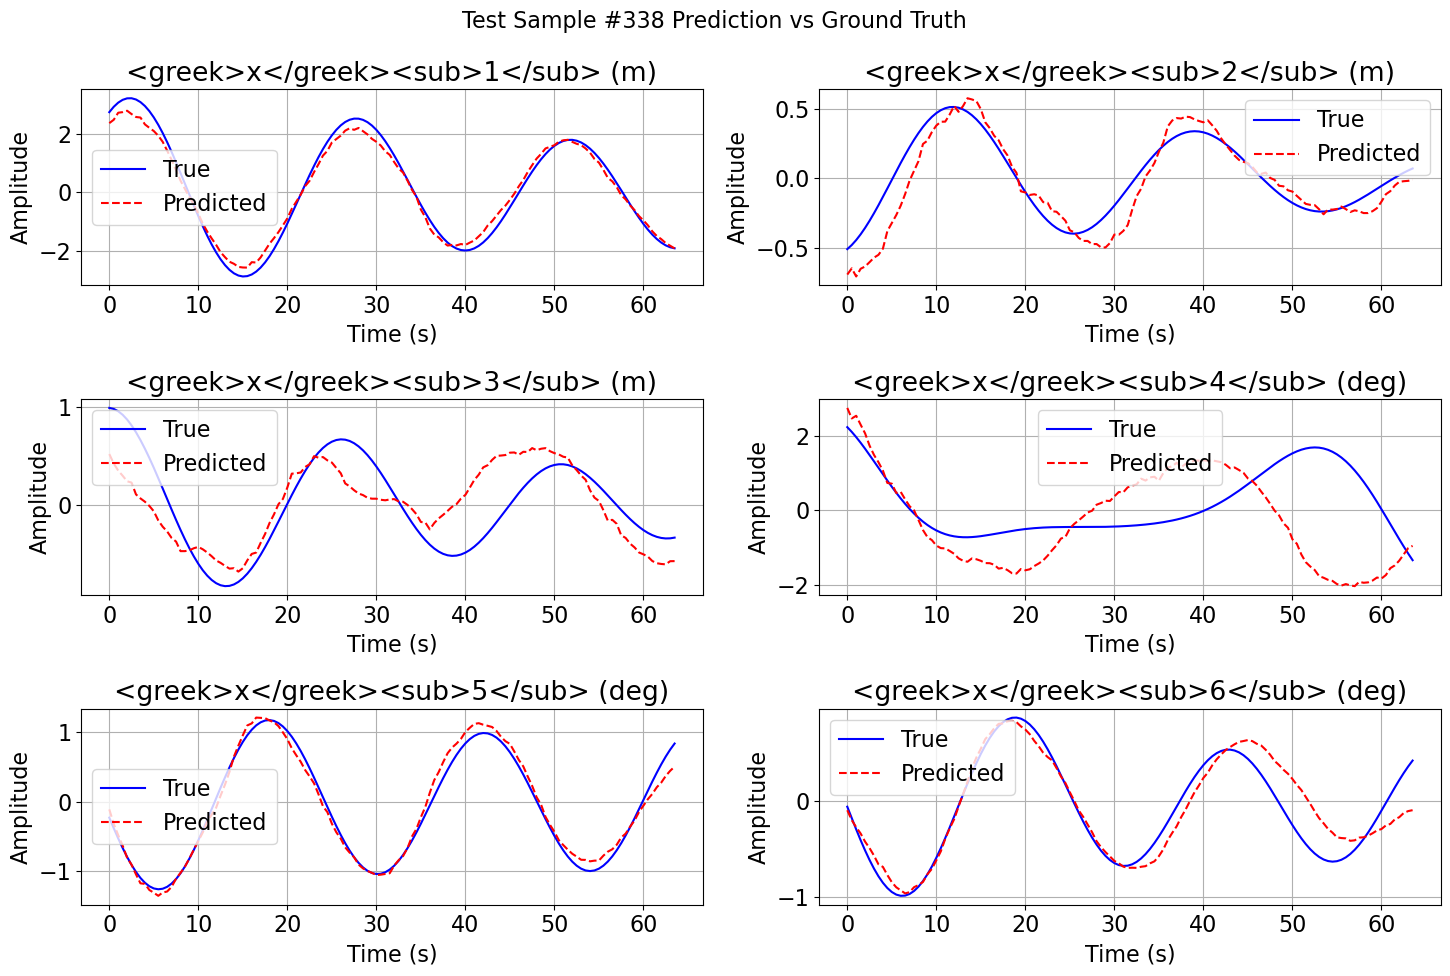

In [8]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

class PermuteToChannelsFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)

class PermuteToTimeFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)

class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x

class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, groups=1, bias=True):
        super().__init__()
        self.left_padding = kernel_size - 1
        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=0,
            groups=groups,
            bias=bias,
        )

    def forward(self, x):
        x = nn.functional.pad(x, (self.left_padding, 0))
        return self.conv(x)

class ModernTCNBlock(nn.Module):
    def __init__(self, channels, kernel_size=31, expansion=2.0, dropout=0.1):
        super().__init__()
        hidden_dim = int(channels * expansion)
        self.dwconv = CausalConv1d(
            in_channels=channels, out_channels=channels, kernel_size=kernel_size, groups=channels, bias=True
        )
        self.norm = ChannelLayerNorm(channels)
        self.pwffn = nn.Sequential(
            nn.Conv1d(channels, hidden_dim, kernel_size=1, bias=True),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, channels, kernel_size=1, bias=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.pwffn(self.norm(self.dwconv(x)))

class ModernTCNBackbone(nn.Module):
    def __init__(self, in_dof=6, channels=128, num_blocks=6, kernel_size=31, expansion=2.0, dropout=0.1, stem_kernel_size=7):
        super().__init__()
        self.input_proj = nn.Sequential(
            PermuteToChannelsFirst(),
            CausalConv1d(in_channels=in_dof, out_channels=channels, kernel_size=stem_kernel_size, bias=True),
        )
        self.blocks = nn.ModuleList([
            ModernTCNBlock(channels=channels, kernel_size=kernel_size, expansion=expansion, dropout=dropout)
            for _ in range(num_blocks)
        ])
        self.out_permute = PermuteToTimeFirst()

    def forward(self, x):
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        return self.out_permute(x)

class ModernTCNRegressor(nn.Module):
    def __init__(self, in_dof=6, out_dof=6, in_len=128, out_len=128, channels=128, num_blocks=6, kernel_size=31, expansion=2.0, dropout=0.1, stem_kernel_size=7, head_dropout=0.1):
        super().__init__()
        self.backbone = ModernTCNBackbone(
            in_dof=in_dof, channels=channels, num_blocks=num_blocks, kernel_size=kernel_size, expansion=expansion, dropout=dropout, stem_kernel_size=stem_kernel_size
        )
        self.temporal_projection = nn.Sequential(
            nn.Linear(in_len, out_len),
            nn.GELU(),
            nn.Dropout(head_dropout),
        )
        self.output_projection = nn.Linear(channels, out_dof)

    def forward(self, src):
        x = self.backbone(src)
        x = self.temporal_projection(x.transpose(1, 2)).transpose(1, 2)
        return self.output_projection(x)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_save_path = Path("experiments/CausalModernTCN_dataset_standard_in128_out128_gap/models/best_model.pt")

if not model_save_path.exists():
    raise FileNotFoundError(f"Model checkpoint not found: {model_save_path}")

checkpoint = torch.load(model_save_path, map_location=device)
cfg = checkpoint["model_config"]

model = ModernTCNRegressor(
    in_dof=cfg["in_dof"], out_dof=cfg["out_dof"], in_len=cfg["in_len"], out_len=cfg["out_len"], 
    channels=cfg["channels"], num_blocks=cfg["num_blocks"], kernel_size=cfg["kernel_size"], 
    expansion=cfg["expansion"], dropout=cfg["dropout"], stem_kernel_size=cfg["stem_kernel_size"], head_dropout=cfg["head_dropout"]
)

state_dict = checkpoint["model_state_dict"]
if list(state_dict.keys())[0].startswith("module."):
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

model.load_state_dict(state_dict)
model.to(device)
model.eval()

data_mean = checkpoint["data_mean"]
data_std = checkpoint["data_std"]
dof_cols = checkpoint["dof_cols"]
in_len = checkpoint["in_len"]
out_len = checkpoint["out_len"]
sampling_interval = checkpoint["sampling_interval"]

npz_path = Path("experiments/CausalModernTCN_dataset_standard_in128_out128_gap/results/test_predictions.npz")

if npz_path.exists():
    data = np.load(npz_path)
    y_true_raw = data['y_true_raw']
    y_pred_raw = data['y_pred_raw']
    
    sample_idx = np.random.randint(0, len(y_true_raw))
    
    true_seq = y_true_raw[sample_idx]
    pred_seq = y_pred_raw[sample_idx]
    
    time_axis = np.arange(out_len) * sampling_interval
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 10))
    fig.suptitle(f"Test Sample #{sample_idx} Prediction vs Ground Truth", fontsize=16)
    
    for i, ax in enumerate(axes.flatten()):
        if i < len(dof_cols):
            ax.plot(time_axis, true_seq[:, i], label='True', color='blue')
            ax.plot(time_axis, pred_seq[:, i], label='Predicted', color='red', linestyle='--')
            ax.set_title(dof_cols[i])
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('Amplitude')
            ax.grid(True)
            ax.legend()
            
    plt.tight_layout()
    plt.show()
else:
    print(f"Test Results File({npz_path}) does not exist.")

### 3.3. Regression Data: 128 to 64

py_reg_ModernTCN_64.py

The second regression experiment investigates the effect of reducing the prediction horizon while maintaining the same observation window. As in the previous experiment, the model is trained using the **regression dataset** sampled at **2 Hz**, where an input sequence length of **128** corresponds to **64 seconds** of observed ship motion. However, unlike the previous model, which predicts the following **128 time steps (64 seconds)**, the output sequence length is reduced to **64 time steps (32 seconds)**.

The network architecture remains identical to the causal ModernTCN framework presented in the previous section. The same backbone extracts temporal features from the 64-second observation window, while the temporal projection layer maps the input sequence length from **128** to an output length of **64**. This configuration enables the model to focus on **shorter-term future dynamics**, which are generally easier to predict and are particularly relevant for real-time motion estimation and control applications.

This notebook loads the best-performing checkpoint trained under the **128-to-64** configuration and visualizes its prediction performance on the test dataset. Similar to the previous example, a randomly selected test sample is displayed by comparing the predicted trajectories with the corresponding ground-truth ship motions for all six degrees of freedom (6-DOF). Comparing the results of this experiment with those of the **128-to-128** model provides insight into how prediction accuracy changes as the forecasting horizon is shortened from **64 seconds** to **32 seconds**.

```text
experiments/
└── CausalModernTCN_dataset_standard_in128_out64_gap/
    ├── models/
    │   └── best_model.pt
    └── results/
        ├── history.csv
        ├── test_metrics.csv
        ├── test_predictions.npz
        ├── experiment_config.json
        └── summary.json




Using device: cuda:0
cuDNN enabled: False
Experiment directory: experiments/CausalModernTCN_dataset_standard_in128_out64_gap
Model path: experiments/CausalModernTCN_dataset_standard_in128_out64_gap/models/best_model.pt
Prediction path: experiments/CausalModernTCN_dataset_standard_in128_out64_gap/results/test_predictions.npz

모델 로드 완료
Model type: CausalModernTCN
Best epoch: 33
Best validation loss: 0.21550652375782023
Input length: 128
Output length: 64
Input duration: 64.0 sec
Output duration: 32.0 sec
DOF columns: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
data_mean: [ 1.4365176e-04 -1.5924452e-04  9.1019632e-05 -2.6552644e-04
  9.6912609e-06 -1.6959621e-04]
data_std: [1.469684   1.4296563  1.9000746  2.148134   1.0204272  0.56724024]

학습 기록:


,epoch,train_loss,val_loss
38,39,0.230429,0.216782
39,40,0.230107,0.216989
40,41,0.229695,0.216599
41,42,0.229121,0.218906
42,43,0.228579,0.218044


history.csv 기준 최저 Validation loss: 0.21550652
history.csv 기준 최적 epoch: 33


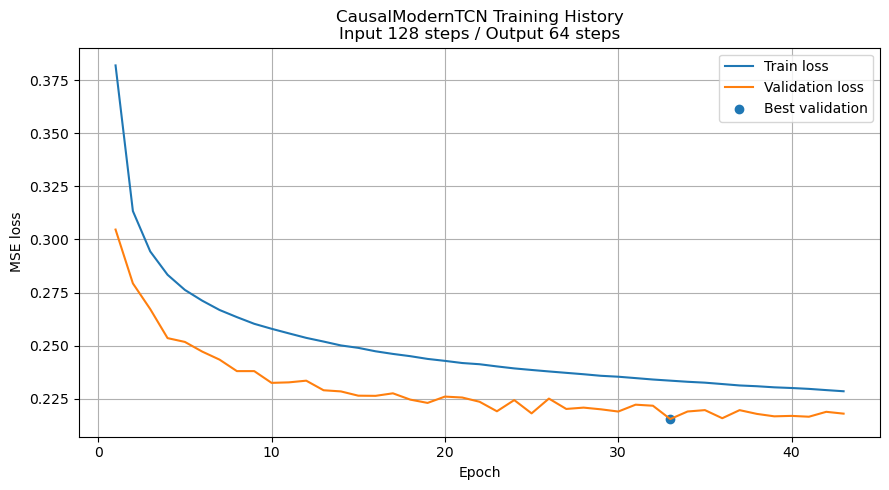


NPZ 저장 항목:
['y_true_scaled', 'y_pred_scaled', 'y_true_raw', 'y_pred_raw', 'meta_test', 'data_mean', 'data_std', 'sampling_interval', 'sampling_rate', 'in_len', 'out_len', 'stride']

저장 배열 shape
y_true_scaled: (71053, 64, 6)
y_pred_scaled: (71053, 64, 6)
y_true_raw: (71053, 64, 6)
y_pred_raw: (71053, 64, 6)
meta_test: (71053, 2)

선택된 Test window
Sample index: 4764
File index: 68
Start index: 8756
Truth shape: (64, 6)
Prediction shape: (64, 6)

선택된 Test window 성능:


,DOF,MAE,RMSE,R2
0,<greek>x</greek><sub>1</sub> (m),0.063454,0.076963,0.990185
1,<greek>x</greek><sub>2</sub> (m),0.063047,0.073518,0.915108
2,<greek>x</greek><sub>3</sub> (m),0.054493,0.071051,0.978240
3,<greek>x</greek><sub>4</sub> (deg),0.192829,0.217359,0.782687
4,<greek>x</greek><sub>5</sub> (deg),0.058217,0.074704,0.972503
5,<greek>x</greek><sub>6</sub> (deg),0.031433,0.040654,0.979135


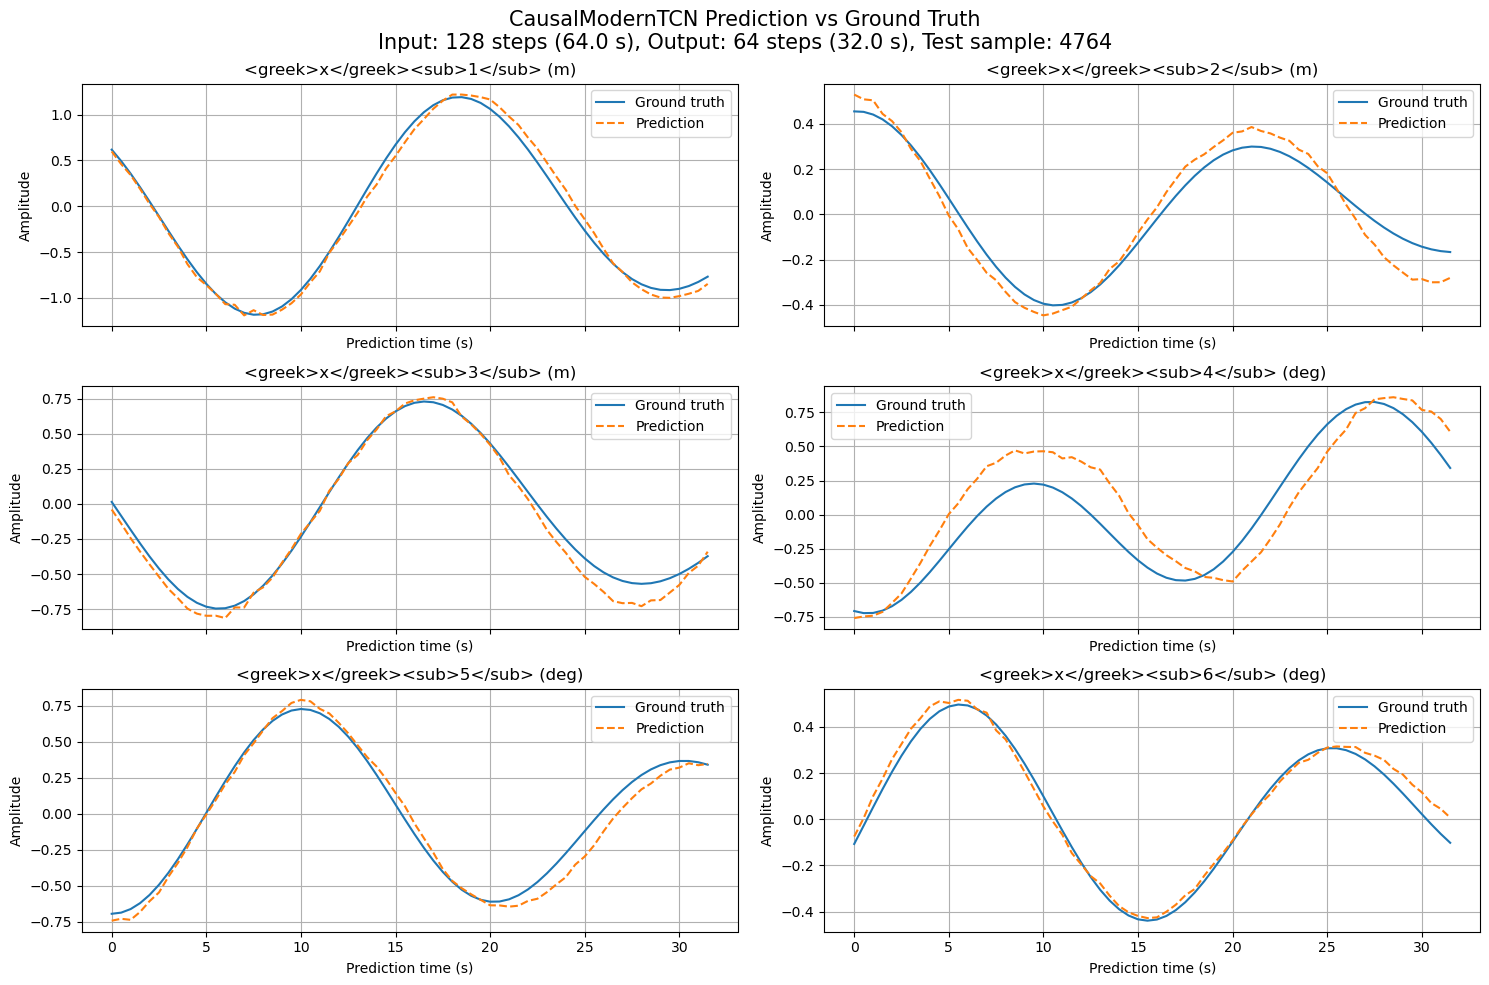

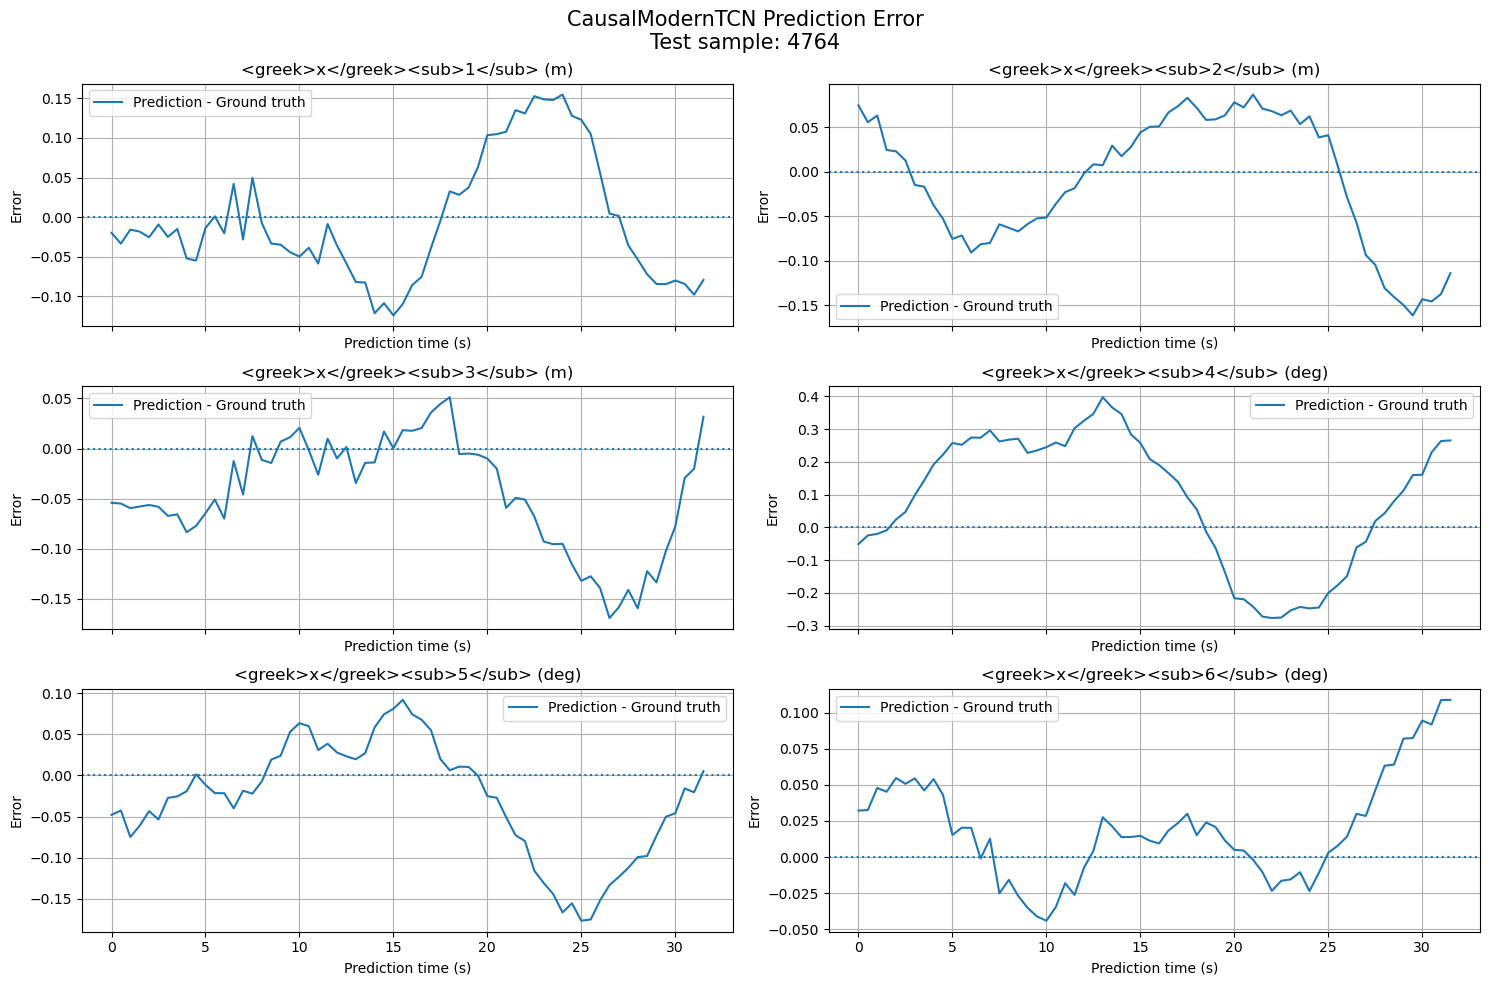


전체 Test 성능:


,DOF,test_mse_scaled,MAE,RMSE,R2
0,<greek>x</greek><sub>1</sub> (m),0.216225,0.250259,0.409125,0.923383
1,<greek>x</greek><sub>2</sub> (m),0.216225,0.355079,0.651243,0.793717
2,<greek>x</greek><sub>3</sub> (m),0.216225,0.605147,1.058767,0.691879
3,<greek>x</greek><sub>4</sub> (deg),0.216225,0.339010,0.635550,0.912666
4,<greek>x</greek><sub>5</sub> (deg),0.216225,0.363494,0.646912,0.597021
5,<greek>x</greek><sub>6</sub> (deg),0.216225,0.161101,0.256420,0.796621
6,overall,0.216225,0.345682,0.609669,0.785881



Experiment summary:


,value
experiment_name,CausalModernTCN_dataset_standard_in128_out64_gap
best_epoch,33
best_val_loss,0.215507
test_mse_scaled,0.216225
num_train_windows,432405
num_val_windows,71053
num_test_windows,71053
history_csv,experiments/CausalModernTCN_dataset_standard_i...
test_metrics_csv,experiments/CausalModernTCN_dataset_standard_i...
test_predictions_npz,experiments/CausalModernTCN_dataset_standard_i...


In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    conda_lib = str(Path(conda_prefix) / "lib")
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]

    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = (
            f"{conda_lib}:{ld_library_path}"
            if ld_library_path
            else conda_lib
        )

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0,1")

torch.backends.cudnn.enabled = False

device = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)
print("cuDNN enabled:", torch.backends.cudnn.enabled)

EXP_DIR = Path(
    "experiments/"
    "CausalModernTCN_dataset_standard_in128_out64_gap"
)

MODEL_PATH = EXP_DIR / "models" / "best_model.pt"
RESULT_DIR = EXP_DIR / "results"

HISTORY_PATH = RESULT_DIR / "history.csv"
METRICS_PATH = RESULT_DIR / "test_metrics.csv"
PREDICTION_PATH = RESULT_DIR / "test_predictions.npz"
SUMMARY_PATH = RESULT_DIR / "summary.json"

# Test window number
# If None, random window is selected.
SAMPLE_INDEX = None

print("Experiment directory:", EXP_DIR)
print("Model path:", MODEL_PATH)
print("Prediction path:", PREDICTION_PATH)

class PermuteToChannelsFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)


class PermuteToTimeFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)


class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x


class CausalConv1d(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        groups=1,
        bias=True,
    ):
        super().__init__()

        if kernel_size < 1:
            raise ValueError(
                "kernel_size는 1 이상이어야 합니다."
            )

        self.left_padding = kernel_size - 1

        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=0,
            groups=groups,
            bias=bias,
        )

    def forward(self, x):
        x = nn.functional.pad(
            x,
            (self.left_padding, 0),
        )

        return self.conv(x)


class ModernTCNBlock(nn.Module):
    def __init__(
        self,
        channels,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
    ):
        super().__init__()

        hidden_dim = int(channels * expansion)

        self.dwconv = CausalConv1d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=kernel_size,
            groups=channels,
            bias=True,
        )

        self.norm = ChannelLayerNorm(channels)

        self.pwffn = nn.Sequential(
            nn.Conv1d(
                channels,
                hidden_dim,
                kernel_size=1,
                bias=True,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(
                hidden_dim,
                channels,
                kernel_size=1,
                bias=True,
            ),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        residual = x

        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwffn(x)

        return x + residual


class ModernTCNBackbone(nn.Module):
    def __init__(
        self,
        in_dof=6,
        channels=128,
        num_blocks=6,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            PermuteToChannelsFirst(),
            CausalConv1d(
                in_channels=in_dof,
                out_channels=channels,
                kernel_size=stem_kernel_size,
                bias=True,
            ),
        )

        self.blocks = nn.ModuleList([
            ModernTCNBlock(
                channels=channels,
                kernel_size=kernel_size,
                expansion=expansion,
                dropout=dropout,
            )
            for _ in range(num_blocks)
        ])

        self.out_permute = PermuteToTimeFirst()

    def forward(self, x):
        x = self.input_proj(x)

        for block in self.blocks:
            x = block(x)

        return self.out_permute(x)


class ModernTCNRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=128,
        out_len=64,
        channels=128,
        num_blocks=6,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
        head_dropout=0.1,
    ):
        super().__init__()

        self.in_len = in_len
        self.out_len = out_len
        self.out_dof = out_dof

        self.backbone = ModernTCNBackbone(
            in_dof=in_dof,
            channels=channels,
            num_blocks=num_blocks,
            kernel_size=kernel_size,
            expansion=expansion,
            dropout=dropout,
            stem_kernel_size=stem_kernel_size,
        )

        self.temporal_projection = nn.Sequential(
            nn.Linear(in_len, out_len),
            nn.GELU(),
            nn.Dropout(head_dropout),
        )

        self.output_projection = nn.Linear(
            channels,
            out_dof,
        )

    def forward(self, src):
        x = self.backbone(src)
        x = x.transpose(1, 2)
        x = self.temporal_projection(x)
        x = x.transpose(1, 2)
        x = self.output_projection(x)

        return x

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model checkpoint not found:\n"
        f"{MODEL_PATH}"
    )

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False,
)

model_config = checkpoint["model_config"]

model = ModernTCNRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    channels=model_config["channels"],
    num_blocks=model_config["num_blocks"],
    kernel_size=model_config["kernel_size"],
    expansion=model_config["expansion"],
    dropout=model_config["dropout"],
    stem_kernel_size=model_config["stem_kernel_size"],
    head_dropout=model_config["head_dropout"],
)

state_dict = checkpoint["model_state_dict"]

if len(state_dict) > 0:
    first_key = next(iter(state_dict))

    if first_key.startswith("module."):
        state_dict = {
            key.replace("module.", "", 1): value
            for key, value in state_dict.items()
        }

model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

data_mean = np.asarray(
    checkpoint["data_mean"],
    dtype=np.float32,
)

data_std = np.asarray(
    checkpoint["data_std"],
    dtype=np.float32,
)

dof_cols = list(checkpoint["dof_cols"])

in_len = int(checkpoint["in_len"])
out_len = int(checkpoint["out_len"])

sampling_interval = float(
    checkpoint["sampling_interval"]
)

sampling_rate = float(
    checkpoint["sampling_rate"]
)

print("\nModel loaded successfully")
print("Model type:", model_config["model_type"])
print("Best epoch:", checkpoint.get("best_epoch"))
print("Best validation loss:", checkpoint.get("best_val_loss"))
print("Input length:", in_len)
print("Output length:", out_len)
print("Input duration:", in_len * sampling_interval, "sec")
print("Output duration:", out_len * sampling_interval, "sec")
print("DOF columns:", dof_cols)
print("data_mean:", data_mean)
print("data_std:", data_std)

if HISTORY_PATH.exists():
    history_df = pd.read_csv(HISTORY_PATH)

    print("\nTraining History:")
    display(history_df.tail())

    if len(history_df) > 0:
        best_idx = history_df["val_loss"].idxmin()
        best_row = history_df.loc[best_idx]

        print(
            f"history.csv Minimum Validation loss: "
            f"{best_row['val_loss']:.8f}"
        )

        print(
            f"history.csv Minimum Validation loss: "
            f"{best_row['val_loss']:.8f}"
        )

        print(
            f"history.csv Minimum Validation loss epoch: "
            f"{int(best_row['epoch'])}"
        )

        plt.figure(figsize=(9, 5))

        plt.plot(
            history_df["epoch"],
            history_df["train_loss"],
            label="Train loss",
        )

        plt.plot(
            history_df["epoch"],
            history_df["val_loss"],
            label="Validation loss",
        )

        plt.scatter(
            best_row["epoch"],
            best_row["val_loss"],
            label="Best validation",
        )

        plt.xlabel("Epoch")
        plt.ylabel("MSE loss")
        plt.title(
            "CausalModernTCN Training History\n"
            "Input 128 steps / Output 64 steps"
        )
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print(
        f"Training history file not found:\n"
        f"{HISTORY_PATH}"
    )

if not PREDICTION_PATH.exists():
    raise FileNotFoundError(
        f"Test prediction file not found:\n"
        f"{PREDICTION_PATH}"
    )

prediction_data = np.load(
    PREDICTION_PATH,
    allow_pickle=False,
)

print("\nSaved NPZ items:")
print(prediction_data.files)

y_true_scaled = prediction_data["y_true_scaled"]
y_pred_scaled = prediction_data["y_pred_scaled"]
y_true_raw = prediction_data["y_true_raw"]
y_pred_raw = prediction_data["y_pred_raw"]
meta_test = prediction_data["meta_test"]

npz_in_len = int(prediction_data["in_len"])
npz_out_len = int(prediction_data["out_len"])
npz_stride = int(prediction_data["stride"])

npz_sampling_interval = float(
    prediction_data["sampling_interval"]
)

print("\nSaved array shapes")
print("y_true_scaled:", y_true_scaled.shape)
print("y_pred_scaled:", y_pred_scaled.shape)
print("y_true_raw:", y_true_raw.shape)
print("y_pred_raw:", y_pred_raw.shape)
print("meta_test:", meta_test.shape)

if npz_in_len != in_len:
    raise RuntimeError(
        f"{in_len} != {npz_in_len}"
    )

if npz_out_len != out_len:
    raise RuntimeError(
        f"{out_len} != {npz_out_len}"
    )

if not np.isclose(
    npz_sampling_interval,
    sampling_interval,
):
    raise RuntimeError(
        f"{sampling_interval} != {npz_sampling_interval}"
    )

# ==============================
# 6. Test window 선택
# ==============================
num_test_windows = len(y_true_raw)

if num_test_windows == 0:
    raise RuntimeError(
        "Saved Test prediction is empty."
    )

if SAMPLE_INDEX is None:
    rng = np.random.default_rng()
    sample_idx = int(
        rng.integers(0, num_test_windows)
    )
else:
    sample_idx = int(SAMPLE_INDEX)

    if not 0 <= sample_idx < num_test_windows:
        raise IndexError(
            f"SAMPLE_INDEX is out of bounds. It should be between 0 and {num_test_windows - 1}."
        )

true_seq = y_true_raw[sample_idx]
pred_seq = y_pred_raw[sample_idx]

file_idx = int(meta_test[sample_idx, 0])
start_idx = int(meta_test[sample_idx, 1])

print("\nSelected Test window")
print("Sample index:", sample_idx)
print("File index:", file_idx)
print("Start index:", start_idx)
print("Truth shape:", true_seq.shape)
print("Prediction shape:", pred_seq.shape)

error_seq = pred_seq - true_seq

mae_per_dof = np.mean(
    np.abs(error_seq),
    axis=0,
)

rmse_per_dof = np.sqrt(
    np.mean(
        error_seq ** 2,
        axis=0,
    )
)

ss_res = np.sum(
    error_seq ** 2,
    axis=0,
)

true_mean = np.mean(
    true_seq,
    axis=0,
    keepdims=True,
)

ss_tot = np.sum(
    (true_seq - true_mean) ** 2,
    axis=0,
)

r2_per_dof = 1.0 - (
    ss_res / (ss_tot + 1e-12)
)

sample_metrics_df = pd.DataFrame({
    "DOF": dof_cols,
    "MAE": mae_per_dof,
    "RMSE": rmse_per_dof,
    "R2": r2_per_dof,
})

print("\nSelected Test window performance:")
display(sample_metrics_df)

time_axis = (
    np.arange(out_len)
    * sampling_interval
)

fig, axes = plt.subplots(
    3,
    2,
    figsize=(15, 10),
    sharex=True,
)

fig.suptitle(
    f"CausalModernTCN Prediction vs Ground Truth\n"
    f"Input: {in_len} steps "
    f"({in_len * sampling_interval:.1f} s), "
    f"Output: {out_len} steps "
    f"({out_len * sampling_interval:.1f} s), "
    f"Test sample: {sample_idx}",
    fontsize=15,
)

axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= len(dof_cols):
        ax.axis("off")
        continue

    ax.plot(
        time_axis,
        true_seq[:, i],
        label="Ground truth",
    )

    ax.plot(
        time_axis,
        pred_seq[:, i],
        label="Prediction",
        linestyle="--",
    )

    ax.set_title(dof_cols[i])
    ax.set_xlabel("Prediction time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(
    3,
    2,
    figsize=(15, 10),
    sharex=True,
)

fig.suptitle(
    f"CausalModernTCN Prediction Error\n"
    f"Test sample: {sample_idx}",
    fontsize=15,
)

axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= len(dof_cols):
        ax.axis("off")
        continue

    ax.plot(
        time_axis,
        error_seq[:, i],
        label="Prediction - Ground truth",
    )

    ax.axhline(
        0.0,
        linestyle=":",
    )

    ax.set_title(dof_cols[i])
    ax.set_xlabel("Prediction time (s)")
    ax.set_ylabel("Error")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

if METRICS_PATH.exists():
    test_metrics_df = pd.read_csv(
        METRICS_PATH
    )

    print("\nTotal Test Performance:")
    display(test_metrics_df)
else:
    print(
        f"Test metric file not found:\n"
        f"{METRICS_PATH}"
    )

if SUMMARY_PATH.exists():
    import json

    with open(
        SUMMARY_PATH,
        "r",
        encoding="utf-8",
    ) as f:
        summary = json.load(f)

    print("\nExperiment summary:")
    display(
        pd.DataFrame(
            [summary]
        ).T.rename(
            columns={0: "value"}
        )
    )
else:
    print(
        f"Summary file not found:\n"
        f"{SUMMARY_PATH}"
    )

### 3.4. Data Volume sensitivity test

py_reg_ModernTCN_64_data.py

Each CSV file is treated as **one independent data-generation condition**. Multiple sliding windows generated from the same CSV file are **not** counted as independent conditions. The complete set of condition files is split **once** into a **Training condition pool**, **Validation conditions**, and **Test conditions**. The Validation and Test condition sets remain fixed throughout all dataset sizes and repeated experiments.

For each dataset size, only the specified number of conditions is selected from the Training condition pool. The mean and standard deviation are computed **only from the raw data of the selected training conditions**, and these statistics are used to standardize the Training, Validation, and Test datasets. This prevents statistical information from the Validation and Test conditions from leaking into the training process.

The default dataset sizes are **50, 100, 200, 300, 400, 500, and 700 conditions**. Any value larger than the actual size of the Training condition pool is automatically excluded, and the full Training condition pool is automatically added as the final experiment. For each dataset size, **five independent training runs** are performed using different condition subsets and random seeds.

#### Outputs Stored for Each Training Run

The **`history.csv`** file stores the Training loss and Validation loss for every epoch. This file can be used to visualize the convergence speed, the onset of overfitting, the optimal stopping epoch, and the training stability for different dataset sizes.

The **`selected_train_conditions.csv`** file records the actual condition files selected for each training run. This enables further analysis of why a particular run achieved relatively high or low performance by examining the composition of the selected training conditions.

The **`test_metrics.csv`** file stores the **MAE**, **RMSE**, and **R²** values for each degree of freedom as well as the overall average. All evaluation metrics are computed after converting the predictions back to their original physical units.

The **`test_predictions.npz`** file stores the input time series, ground-truth future time series, predicted future time series, condition file index, sliding-window starting position, and the corresponding relative time axis. These data can be directly loaded into a separate Jupyter notebook to regenerate prediction plots, error curves, multi-DOF subplots, and publication-quality figures.

The **`best_model.pt`** file stores the model weights corresponding to the lowest Validation loss, together with the model configuration, normalization statistics, selected Training conditions, fixed Validation/Test conditions, and the optimal training epoch.

#### Overall Experimental Results

The **`all_runs_summary.csv`** file stores the primary performance metrics for every dataset size and every repeated experiment, with one row per training run. This file can be used to analyze the average performance, standard deviation, and variability across repeated experiments as the number of training conditions increases.

The **`all_runs_metrics.csv`** file stores the MAE, RMSE, and R² values for each degree of freedom from every repeated experiment.

The **`learning_curve.csv`** file stores the overall average performance, standard deviation, 95% confidence interval, coefficient of variation (CV) of the RMSE, and the relative performance improvement compared with the previous dataset size. This file can be used to construct learning curves with respect to the number of training conditions and to identify the point at which performance begins to saturate.

The **`dof_learning_curve.csv`** file stores the MAE, RMSE, R², standard deviation, and 95% confidence interval for each degree of freedom as the dataset size increases. These results make it possible to investigate whether **surge, sway, heave, roll, pitch, and yaw** exhibit different convergence characteristics as additional training conditions are introduced.

The current implementation treats each CSV file as a single condition and does **not** explicitly extract the values of **ship speed (V)**, **significant wave height (Hs)**, **mean wave period (Tz)**, or **wave heading** from the filenames. Consequently, the condition subsets are selected randomly. If these four parameters are available in the filenames or in a separate metadata file, the sampling strategy can be extended in future work to **stratified sampling**, ensuring a more uniform coverage of the condition space.

```text
experiments/
└── CausalModernTCN_condition_learning_curve_in128_out64_stride16/
    ├── runs/
    │   ├── train_conditions_0050/
    │   │   ├── repeat_01/
    │   │   │   ├── models/
    │   │   │   │   └── best_model.pt
    │   │   │   └── results/
    │   │   │       ├── history.csv
    │   │   │       ├── selected_train_conditions.csv
    │   │   │       ├── test_metrics.csv
    │   │   │       ├── test_predictions.npz
    │   │   │       └── summary.json
    │   │   ├── repeat_02/
    │   │   ├── repeat_03/
    │   │   ├── repeat_04/
    │   │   └── repeat_05/
    │   ├── train_conditions_0100/
    │   ├── train_conditions_0200/
    │   ├── train_conditions_0300/
    │   ├── train_conditions_0400/
    │   ├── train_conditions_0500/
    │   └── train_conditions_0700/
    └── results/
        ├── condition_manifest.csv
        ├── fixed_condition_split.npz
        ├── all_runs_summary.csv
        ├── all_runs_metrics.csv
        ├── learning_curve.csv
        ├── dof_learning_curve.csv
        ├── experiment_config.json
        └── summary.json

Experiment directory: experiments/CausalModernTCN_condition_learning_curve_in128_out64_stride16
Train-size directory: experiments/CausalModernTCN_condition_learning_curve_in128_out64_stride16/runs/train_conditions_0050
Selected run: repeat_05
History exists: True
Checkpoint exists: True
Prediction exists: True
Metrics exists: True

최근 학습 기록:


/home/yangjun/anaconda3/envs/Auto/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,epoch,train_loss,val_loss
15,16,0.258629,0.394119
16,17,0.250184,0.406039
17,18,0.241466,0.401170
18,19,0.233667,0.411648
19,20,0.225640,0.410330


현재까지 기록된 최저 Validation loss: 0.36931855
현재까지 기록된 최저 Validation epoch: 10


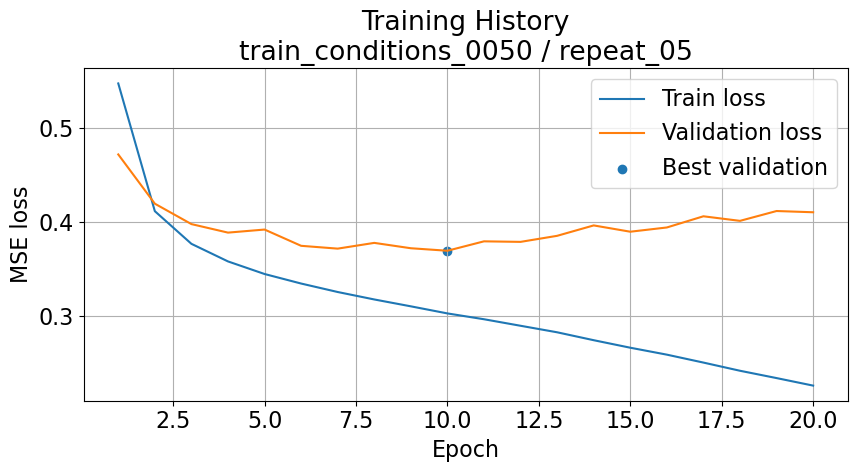


Using device: cuda:0

모델 로드 완료
Model type: CausalModernTCN
Train condition size: 50
Repeat: 5
Best epoch: 10
Best validation loss: 0.36931855227512245
Input length: 128
Output length: 64
Input duration: 64.0 sec
Output duration: 32.0 sec

저장된 test_predictions.npz를 사용합니다.

선택된 Test window
Sample index: 82339
File index: 879
File name: 165_Tm_13.7_HS_13.9_V_5.1.csv
Window start index: 896
Input shape: (128, 6)
Truth shape: (64, 6)
Prediction shape: (64, 6)


,DOF,MAE,RMSE
0,<greek>x</greek><sub>1</sub> (m),1.151354,1.388872
1,<greek>x</greek><sub>2</sub> (m),0.359268,0.505334
2,<greek>x</greek><sub>3</sub> (m),2.375163,2.845327
3,<greek>x</greek><sub>4</sub> (deg),0.196151,0.257721
4,<greek>x</greek><sub>5</sub> (deg),2.007541,2.534964
5,<greek>x</greek><sub>6</sub> (deg),0.249627,0.288294


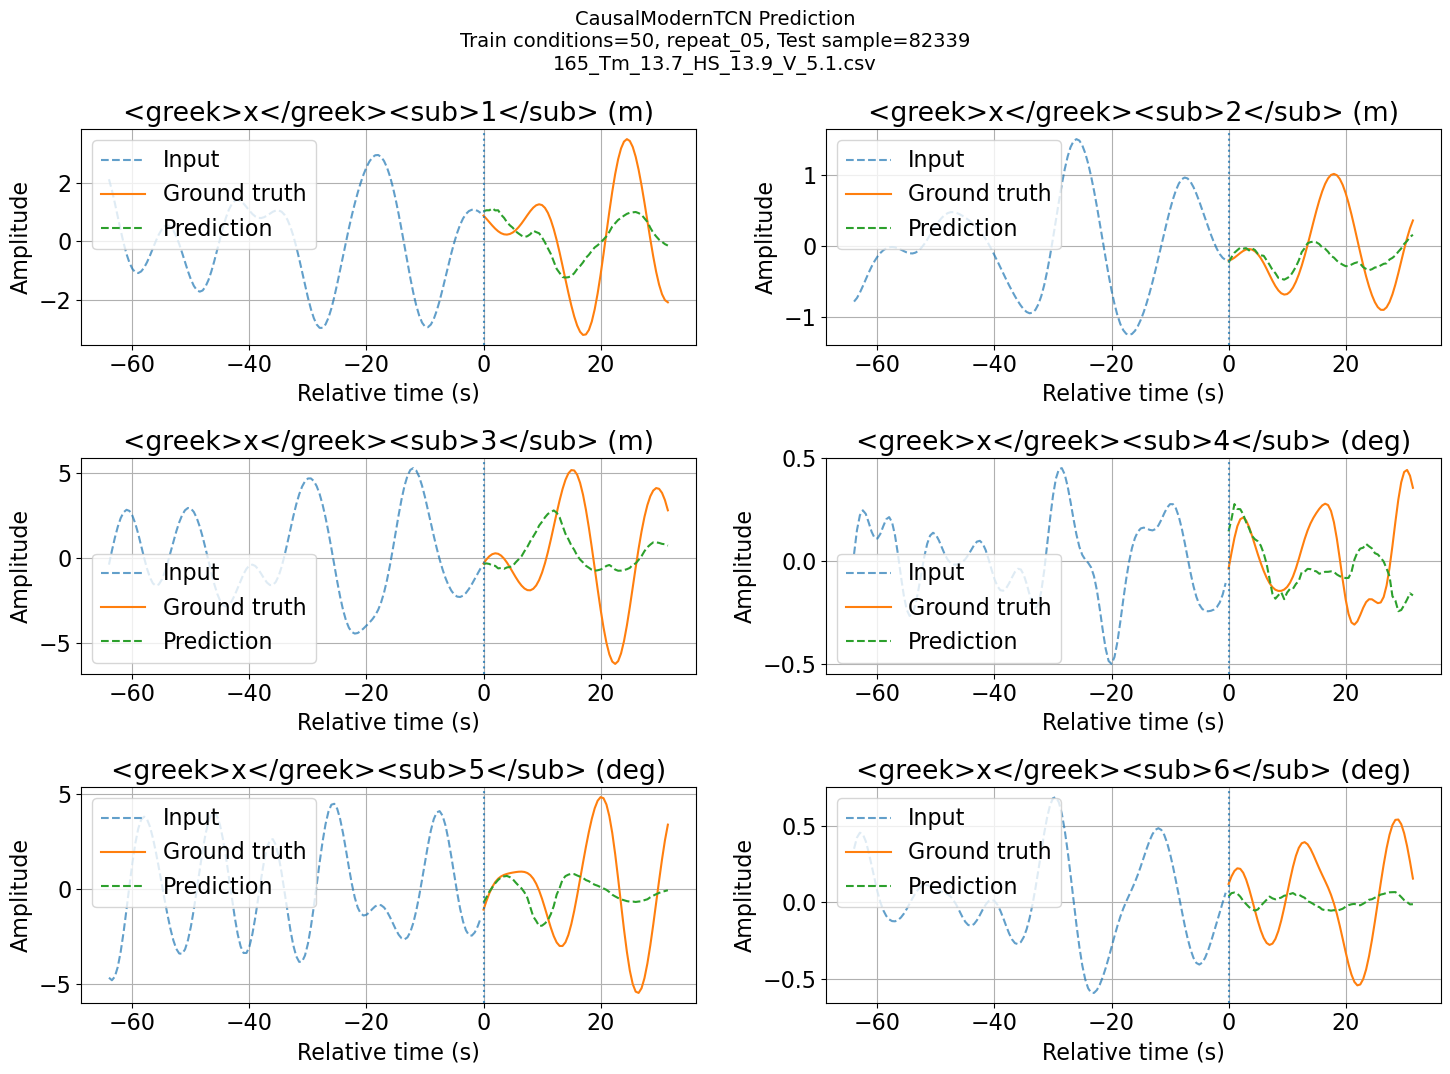


저장된 전체 Test metrics:


,train_condition_size,repeat,run_seed,DOF,test_mse_scaled,MAE,RMSE,R2
0,50,5,5047,<greek>x</greek><sub>1</sub> (m),0.354193,0.402844,0.673640,0.786301
1,50,5,5047,<greek>x</greek><sub>2</sub> (m),0.354193,0.491252,0.844533,0.602429
2,50,5,5047,<greek>x</greek><sub>3</sub> (m),0.354193,0.806557,1.287050,0.494847
3,50,5,5047,<greek>x</greek><sub>4</sub> (deg),0.354193,0.537050,1.022507,0.811700
4,50,5,5047,<greek>x</greek><sub>5</sub> (deg),0.354193,0.463275,0.750534,0.420358
5,50,5,5047,<greek>x</greek><sub>6</sub> (deg),0.354193,0.223935,0.339626,0.571043
6,50,5,5047,overall_mean,0.354193,0.487485,0.819648,0.614446


In [9]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ============================================================
# 0. 사용자 설정
# ============================================================
TRAIN_CONDITION_SIZE = 50

# 특정 반복을 확인하려면 1, 2, 3, ...으로 지정한다.
# None으로 설정하면 사용 가능한 가장 최근 반복을 자동 선택한다.
SELECT_REPEAT = None

# 표시할 Test window 인덱스
# None이면 임의로 선택한다.
SAMPLE_INDEX = None

# Test prediction 파일이 아직 없을 때 직접 추론할 batch size
INFERENCE_BATCH_SIZE = 64

EXP_DIR = Path(
    "experiments/"
    "CausalModernTCN_condition_learning_curve_"
    "in128_out64_stride16"
)

SIZE_DIR = (
    EXP_DIR
    / "runs"
    / f"train_conditions_{TRAIN_CONDITION_SIZE:04d}"
)

print("Experiment directory:", EXP_DIR)
print("Train-size directory:", SIZE_DIR)

if not SIZE_DIR.exists():
    raise FileNotFoundError(
        f"조건 수 {TRAIN_CONDITION_SIZE}의 실험 폴더를 찾을 수 없습니다:\n"
        f"{SIZE_DIR}"
    )

# ============================================================
# 1. 확인할 Repeat 자동 탐색
# ============================================================
repeat_dirs = sorted([
    p
    for p in SIZE_DIR.glob("repeat_*")
    if p.is_dir()
])

if len(repeat_dirs) == 0:
    raise FileNotFoundError(
        f"반복 실험 폴더가 아직 생성되지 않았습니다:\n{SIZE_DIR}"
    )

if SELECT_REPEAT is not None:
    RUN_DIR = SIZE_DIR / f"repeat_{SELECT_REPEAT:02d}"

    if not RUN_DIR.exists():
        raise FileNotFoundError(
            f"지정한 반복 실험 폴더가 없습니다:\n{RUN_DIR}"
        )
else:
    # 우선순위:
    # 1. test_predictions.npz가 있는 완료된 run
    # 2. best_model.pt가 있는 run
    # 3. history.csv만 있는 run
    completed_dirs = [
        p
        for p in repeat_dirs
        if (p / "results" / "test_predictions.npz").exists()
    ]

    checkpoint_dirs = [
        p
        for p in repeat_dirs
        if (p / "models" / "best_model.pt").exists()
    ]

    history_dirs = [
        p
        for p in repeat_dirs
        if (p / "results" / "history.csv").exists()
    ]

    if completed_dirs:
        RUN_DIR = completed_dirs[-1]
    elif checkpoint_dirs:
        RUN_DIR = checkpoint_dirs[-1]
    elif history_dirs:
        RUN_DIR = history_dirs[-1]
    else:
        RUN_DIR = repeat_dirs[-1]

MODEL_PATH = RUN_DIR / "models" / "best_model.pt"
HISTORY_PATH = RUN_DIR / "results" / "history.csv"
PREDICTION_PATH = RUN_DIR / "results" / "test_predictions.npz"
METRICS_PATH = RUN_DIR / "results" / "test_metrics.csv"
SUMMARY_PATH = RUN_DIR / "results" / "summary.json"

print("Selected run:", RUN_DIR.name)
print("History exists:", HISTORY_PATH.exists())
print("Checkpoint exists:", MODEL_PATH.exists())
print("Prediction exists:", PREDICTION_PATH.exists())
print("Metrics exists:", METRICS_PATH.exists())

# ============================================================
# 2. 현재까지 저장된 학습 곡선 확인
# ============================================================
if HISTORY_PATH.exists():
    history_df = pd.read_csv(HISTORY_PATH)

    if len(history_df) == 0:
        print("history.csv가 비어 있습니다.")
    else:
        print("\n최근 학습 기록:")
        display(history_df.tail())

        best_history_idx = history_df["val_loss"].idxmin()
        best_history_row = history_df.loc[best_history_idx]

        print(
            f"현재까지 기록된 최저 Validation loss: "
            f"{best_history_row['val_loss']:.8f}"
        )
        print(
            f"현재까지 기록된 최저 Validation epoch: "
            f"{int(best_history_row['epoch'])}"
        )

        plt.figure(figsize=(9, 5))

        plt.plot(
            history_df["epoch"],
            history_df["train_loss"],
            label="Train loss",
        )

        plt.plot(
            history_df["epoch"],
            history_df["val_loss"],
            label="Validation loss",
        )

        plt.scatter(
            best_history_row["epoch"],
            best_history_row["val_loss"],
            marker="o",
            label="Best validation",
        )

        plt.xlabel("Epoch")
        plt.ylabel("MSE loss")
        plt.title(
            f"Training History\n"
            f"{RUN_DIR.parent.name} / {RUN_DIR.name}"
        )
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print(
        "\nhistory.csv가 아직 생성되지 않았습니다. "
        "첫 번째 epoch가 끝난 뒤 다시 실행하십시오."
    )

# ============================================================
# 3. 모델 아키텍처 정의
# ============================================================
class PermuteToChannelsFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)


class PermuteToTimeFirst(nn.Module):
    def forward(self, x):
        return x.transpose(1, 2)


class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x


class CausalConv1d(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        groups=1,
        bias=True,
    ):
        super().__init__()

        if kernel_size < 1:
            raise ValueError("kernel_size는 1 이상이어야 합니다.")

        self.left_padding = kernel_size - 1

        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            padding=0,
            groups=groups,
            bias=bias,
        )

    def forward(self, x):
        x = nn.functional.pad(
            x,
            (self.left_padding, 0),
        )
        return self.conv(x)


class ModernTCNBlock(nn.Module):
    def __init__(
        self,
        channels,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
    ):
        super().__init__()

        hidden_dim = int(channels * expansion)

        self.dwconv = CausalConv1d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=kernel_size,
            groups=channels,
            bias=True,
        )

        self.norm = ChannelLayerNorm(channels)

        self.pwffn = nn.Sequential(
            nn.Conv1d(
                channels,
                hidden_dim,
                kernel_size=1,
                bias=True,
            ),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(
                hidden_dim,
                channels,
                kernel_size=1,
                bias=True,
            ),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        residual = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwffn(x)
        return x + residual


class ModernTCNBackbone(nn.Module):
    def __init__(
        self,
        in_dof=6,
        channels=128,
        num_blocks=6,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            PermuteToChannelsFirst(),
            CausalConv1d(
                in_channels=in_dof,
                out_channels=channels,
                kernel_size=stem_kernel_size,
                bias=True,
            ),
        )

        self.blocks = nn.ModuleList([
            ModernTCNBlock(
                channels=channels,
                kernel_size=kernel_size,
                expansion=expansion,
                dropout=dropout,
            )
            for _ in range(num_blocks)
        ])

        self.out_permute = PermuteToTimeFirst()

    def forward(self, x):
        x = self.input_proj(x)

        for block in self.blocks:
            x = block(x)

        return self.out_permute(x)


class ModernTCNRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=128,
        out_len=64,
        channels=128,
        num_blocks=6,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
        head_dropout=0.1,
    ):
        super().__init__()

        self.in_len = in_len
        self.out_len = out_len
        self.out_dof = out_dof

        self.backbone = ModernTCNBackbone(
            in_dof=in_dof,
            channels=channels,
            num_blocks=num_blocks,
            kernel_size=kernel_size,
            expansion=expansion,
            dropout=dropout,
            stem_kernel_size=stem_kernel_size,
        )

        self.temporal_projection = nn.Sequential(
            nn.Linear(in_len, out_len),
            nn.GELU(),
            nn.Dropout(head_dropout),
        )

        self.output_projection = nn.Linear(
            channels,
            out_dof,
        )

    def forward(self, src):
        x = self.backbone(src)
        x = x.transpose(1, 2)
        x = self.temporal_projection(x)
        x = x.transpose(1, 2)
        x = self.output_projection(x)
        return x

# ============================================================
# 4. Checkpoint 로드
# ============================================================
if not MODEL_PATH.exists():
    print(
        "\nbest_model.pt가 아직 생성되지 않았습니다. "
        "첫 번째 Validation 평가가 완료된 뒤 다시 실행하십시오."
    )
else:
    device = torch.device(
        "cuda:0"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("\nUsing device:", device)

    checkpoint = torch.load(
        MODEL_PATH,
        map_location=device,
        weights_only=False,
    )

    cfg = checkpoint["model_config"]

    model = ModernTCNRegressor(
        in_dof=cfg["in_dof"],
        out_dof=cfg["out_dof"],
        in_len=cfg["in_len"],
        out_len=cfg["out_len"],
        channels=cfg["channels"],
        num_blocks=cfg["num_blocks"],
        kernel_size=cfg["kernel_size"],
        expansion=cfg["expansion"],
        dropout=cfg["dropout"],
        stem_kernel_size=cfg["stem_kernel_size"],
        head_dropout=cfg["head_dropout"],
    )

    state_dict = checkpoint["model_state_dict"]

    # module. 접두어가 있는 checkpoint에도 대응한다.
    if len(state_dict) > 0:
        first_key = next(iter(state_dict))

        if first_key.startswith("module."):
            state_dict = {
                key.replace("module.", "", 1): value
                for key, value in state_dict.items()
            }

    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()

    data_mean = np.asarray(
        checkpoint["data_mean"],
        dtype=np.float32,
    )

    data_std = np.asarray(
        checkpoint["data_std"],
        dtype=np.float32,
    )

    dof_cols = list(checkpoint["dof_cols"])
    file_paths_used = [
        Path(path)
        for path in checkpoint["file_paths_used"]
    ]

    test_condition_indices = np.asarray(
        checkpoint["test_condition_indices"],
        dtype=np.int64,
    )

    in_len = int(checkpoint["in_len"])
    out_len = int(checkpoint["out_len"])
    stride = int(checkpoint["stride"])
    sampling_interval = float(
        checkpoint["sampling_interval"]
    )

    print("\n모델 로드 완료")
    print("Model type:", cfg["model_type"])
    print("Train condition size:", checkpoint["train_condition_size"])
    print("Repeat:", checkpoint["repeat"])
    print("Best epoch:", checkpoint["best_epoch"])
    print("Best validation loss:", checkpoint["best_val_loss"])
    print("Input length:", in_len)
    print("Output length:", out_len)
    print("Input duration:", in_len * sampling_interval, "sec")
    print("Output duration:", out_len * sampling_interval, "sec")

    # ========================================================
    # 5. 저장된 Test prediction 사용 또는 직접 추론
    # ========================================================
    if PREDICTION_PATH.exists():
        print(
            "\n저장된 test_predictions.npz를 사용합니다."
        )

        prediction_data = np.load(
            PREDICTION_PATH,
            allow_pickle=False,
        )

        if "x_raw" in prediction_data.files:
            x_raw_all = prediction_data["x_raw"]
        else:
            x_raw_all = None

        y_true_raw_all = prediction_data["y_true_raw"]
        y_pred_raw_all = prediction_data["y_pred_raw"]

        file_indices_all = prediction_data["file_indices"]
        start_indices_all = prediction_data["start_indices"]

        if "input_relative_time" in prediction_data.files:
            input_time = prediction_data["input_relative_time"]
        else:
            input_time = (
                np.arange(-in_len, 0)
                * sampling_interval
            )

        if "output_relative_time" in prediction_data.files:
            output_time = prediction_data["output_relative_time"]
        else:
            output_time = (
                np.arange(out_len)
                * sampling_interval
            )

    else:
        print(
            "\ntest_predictions.npz가 아직 없습니다."
        )
        print(
            "Checkpoint의 고정 Test 조건을 사용하여 직접 추론합니다."
        )

        all_arrays = []

        for path in tqdm(
            file_paths_used,
            desc="Load test source files",
        ):
            if not path.exists():
                raise FileNotFoundError(
                    f"Checkpoint에 저장된 데이터 파일을 찾을 수 없습니다:\n"
                    f"{path}"
                )

            df = pd.read_csv(path)
            arr = df[dof_cols].to_numpy(
                dtype=np.float32
            )

            all_arrays.append(arr)

        test_meta = []

        for file_idx in test_condition_indices:
            file_idx = int(file_idx)
            n = len(all_arrays[file_idx])

            max_start = n - in_len - out_len

            for start_idx in range(
                0,
                max_start + 1,
                stride,
            ):
                test_meta.append(
                    (file_idx, start_idx)
                )

        test_meta = np.asarray(
            test_meta,
            dtype=np.int64,
        )

        if len(test_meta) == 0:
            raise RuntimeError(
                "Checkpoint에 저장된 Test 조건에서 "
                "예측 가능한 window가 없습니다."
            )

        class InferenceWindowDataset(Dataset):
            def __init__(
                self,
                arrays,
                meta,
                mean,
                std,
                in_len,
                out_len,
            ):
                self.arrays = arrays
                self.meta = meta
                self.mean = mean
                self.std = std
                self.in_len = in_len
                self.out_len = out_len

            def __len__(self):
                return len(self.meta)

            def __getitem__(self, index):
                file_idx, start_idx = self.meta[index]

                file_idx = int(file_idx)
                start_idx = int(start_idx)

                e_in = start_idx + self.in_len
                e_out = e_in + self.out_len

                raw_arr = self.arrays[file_idx]

                x_raw = raw_arr[start_idx:e_in]
                y_raw = raw_arr[e_in:e_out]

                x_scaled = (
                    (x_raw - self.mean)
                    / self.std
                ).astype(np.float32)

                y_scaled = (
                    (y_raw - self.mean)
                    / self.std
                ).astype(np.float32)

                return (
                    torch.from_numpy(x_scaled),
                    torch.from_numpy(y_scaled),
                    torch.tensor(
                        file_idx,
                        dtype=torch.long,
                    ),
                    torch.tensor(
                        start_idx,
                        dtype=torch.long,
                    ),
                )

        test_ds = InferenceWindowDataset(
            arrays=all_arrays,
            meta=test_meta,
            mean=data_mean,
            std=data_std,
            in_len=in_len,
            out_len=out_len,
        )

        test_loader = DataLoader(
            test_ds,
            batch_size=INFERENCE_BATCH_SIZE,
            shuffle=False,
            drop_last=False,
        )

        x_raw_list = []
        y_true_raw_list = []
        y_pred_raw_list = []
        file_idx_list = []
        start_idx_list = []

        mean_3d = data_mean.reshape(1, 1, -1)
        std_3d = data_std.reshape(1, 1, -1)

        with torch.no_grad():
            for (
                src,
                trg,
                file_idx,
                start_idx,
            ) in tqdm(
                test_loader,
                desc="Test inference",
            ):
                src_device = src.to(device)

                pred_scaled = model(src_device)

                src_scaled_np = (
                    src.cpu()
                    .numpy()
                    .astype(np.float32)
                )

                trg_scaled_np = (
                    trg.cpu()
                    .numpy()
                    .astype(np.float32)
                )

                pred_scaled_np = (
                    pred_scaled.cpu()
                    .numpy()
                    .astype(np.float32)
                )

                x_raw_batch = (
                    src_scaled_np * std_3d
                    + mean_3d
                )

                y_true_raw_batch = (
                    trg_scaled_np * std_3d
                    + mean_3d
                )

                y_pred_raw_batch = (
                    pred_scaled_np * std_3d
                    + mean_3d
                )

                x_raw_list.append(
                    x_raw_batch.astype(np.float32)
                )

                y_true_raw_list.append(
                    y_true_raw_batch.astype(np.float32)
                )

                y_pred_raw_list.append(
                    y_pred_raw_batch.astype(np.float32)
                )

                file_idx_list.append(
                    file_idx.numpy().astype(np.int64)
                )

                start_idx_list.append(
                    start_idx.numpy().astype(np.int64)
                )

        x_raw_all = np.concatenate(
            x_raw_list,
            axis=0,
        )

        y_true_raw_all = np.concatenate(
            y_true_raw_list,
            axis=0,
        )

        y_pred_raw_all = np.concatenate(
            y_pred_raw_list,
            axis=0,
        )

        file_indices_all = np.concatenate(
            file_idx_list,
            axis=0,
        )

        start_indices_all = np.concatenate(
            start_idx_list,
            axis=0,
        )

        input_time = (
            np.arange(-in_len, 0)
            * sampling_interval
        )

        output_time = (
            np.arange(out_len)
            * sampling_interval
        )

    # ========================================================
    # 6. 확인할 Test window 선택
    # ========================================================
    num_test_windows = len(y_true_raw_all)

    if SAMPLE_INDEX is None:
        rng = np.random.default_rng()
        sample_idx = int(
            rng.integers(0, num_test_windows)
        )
    else:
        sample_idx = int(SAMPLE_INDEX)

        if not 0 <= sample_idx < num_test_windows:
            raise IndexError(
                f"SAMPLE_INDEX는 0 이상 "
                f"{num_test_windows - 1} 이하여야 합니다."
            )

    true_seq = y_true_raw_all[sample_idx]
    pred_seq = y_pred_raw_all[sample_idx]

    if x_raw_all is not None:
        input_seq = x_raw_all[sample_idx]
    else:
        input_seq = None

    sample_file_idx = int(
        file_indices_all[sample_idx]
    )

    sample_start_idx = int(
        start_indices_all[sample_idx]
    )

    sample_file_name = (
        file_paths_used[sample_file_idx].name
    )

    print("\n선택된 Test window")
    print("Sample index:", sample_idx)
    print("File index:", sample_file_idx)
    print("File name:", sample_file_name)
    print("Window start index:", sample_start_idx)
    print("Input shape:", None if input_seq is None else input_seq.shape)
    print("Truth shape:", true_seq.shape)
    print("Prediction shape:", pred_seq.shape)

    # ========================================================
    # 7. 선택된 window 성능 계산
    # ========================================================
    sample_error = pred_seq - true_seq

    sample_mae = np.mean(
        np.abs(sample_error),
        axis=0,
    )

    sample_rmse = np.sqrt(
        np.mean(
            sample_error ** 2,
            axis=0,
        )
    )

    sample_metrics_df = pd.DataFrame({
        "DOF": dof_cols,
        "MAE": sample_mae,
        "RMSE": sample_rmse,
    })

    display(sample_metrics_df)

    # ========================================================
    # 8. 입력 및 미래 예측 시계열 표시
    # ========================================================
    fig, axes = plt.subplots(
        3,
        2,
        figsize=(15, 11),
        sharex=False,
    )

    fig.suptitle(
        f"CausalModernTCN Prediction\n"
        f"Train conditions={TRAIN_CONDITION_SIZE}, "
        f"{RUN_DIR.name}, Test sample={sample_idx}\n"
        f"{sample_file_name}",
        fontsize=14,
    )

    axes = axes.flatten()

    for dof_idx, ax in enumerate(axes):
        if input_seq is not None:
            ax.plot(
                input_time,
                input_seq[:, dof_idx],
                label="Input",
                linestyle="--",
                alpha=0.7,
            )

        ax.plot(
            output_time,
            true_seq[:, dof_idx],
            label="Ground truth",
        )

        ax.plot(
            output_time,
            pred_seq[:, dof_idx],
            label="Prediction",
            linestyle="--",
        )

        ax.axvline(
            0.0,
            linestyle=":",
            alpha=0.8,
        )

        ax.set_title(dof_cols[dof_idx])
        ax.set_xlabel("Relative time (s)")
        ax.set_ylabel("Amplitude")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

    # ========================================================
    # 9. 저장된 전체 Test metric 확인
    # ========================================================
    if METRICS_PATH.exists():
        print("\n저장된 전체 Test metrics:")
        test_metrics_df = pd.read_csv(
            METRICS_PATH
        )
        display(test_metrics_df)
    else:
        print(
            "\ntest_metrics.csv는 아직 생성되지 않았습니다. "
            "현재 반복 실험이 끝난 뒤 생성됩니다."
        )

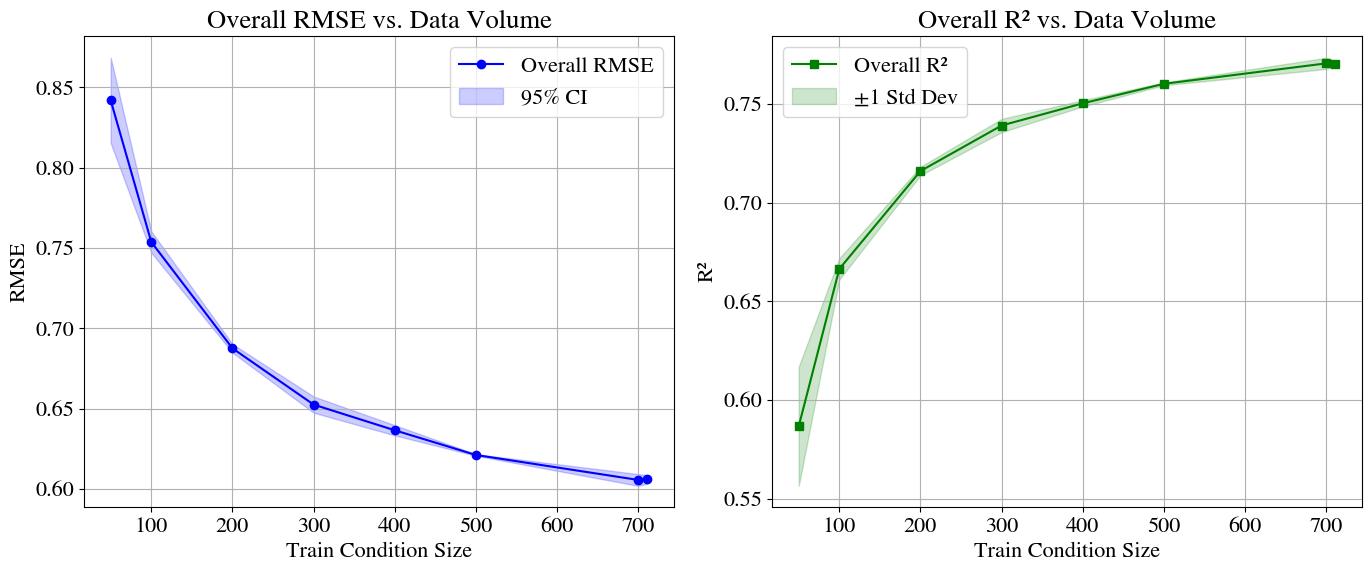

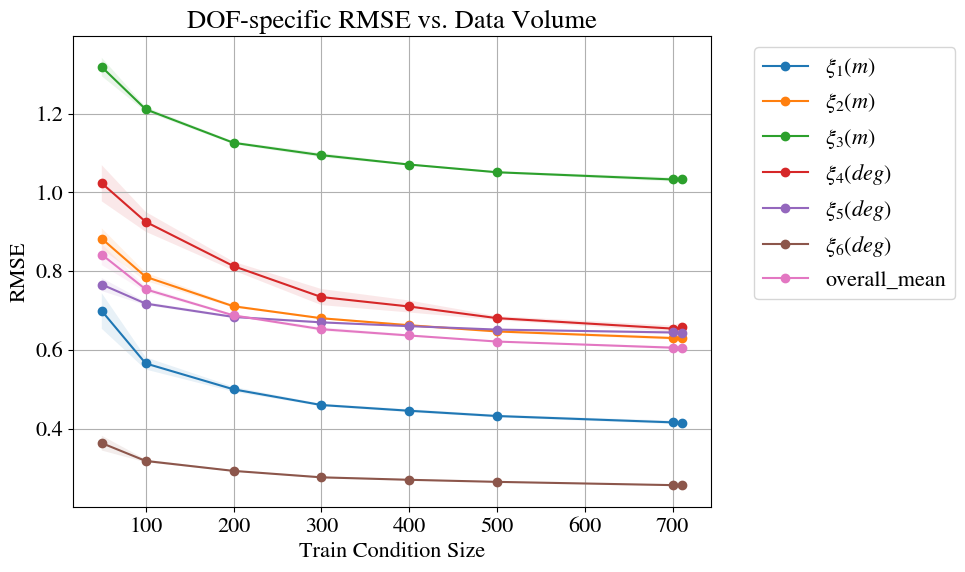

In [17]:
import pandas as pd
from pathlib import Path

EXP_NAME = "CausalModernTCN_condition_learning_curve_in128_out64_stride16"
RESULT_DIR = Path("experiments") / EXP_NAME / "results"

learning_curve_path = RESULT_DIR / "learning_curve.csv"
dof_learning_curve_path = RESULT_DIR / "dof_learning_curve.csv"

if not learning_curve_path.exists() or not dof_learning_curve_path.exists():
    raise FileNotFoundError("Result files do not exist.")

lc_df = pd.read_csv(learning_curve_path)
dof_df = pd.read_csv(dof_learning_curve_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(
    lc_df["train_condition_size"], 
    lc_df["test_rmse_mean"], 
    marker="o", 
    color="blue", 
    label="Overall RMSE"
)
axes[0].fill_between(
    lc_df["train_condition_size"],
    lc_df["test_rmse_mean"] - lc_df["rmse_ci95"],
    lc_df["test_rmse_mean"] + lc_df["rmse_ci95"],
    color="blue", 
    alpha=0.2, 
    label="95% CI"
)
axes[0].set_xlabel("Train Condition Size")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Overall RMSE vs. Data Volume")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(
    lc_df["train_condition_size"], 
    lc_df["test_r2_mean"], 
    marker="s", 
    color="green", 
    label="Overall R²"
)
axes[1].fill_between(
    lc_df["train_condition_size"],
    lc_df["test_r2_mean"] - lc_df["test_r2_std"],
    lc_df["test_r2_mean"] + lc_df["test_r2_std"],
    color="green", 
    alpha=0.2, 
    label="±1 Std Dev"
)
axes[1].set_xlabel("Train Condition Size")
axes[1].set_ylabel("R²")
axes[1].set_title("Overall R² vs. Data Volume")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

dofs = dof_df["DOF"].unique()
plt.figure(figsize=(10, 6))

for dof in dofs:
    subset = dof_df[dof_df["DOF"] == dof]
    plt.plot(
        subset["train_condition_size"], 
        subset["rmse_mean"], 
        marker="o", 
        label=format_math_labels(dof)
    )
    plt.fill_between(
        subset["train_condition_size"],
        subset["rmse_mean"] - subset["rmse_ci95"],
        subset["rmse_mean"] + subset["rmse_ci95"],
        alpha=0.1
    )

plt.xlabel("Train Condition Size")
plt.ylabel("RMSE")
plt.title("DOF-specific RMSE vs. Data Volume")
plt.grid(True)

# Legend를 그래프 외부 우측으로 이동
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 4. CDCIHybrid

The **CD/CI Hybrid** model is designed to combine the advantages of **Channel Dependence (CD)** and **Channel Independence (CI)** for multivariate time-series prediction. Instead of processing all six ship-motion variables simultaneously or treating every channel independently, the proposed architecture groups variables with similar physical characteristics and processes each group using a shared encoder and prediction head.

In this implementation, the six degrees of freedom (6-DOF) are divided into two channel groups: **translational motions** (`η₁`, `η₂`, `η₃`) and **rotational motions** (`η₄`, `η₅`, `η₆`). Each group is passed through the same **Shared Cluster Encoder**, which consists of an input projection layer followed by multiple ModernTCN-inspired residual blocks. Each block employs depthwise convolution for temporal feature extraction, Channel-wise Layer Normalization for stable feature normalization, pointwise feedforward layers for channel mixing, and residual connections to facilitate deep-network training. Because the encoder and prediction head are shared across channel groups, the model preserves parameter efficiency while allowing variables within each group to learn their mutual dependencies.

After feature extraction, the encoded representations are passed to a shared prediction head, where Global Average Pooling compresses the temporal dimension before fully connected layers generate the future motion sequences. The predicted outputs from each channel group are finally combined to reconstruct the complete six-degree-of-freedom ship-motion prediction.

This notebook demonstrates how to load the trained CD/CI Hybrid model and evaluate its prediction performance on an unseen ship-motion sequence. A 256-step input sequence is used to predict the following 256 time steps, and the predicted trajectories are compared with the corresponding ground-truth motions for all six degrees of freedom (6-DOF). This example illustrates how grouping physically related variables can effectively balance the modeling capability of channel-dependent learning with the robustness and parameter efficiency of channel-independent learning.

Using device: cuda:0
cuDNN enabled: False
모델 로드 완료
time_col: t (s)
dof_cols: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
channel_groups: [['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)'], ['<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']]
입력 shape: (256, 6)
예측 shape: (256, 6)


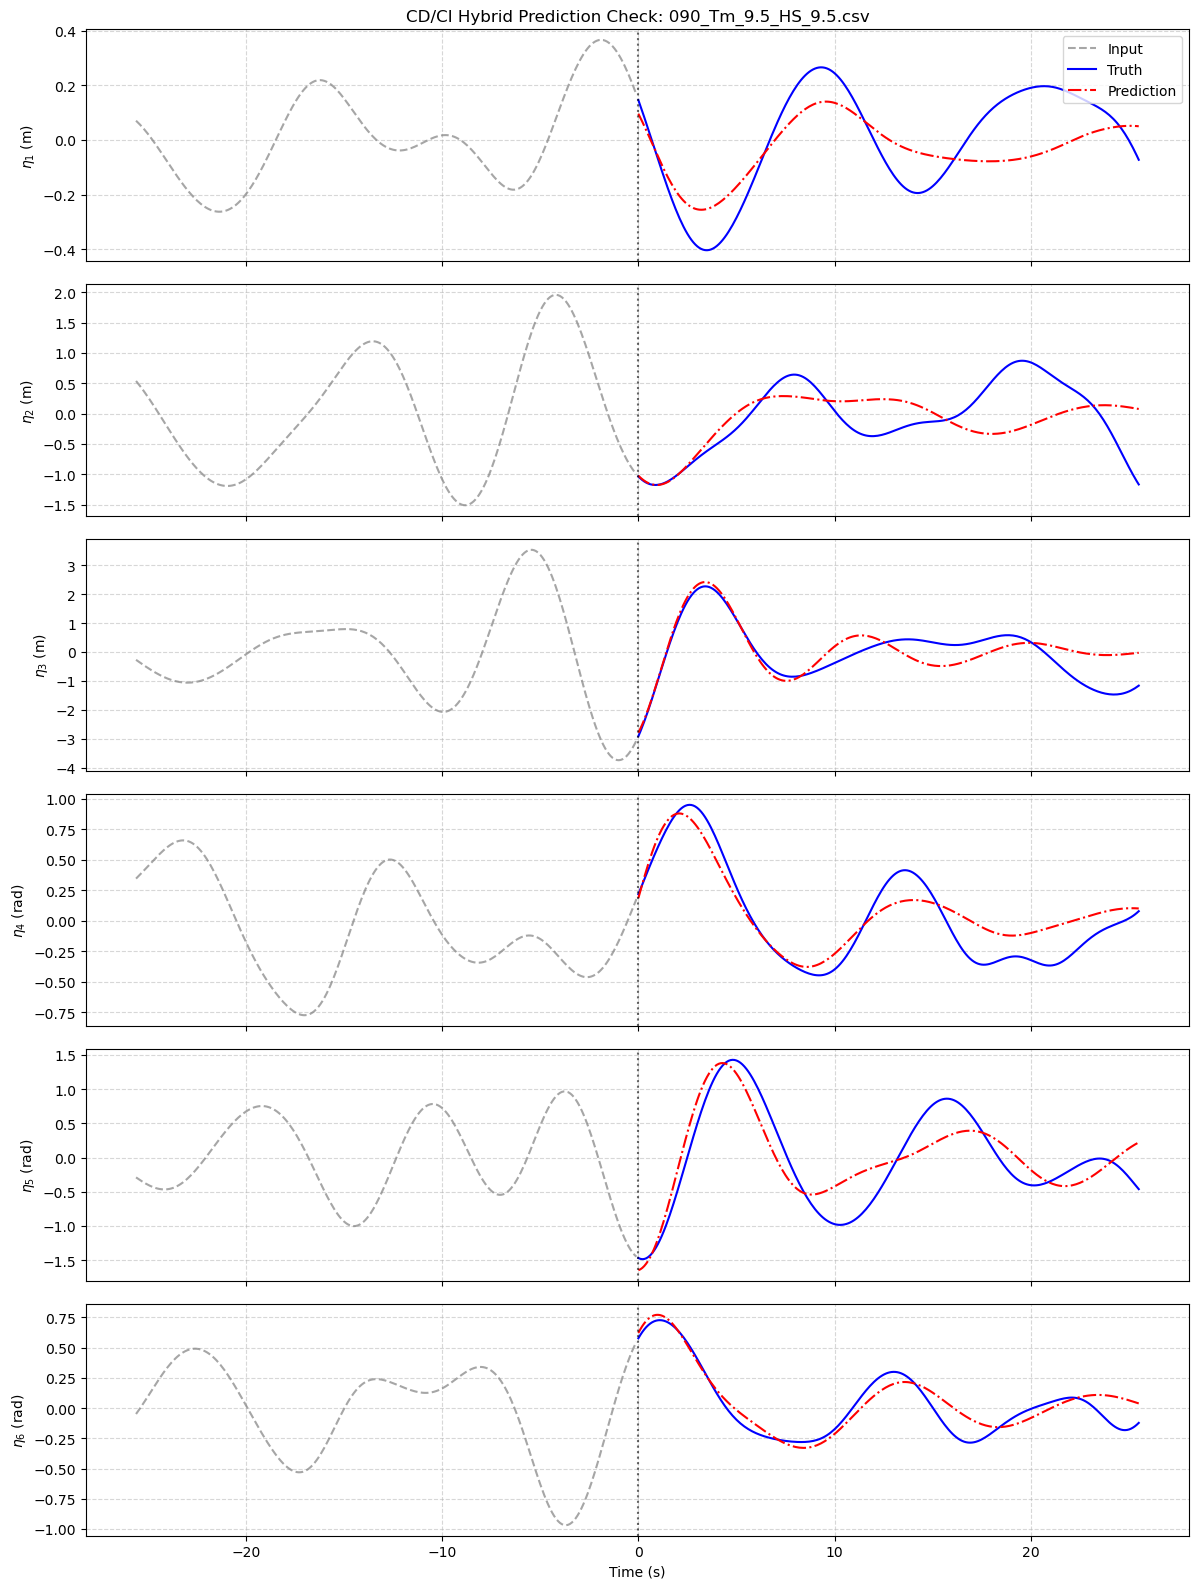

In [11]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Conda Auto 환경 라이브러리를 우선 사용해 CUDA/cuDNN 충돌을 줄인다.
conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    conda_lib = str(Path(conda_prefix) / "lib")
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = (
            f"{conda_lib}:{ld_library_path}" if ld_library_path else conda_lib
        )

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0,1")

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.backends.cudnn.enabled = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("cuDNN enabled:", torch.backends.cudnn.enabled)

# ==============================
# 1. 모델 정의
# ==============================
class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x

class SharedClusterBlock(nn.Module):
    def __init__(self, channels, kernel_size=31, expansion=2.0, dropout=0.1):
        super().__init__()

        hidden_dim = int(channels * expansion)
        padding = kernel_size // 2

        self.dwconv = nn.Conv1d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=channels,
            bias=True,
        )
        self.norm = ChannelLayerNorm(channels)
        self.ffn = nn.Sequential(
            nn.Conv1d(channels, hidden_dim, kernel_size=1, bias=True),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, channels, kernel_size=1, bias=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        residual = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.ffn(x)
        x = x + residual
        return x

class SharedClusterEncoder(nn.Module):
    def __init__(
        self,
        cluster_size=3,
        hidden_channels=96,
        num_blocks=5,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
    ):
        super().__init__()

        stem_padding = stem_kernel_size // 2

        self.input_proj = nn.Conv1d(
            in_channels=cluster_size,
            out_channels=hidden_channels,
            kernel_size=stem_kernel_size,
            padding=stem_padding,
            bias=True,
        )

        self.blocks = nn.ModuleList([
            SharedClusterBlock(
                channels=hidden_channels,
                kernel_size=kernel_size,
                expansion=expansion,
                dropout=dropout,
            )
            for _ in range(num_blocks)
        ])

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.input_proj(x)
        for block in self.blocks:
            x = block(x)
        x = x.transpose(1, 2)
        return x

class SharedClusterHead(nn.Module):
    def __init__(
        self,
        hidden_channels=96,
        out_len=256,
        cluster_size=3,
        head_hidden_dim=256,
        dropout=0.1,
    ):
        super().__init__()
        self.out_len = out_len
        self.cluster_size = cluster_size
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len * cluster_size),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(-1, self.out_len, self.cluster_size)
        return x

class CDCIHybridRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=256,
        out_len=256,
        channel_groups=None,
        hidden_channels=96,
        num_blocks=5,
        kernel_size=31,
        expansion=2.0,
        dropout=0.1,
        stem_kernel_size=7,
        head_hidden_dim=256,
    ):
        super().__init__()

        if channel_groups is None:
            channel_groups = [[0, 1, 2], [3, 4, 5]]

        self.out_len = out_len
        self.out_dof = out_dof
        self.channel_groups = channel_groups

        group_sizes = [len(g) for g in channel_groups]
        self.cluster_size = group_sizes[0]

        self.shared_encoder = SharedClusterEncoder(
            cluster_size=self.cluster_size,
            hidden_channels=hidden_channels,
            num_blocks=num_blocks,
            kernel_size=kernel_size,
            expansion=expansion,
            dropout=dropout,
            stem_kernel_size=stem_kernel_size,
        )

        self.shared_head = SharedClusterHead(
            hidden_channels=hidden_channels,
            out_len=out_len,
            cluster_size=self.cluster_size,
            head_hidden_dim=head_hidden_dim,
            dropout=dropout,
        )

    def forward(self, src):
        batch_size = src.size(0)
        pred_full = src.new_zeros((batch_size, self.out_len, self.out_dof))

        for group in self.channel_groups:
            x_group = src[:, :, group]
            z_group = self.shared_encoder(x_group)
            y_group = self.shared_head(z_group)
            pred_full[:, :, group] = y_group

        return pred_full

# ==============================
# 2. 체크포인트 로드
# ==============================
MODEL_PATH = "models_CDCIHybrid/cdcihybrid_dataset_grid_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
time_col = checkpoint["time_col"]
dof_cols = checkpoint["dof_cols"]
data_min = checkpoint["data_min"].astype(np.float32)
data_range = checkpoint["data_range"].astype(np.float32)

model = CDCIHybridRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    channel_groups=model_config["channel_groups"],
    hidden_channels=model_config["hidden_channels"],
    num_blocks=model_config["num_blocks"],
    kernel_size=model_config["kernel_size"],
    expansion=model_config["expansion"],
    dropout=model_config["dropout"],
    stem_kernel_size=model_config["stem_kernel_size"],
    head_hidden_dim=model_config["head_hidden_dim"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("모델 로드 완료")
print("time_col:", time_col)
print("dof_cols:", dof_cols)
print("channel_groups:", model_config["channel_group_names"])

# ==============================
# 3. 예측 대상 CSV 읽기
# ==============================
CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

start_idx = 210

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("선택한 start_idx 기준으로 IN_LEN + OUT_LEN이 데이터 길이를 초과합니다.")

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_scaled = model(x_tensor).squeeze(0).cpu().numpy()

y_pred_raw = y_pred_scaled * data_range + data_min

print("입력 shape:", x_raw.shape)
print("예측 shape:", y_pred_raw.shape)

# ==============================
# 4. 결과 시각화
# ==============================
fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)

sampling_rate = 0.1
t_input = np.arange(-IN_LEN, 0) * sampling_rate
t_future = np.arange(OUT_LEN) * sampling_rate

latex_labels = [
    r"$\eta_1$ (m)", r"$\eta_2$ (m)", r"$\eta_3$ (m)", 
    r"$\eta_4$ (rad)", r"$\eta_5$ (rad)", r"$\eta_6$ (rad)"
]

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", color="gray", alpha=0.7, label="Input")
    ax.plot(t_future, y_true_raw[:, i], color="blue", label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], color="red", linestyle="-.", label="Prediction")
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    ax.set_ylabel(latex_labels[i])
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_title(f"CD/CI Hybrid Prediction Check: {CSV_PATH.name}")
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 5. SRADecider

### 5.1. SRA Decider Hybrid Prediction Example

py_SRADecider.py

The **SRA Decider** model is designed to dynamically determine whether multivariate ship-motion data should be processed using a **Channel-Independent (CI)** pathway or a **Channel-Dependent (CD)** pathway. Unlike a fixed hybrid model, which always uses a predefined channel grouping strategy, the SRA Decider evaluates the correlation structure of each input sequence and adaptively combines the outputs of the CI and CD models.

The CI pathway processes each degree of freedom independently using shared model parameters. This structure reduces the risk of overfitting to noisy cross-channel relationships and allows each motion component to preserve its own temporal characteristics. In contrast, the CD pathway processes all six motion variables jointly and is therefore able to learn interactions among surge, sway, heave, roll, pitch, and yaw. Both pathways use convolution-based temporal encoders with residual connections, Channel-wise Layer Normalization, GELU activation, dropout, and Global Average Pooling.

To determine the relative contribution of the two pathways, the model calculates an **SRA score** based on the mean absolute off-diagonal Spearman rank correlation among the input channels. A high SRA score indicates stronger inter-variable dependence and increases the weight assigned to the CD prediction. A low SRA score indicates weaker channel correlation and increases the contribution of the CI prediction. The CD gate weight is calculated using a sigmoid function controlled by the predefined SRA threshold and temperature:

$$
g_{\mathrm{CD}}
=
\sigma\left(
\frac{s_{\mathrm{SRA}}-\tau}{T}
\right),
$$

where $s_{\mathrm{SRA}}$ is the calculated SRA score, $\tau$ is the correlation threshold, and $T$ is the temperature parameter controlling the smoothness of the transition. The final prediction is obtained by softly combining the two outputs:

$$
\hat{\mathbf{Y}}
=
g_{\mathrm{CD}}\hat{\mathbf{Y}}_{\mathrm{CD}}
+
\left(1-g_{\mathrm{CD}}\right)\hat{\mathbf{Y}}_{\mathrm{CI}}.
$$

This notebook loads the trained SRA Decider checkpoint and evaluates it on a representative ship-motion sequence. A 256-step input sequence is used to predict the following 256 time steps for all six degrees of freedom. In addition to comparing the predicted and ground-truth trajectories, the code reports the SRA score, the CD gate weight, and the CI gate weight. These values provide an interpretable indication of whether the model relied more strongly on inter-channel dependence or channel-wise independent temporal patterns for the selected input sequence.

Using device: cuda:0
cuDNN enabled: False
모델 로드 완료
time_col: t (s)
dof_cols: ['<greek>x</greek><sub>1</sub> (m)', '<greek>x</greek><sub>2</sub> (m)', '<greek>x</greek><sub>3</sub> (m)', '<greek>x</greek><sub>4</sub> (deg)', '<greek>x</greek><sub>5</sub> (deg)', '<greek>x</greek><sub>6</sub> (deg)']
model_type: SRADeciderHybrid
입력 shape: (256, 6)
예측 shape: (256, 6)
SRA score: 0.394543
CD gate weight: 0.709067
CI gate weight: 0.290933


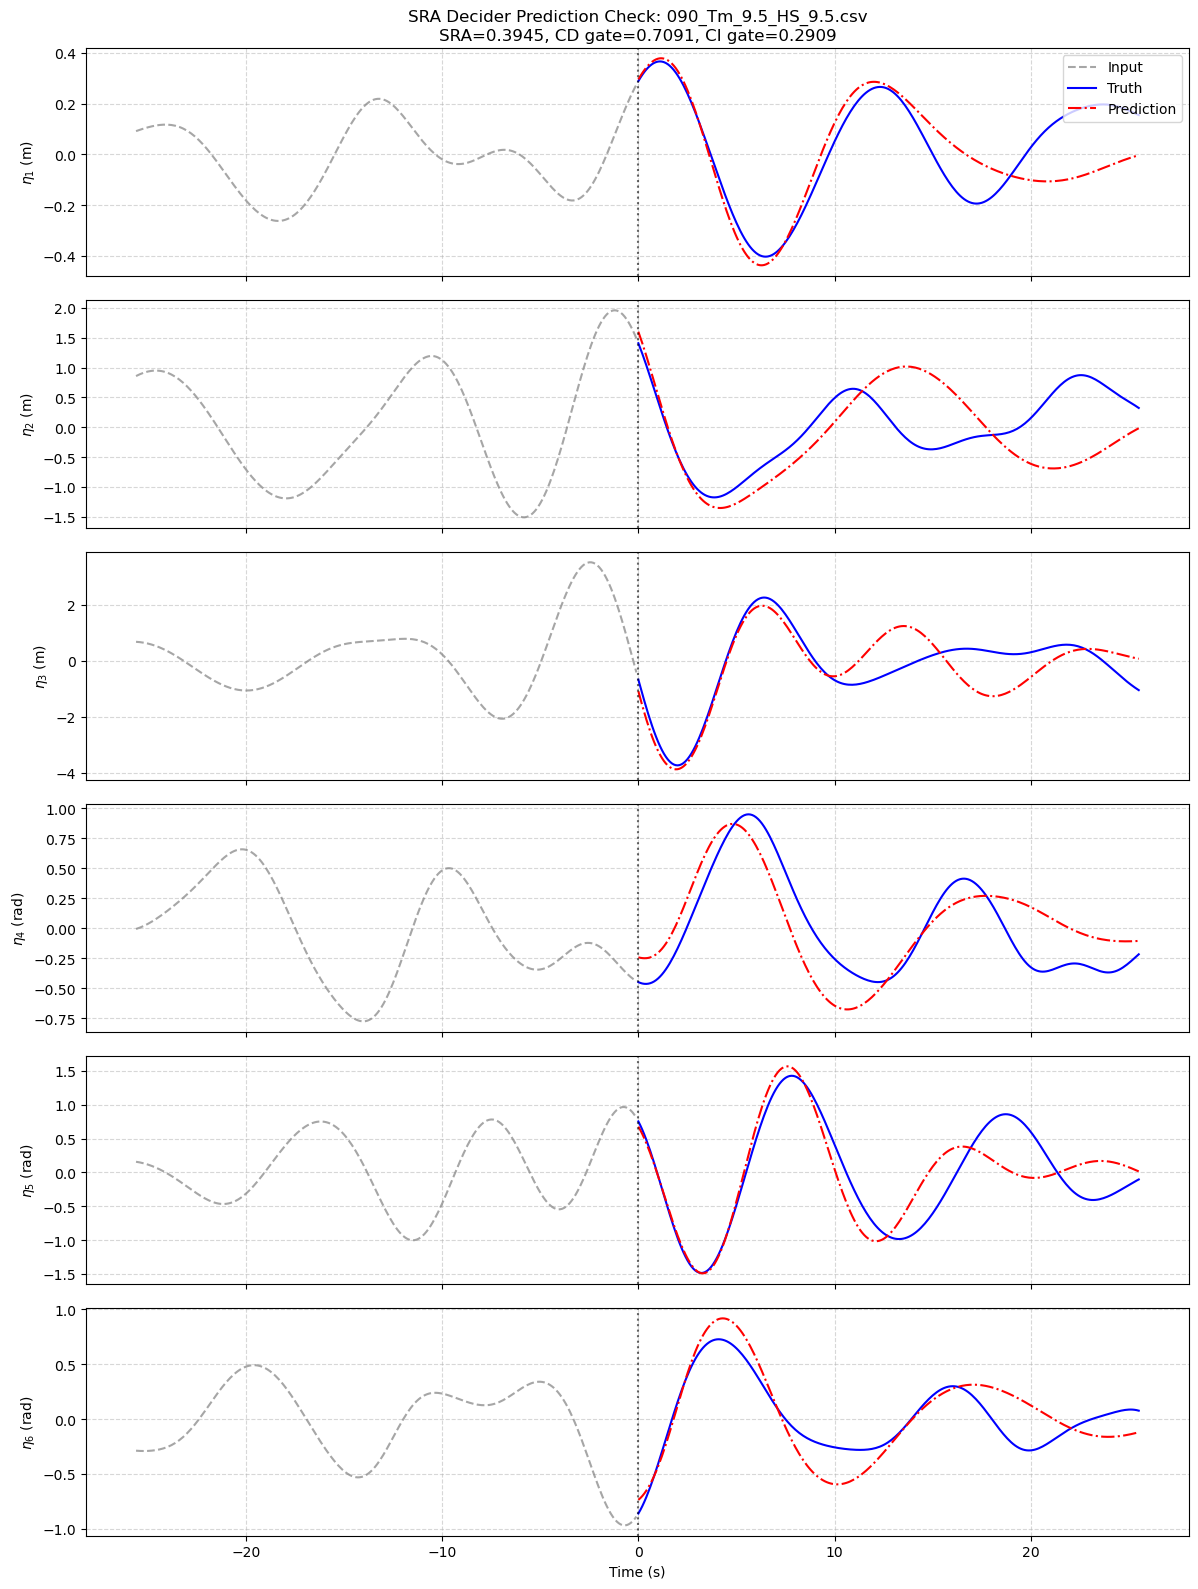

In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Conda Auto 환경 라이브러리를 우선 사용해 CUDA/cuDNN 충돌을 줄인다.
conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    conda_lib = str(Path(conda_prefix) / "lib")
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = (
            f"{conda_lib}:{ld_library_path}" if ld_library_path else conda_lib
        )

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0,1")

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.backends.cudnn.enabled = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("cuDNN enabled:", torch.backends.cudnn.enabled)

# ==============================
# 1. 모델 정의
# ==============================
class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x

def torch_rankdata(x: torch.Tensor) -> torch.Tensor:
    order = torch.argsort(x, dim=1)
    ranks = torch.argsort(order, dim=1).float()
    return ranks

def batch_spearman_mean_abs_offdiag(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    B, T, C = x.shape
    ranks = torch_rankdata(x)
    ranks = ranks - ranks.mean(dim=1, keepdim=True)
    std = torch.sqrt((ranks ** 2).mean(dim=1, keepdim=True) + eps)
    z = ranks / std
    corr = torch.matmul(z.transpose(1, 2), z) / T

    eye = torch.eye(C, device=x.device).unsqueeze(0)
    offdiag_mask = 1.0 - eye
    abs_offdiag = corr.abs() * offdiag_mask
    denom = C * (C - 1)

    score = abs_offdiag.sum(dim=(1, 2)) / denom
    return score

class CISharedEncoder(nn.Module):
    def __init__(self, hidden_channels=64, num_blocks=4, kernel_size=31, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2
        self.stem = nn.Conv1d(1, hidden_channels, kernel_size=7, padding=3, bias=True)

        blocks = []
        for _ in range(num_blocks):
            blocks.append(nn.Sequential(
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=kernel_size,
                          padding=padding, groups=hidden_channels, bias=True),
                ChannelLayerNorm(hidden_channels),
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=1, bias=True),
                nn.GELU(),
                nn.Dropout(dropout),
            ))
        self.blocks = nn.ModuleList(blocks)

    def forward(self, x):
        B, T, C = x.shape
        x = x.permute(0, 2, 1).contiguous()
        x = x.view(B * C, 1, T)

        x = self.stem(x)
        for block in self.blocks:
            residual = x
            x = block(x)
            x = x + residual

        x = x.transpose(1, 2)
        hidden = x.size(-1)
        x = x.view(B, C, T, hidden)
        x = x.permute(0, 2, 1, 3).contiguous()
        return x

class CISharedHead(nn.Module):
    def __init__(self, hidden_channels=64, out_len=256, head_hidden_dim=128, dropout=0.1):
        super().__init__()
        self.out_len = out_len
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len),
            nn.Sigmoid(),
        )

    def forward(self, x):
        B, T, C, H = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()
        x = x.view(B * C, H, T)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(B, C, self.out_len)
        x = x.permute(0, 2, 1).contiguous()
        return x

class CDEncoder(nn.Module):
    def __init__(self, in_dof=6, hidden_channels=128, num_blocks=5, kernel_size=31, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2
        self.stem = nn.Conv1d(in_dof, hidden_channels, kernel_size=7, padding=3, bias=True)

        blocks = []
        for _ in range(num_blocks):
            blocks.append(nn.Sequential(
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=kernel_size,
                          padding=padding, groups=1, bias=True),
                ChannelLayerNorm(hidden_channels),
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=1, bias=True),
                nn.GELU(),
                nn.Dropout(dropout),
            ))
        self.blocks = nn.ModuleList(blocks)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.stem(x)
        for block in self.blocks:
            residual = x
            x = block(x)
            x = x + residual
        x = x.transpose(1, 2)
        return x

class CDHead(nn.Module):
    def __init__(self, hidden_channels=128, out_len=256, out_dof=6, head_hidden_dim=256, dropout=0.1):
        super().__init__()
        self.out_len = out_len
        self.out_dof = out_dof
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len * out_dof),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(-1, self.out_len, self.out_dof)
        return x

class SRADeciderHybridRegressor(nn.Module):
    def __init__(
        self,
        in_dof=6,
        out_dof=6,
        in_len=256,
        out_len=256,
        ci_hidden_channels=64,
        ci_num_blocks=4,
        cd_hidden_channels=128,
        cd_num_blocks=5,
        kernel_size=31,
        dropout=0.1,
        ci_head_hidden_dim=128,
        cd_head_hidden_dim=256,
        sra_threshold=0.35,
        sra_temperature=0.05,
    ):
        super().__init__()

        self.out_len = out_len
        self.out_dof = out_dof
        self.sra_threshold = float(sra_threshold)
        self.sra_temperature = float(sra_temperature)

        self.ci_encoder = CISharedEncoder(
            hidden_channels=ci_hidden_channels,
            num_blocks=ci_num_blocks,
            kernel_size=kernel_size,
            dropout=dropout,
        )
        self.ci_head = CISharedHead(
            hidden_channels=ci_hidden_channels,
            out_len=out_len,
            head_hidden_dim=ci_head_hidden_dim,
            dropout=dropout,
        )

        self.cd_encoder = CDEncoder(
            in_dof=in_dof,
            hidden_channels=cd_hidden_channels,
            num_blocks=cd_num_blocks,
            kernel_size=kernel_size,
            dropout=dropout,
        )
        self.cd_head = CDHead(
            hidden_channels=cd_hidden_channels,
            out_len=out_len,
            out_dof=out_dof,
            head_hidden_dim=cd_head_hidden_dim,
            dropout=dropout,
        )

    def compute_gate(self, src):
        sra_score = batch_spearman_mean_abs_offdiag(src)
        gate = torch.sigmoid((sra_score - self.sra_threshold) / self.sra_temperature)
        gate = gate.view(-1, 1, 1)
        return gate, sra_score

    def forward(self, src, return_gate=False):
        ci_feat = self.ci_encoder(src)
        ci_out = self.ci_head(ci_feat)

        cd_feat = self.cd_encoder(src)
        cd_out = self.cd_head(cd_feat)

        gate, sra_score = self.compute_gate(src)
        out = gate * cd_out + (1.0 - gate) * ci_out

        if return_gate:
            return out, gate.squeeze(-1).squeeze(-1), sra_score
        return out

# ==============================
# 2. 체크포인트 로드
# ==============================
MODEL_PATH = "models_SRADecider/sra_decider_dataset_grid_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
time_col = checkpoint["time_col"]
dof_cols = checkpoint["dof_cols"]
data_min = checkpoint["data_min"].astype(np.float32)
data_range = checkpoint["data_range"].astype(np.float32)

model = SRADeciderHybridRegressor(
    in_dof=model_config["in_dof"],
    out_dof=model_config["out_dof"],
    in_len=model_config["in_len"],
    out_len=model_config["out_len"],
    ci_hidden_channels=model_config["ci_hidden_channels"],
    ci_num_blocks=model_config["ci_num_blocks"],
    cd_hidden_channels=model_config["cd_hidden_channels"],
    cd_num_blocks=model_config["cd_num_blocks"],
    kernel_size=model_config["kernel_size"],
    dropout=model_config["dropout"],
    ci_head_hidden_dim=model_config["ci_head_hidden_dim"],
    cd_head_hidden_dim=model_config["cd_head_hidden_dim"],
    sra_threshold=model_config["sra_threshold"],
    sra_temperature=model_config["sra_temperature"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("모델 로드 완료")
print("time_col:", time_col)
print("dof_cols:", dof_cols)
print("model_type:", model_config["model_type"])

# ==============================
# 3. 예측 대상 CSV 읽기
# ==============================
CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

values = df[dof_cols].to_numpy(dtype=np.float32)
time_values = df[time_col].to_numpy()

IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

start_idx = 180

if start_idx + IN_LEN + OUT_LEN > len(df):
    raise ValueError("선택한 start_idx 기준으로 IN_LEN + OUT_LEN이 데이터 길이를 초과합니다.")

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_scaled, gate_val, sra_score = model(x_tensor, return_gate=True)
    y_pred_scaled = y_pred_scaled.squeeze(0).cpu().numpy()
    gate_val = gate_val.item()
    sra_score = sra_score.item()

y_pred_raw = y_pred_scaled * data_range + data_min

print("입력 shape:", x_raw.shape)
print("예측 shape:", y_pred_raw.shape)
print(f"SRA score: {sra_score:.6f}")
print(f"CD gate weight: {gate_val:.6f}")
print(f"CI gate weight: {1.0 - gate_val:.6f}")

# ==============================
# 4. 결과 시각화
# ==============================
fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)

sampling_rate = 0.1
t_input = np.arange(-IN_LEN, 0) * sampling_rate
t_future = np.arange(OUT_LEN) * sampling_rate

latex_labels = [
    r"$\eta_1$ (m)", r"$\eta_2$ (m)", r"$\eta_3$ (m)", 
    r"$\eta_4$ (rad)", r"$\eta_5$ (rad)", r"$\eta_6$ (rad)"
]

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", color="gray", alpha=0.7, label="Input")
    ax.plot(t_future, y_true_raw[:, i], color="blue", label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], color="red", linestyle="-.", label="Prediction")
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    ax.set_ylabel(latex_labels[i])
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_title(
    f"SRA Decider Prediction Check: {CSV_PATH.name}\n"
    f"SRA={sra_score:.4f}, CD gate={gate_val:.4f}, CI gate={1.0-gate_val:.4f}"
)
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

### 5.2. 

경계 지점 불연속 발생 원인 제거



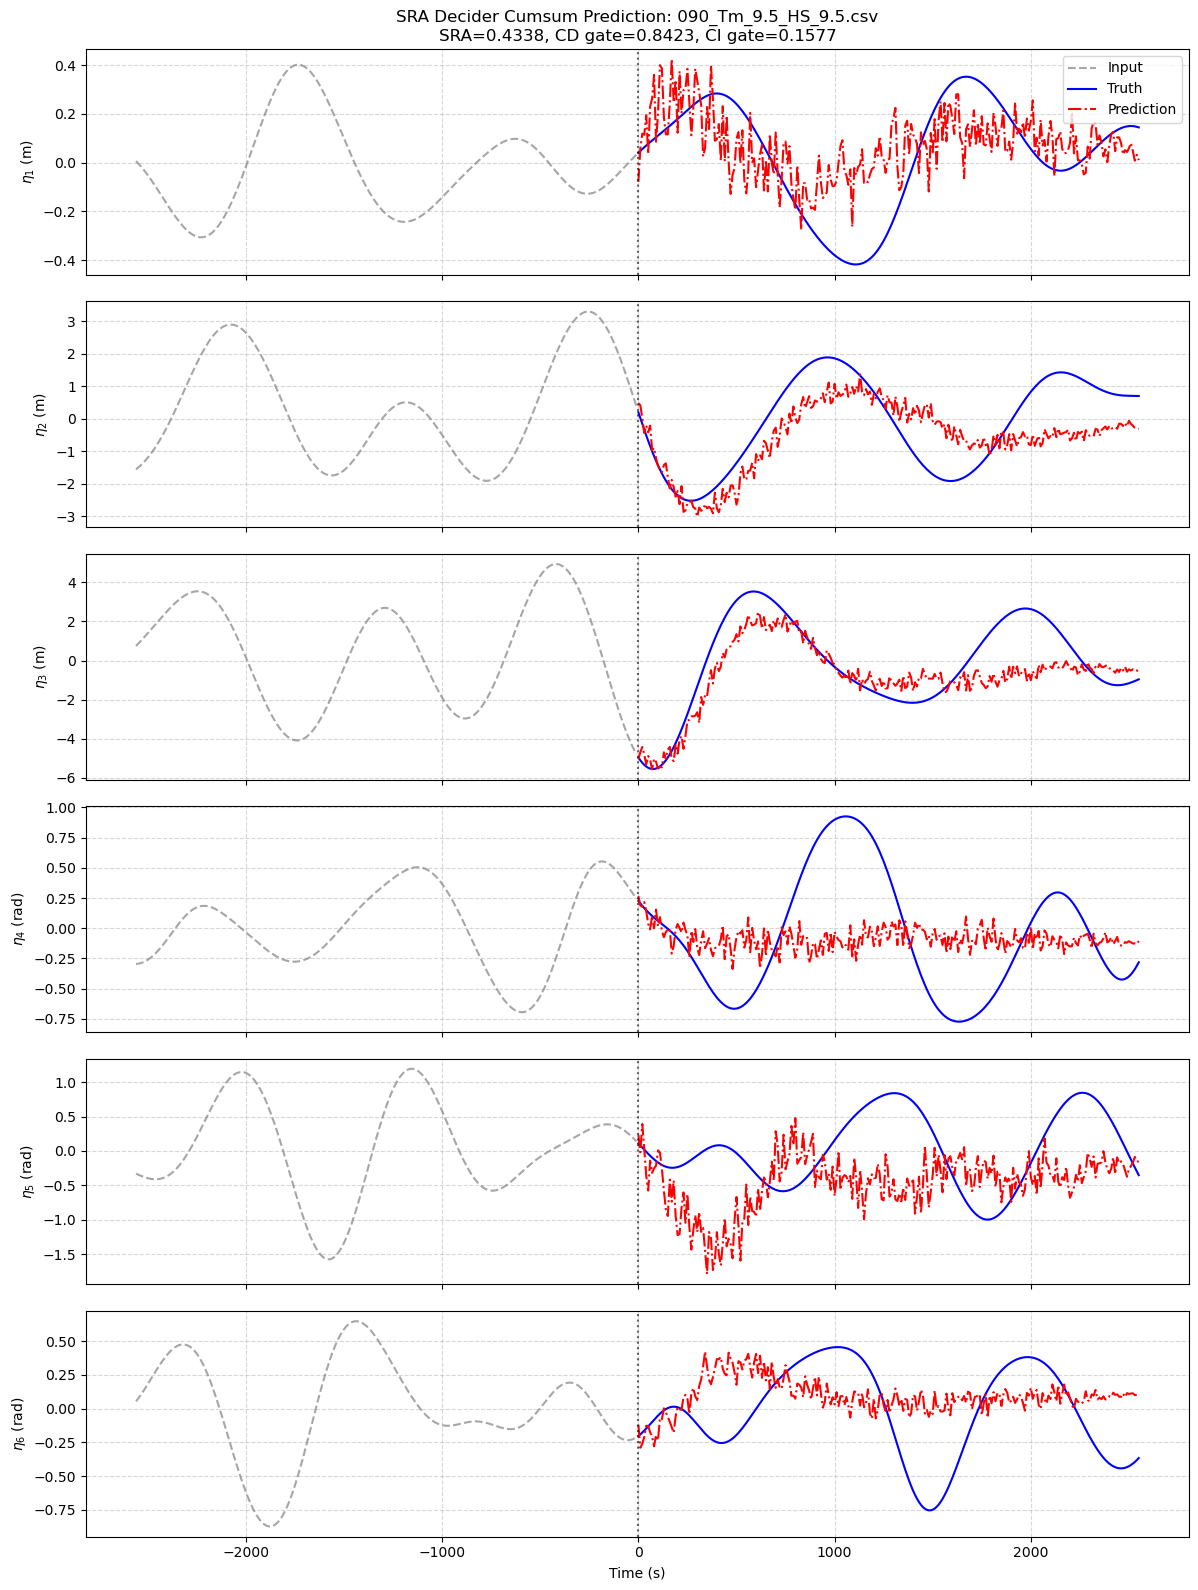

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Conda / CUDA 설정
conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    conda_lib = str(Path(conda_prefix) / "lib")
    ld_library_path = os.environ.get("LD_LIBRARY_PATH", "")
    ld_parts = [p for p in ld_library_path.split(":") if p]
    if conda_lib not in ld_parts:
        os.environ["LD_LIBRARY_PATH"] = (
            f"{conda_lib}:{ld_library_path}" if ld_library_path else conda_lib
        )

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0,1")

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.backends.cudnn.enabled = False
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ==============================
# 1. 모델 정의 (Cumsum 아키텍처)
# ==============================
class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2)
        return x

def torch_rankdata(x: torch.Tensor) -> torch.Tensor:
    order = torch.argsort(x, dim=1)
    ranks = torch.argsort(order, dim=1).float()
    return ranks

def batch_spearman_mean_abs_offdiag(x: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    B, T, C = x.shape
    ranks = torch_rankdata(x)
    ranks = ranks - ranks.mean(dim=1, keepdim=True)
    std = torch.sqrt((ranks ** 2).mean(dim=1, keepdim=True) + eps)
    z = ranks / std
    corr = torch.matmul(z.transpose(1, 2), z) / T
    eye = torch.eye(C, device=x.device).unsqueeze(0)
    offdiag_mask = 1.0 - eye
    abs_offdiag = corr.abs() * offdiag_mask
    return abs_offdiag.sum(dim=(1, 2)) / (C * (C - 1))

class CISharedEncoder(nn.Module):
    def __init__(self, hidden_channels=64, num_blocks=4, kernel_size=31, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2
        self.stem = nn.Conv1d(1, hidden_channels, kernel_size=7, padding=3, bias=True)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=kernel_size,
                          padding=padding, groups=hidden_channels, bias=True),
                ChannelLayerNorm(hidden_channels),
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=1, bias=True),
                nn.GELU(),
                nn.Dropout(dropout),
            ) for _ in range(num_blocks)
        ])

    def forward(self, x):
        B, T, C = x.shape
        x = x.permute(0, 2, 1).contiguous()
        x = x.view(B * C, 1, T)
        x = self.stem(x)
        for block in self.blocks:
            x = x + block(x)
        x = x.transpose(1, 2)
        hidden = x.size(-1)
        x = x.view(B, C, T, hidden)
        x = x.permute(0, 2, 1, 3).contiguous()
        return x

class CISharedHead(nn.Module):
    def __init__(self, hidden_channels=64, out_len=256, head_hidden_dim=128, dropout=0.1):
        super().__init__()
        self.out_len = out_len
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len),
        )

    def forward(self, x):
        B, T, C, H = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()
        x = x.view(B * C, H, T)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(B, C, self.out_len)
        x = x.permute(0, 2, 1).contiguous()
        return x

class CDEncoder(nn.Module):
    def __init__(self, in_dof=6, hidden_channels=128, num_blocks=5, kernel_size=31, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2
        self.stem = nn.Conv1d(in_dof, hidden_channels, kernel_size=7, padding=3, bias=True)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=kernel_size,
                          padding=padding, groups=1, bias=True),
                ChannelLayerNorm(hidden_channels),
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=1, bias=True),
                nn.GELU(),
                nn.Dropout(dropout),
            ) for _ in range(num_blocks)
        ])

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.stem(x)
        for block in self.blocks:
            x = x + block(x)
        x = x.transpose(1, 2)
        return x

class CDHead(nn.Module):
    def __init__(self, hidden_channels=128, out_len=256, out_dof=6, head_hidden_dim=256, dropout=0.1):
        super().__init__()
        self.out_len = out_len
        self.out_dof = out_dof
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels, head_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_hidden_dim, out_len * out_dof),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.global_pool(x)
        x = self.head(x)
        x = x.view(-1, self.out_len, self.out_dof)
        return x

class SRADeciderHybridCumsum(nn.Module):
    def __init__(
        self,
        in_dof=6, out_dof=6, in_len=256, out_len=256,
        ci_hidden_channels=64, ci_num_blocks=4,
        cd_hidden_channels=128, cd_num_blocks=5,
        kernel_size=31, dropout=0.1,
        ci_head_hidden_dim=128, cd_head_hidden_dim=256,
        sra_threshold=0.35, sra_temperature=0.05,
    ):
        super().__init__()
        self.sra_threshold = float(sra_threshold)
        self.sra_temperature = float(sra_temperature)

        self.ci_encoder = CISharedEncoder(ci_hidden_channels, ci_num_blocks, kernel_size, dropout)
        self.ci_head = CISharedHead(ci_hidden_channels, out_len, ci_head_hidden_dim, dropout)
        self.cd_encoder = CDEncoder(in_dof, cd_hidden_channels, cd_num_blocks, kernel_size, dropout)
        self.cd_head = CDHead(cd_hidden_channels, out_len, out_dof, cd_head_hidden_dim, dropout)

    def compute_gate(self, src):
        sra_score = batch_spearman_mean_abs_offdiag(src)
        gate = torch.sigmoid((sra_score - self.sra_threshold) / self.sra_temperature)
        return gate.view(-1, 1, 1), sra_score

    def forward(self, src, return_gate=False):
        x_last = src[:, -1:, :]

        ci_delta = self.ci_head(self.ci_encoder(src))
        cd_delta = self.cd_head(self.cd_encoder(src))

        gate, sra_score = self.compute_gate(src)
        delta = gate * cd_delta + (1.0 - gate) * ci_delta

        out = x_last + torch.cumsum(delta, dim=1)

        if return_gate:
            return out, gate.squeeze(-1).squeeze(-1), sra_score
        return out

# ==============================
# 2. 체크포인트 로드
# ==============================
MODEL_PATH = "models_Cumsum/sra_decider_cumsum_best_full.pt"
checkpoint = torch.load(MODEL_PATH, map_location=device)

model_config = checkpoint["model_config"]
time_col = checkpoint["time_col"]
dof_cols = checkpoint["dof_cols"]
data_min = checkpoint["data_min"].astype(np.float32)
data_max = checkpoint["data_max"].astype(np.float32)
data_range = checkpoint["data_range"].astype(np.float32)

model_kwargs = {k: v for k, v in model_config.items() if k != "model_type"}
model = SRADeciderHybridCumsum(**model_kwargs).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# ==============================
# 3. 데이터 로드 및 분할 지점 설정
# ==============================
CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

values = df[dof_cols].to_numpy(dtype=np.float32)
IN_LEN = model_config["in_len"]
OUT_LEN = model_config["out_len"]

# 훈련에 노출되지 않은 Test 구간(85% 이후)에서 샘플링 추출
test_start_boundary = int(len(df) * 0.85)
start_idx = test_start_boundary + 180 

if start_idx + IN_LEN + OUT_LEN > len(df):
    start_idx = len(df) - IN_LEN - OUT_LEN

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

# 저장된 Train set 스케일러로 적용
x_scaled = (x_raw - data_min) / data_range
x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)

# ==============================
# 4. 추론 및 역스케일링
# ==============================
with torch.no_grad():
    y_pred_scaled, gate_val, sra_score = model(x_tensor, return_gate=True)
    y_pred_scaled = y_pred_scaled.squeeze(0).cpu().numpy()
    gate_val = gate_val.item()
    sra_score = sra_score.item()

y_pred_raw = y_pred_scaled * data_range + data_min

# ==============================
# 5. 시각화
# ==============================
fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)

sampling_rate = checkpoint.get("sampling_rate", 0.1) # 기본값 0.1초 할당
t_input = np.arange(-IN_LEN, 0) * sampling_rate
t_future = np.arange(OUT_LEN) * sampling_rate

latex_labels = [
    r"$\eta_1$ (m)", r"$\eta_2$ (m)", r"$\eta_3$ (m)", 
    r"$\eta_4$ (rad)", r"$\eta_5$ (rad)", r"$\eta_6$ (rad)"
]

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], linestyle="--", color="gray", alpha=0.7, label="Input")
    ax.plot(t_future, y_true_raw[:, i], color="blue", label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], color="red", linestyle="-.", label="Prediction")
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    ax.set_ylabel(latex_labels[i])
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_title(
    f"SRA Decider Cumsum Prediction: {CSV_PATH.name}\n"
    f"SRA={sra_score:.4f}, CD gate={gate_val:.4f}, CI gate={1.0-gate_val:.4f}"
)
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()

### 5.3. SRA Decider with Continuity Loss

The previous SRA Decider model produced accurate future trajectories; however, a noticeable discontinuity occasionally appeared between the **last observed input point** and the **first predicted output point**. Although the prediction error over the entire forecast horizon remained relatively small, this discontinuity reduced the physical realism of the predicted ship-motion time series and could become problematic in applications requiring smooth transitions, such as real-time control and onboard decision support.

To address this issue, a **continuity loss** was introduced during training. In addition to the original prediction loss, an auxiliary loss term penalizes the difference between the final sample of the input sequence and the first sample of the predicted sequence. The overall training objective is formulated as

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{prediction}}
+
\lambda
\mathcal{L}_{\mathrm{continuity}},
$$

where $\lambda$ controls the relative importance of the continuity constraint. Different values of $\lambda$ were evaluated to identify the best balance between overall prediction accuracy and temporal continuity, and the optimal model checkpoint was selected automatically according to the validation performance.

This notebook loads the best-performing model obtained from the continuity-loss search and visualizes its prediction results on the test dataset. In addition to the predicted and ground-truth trajectories, the selected continuity-loss coefficient ($\lambda$), the SRA score, and the CD gate weight are reported. The resulting visualization demonstrates that the continuity constraint substantially reduces the discontinuity at the prediction boundary while preserving the long-term forecasting capability of the SRA Decider model.

로드된 최적 모델 Lambda: 0.0


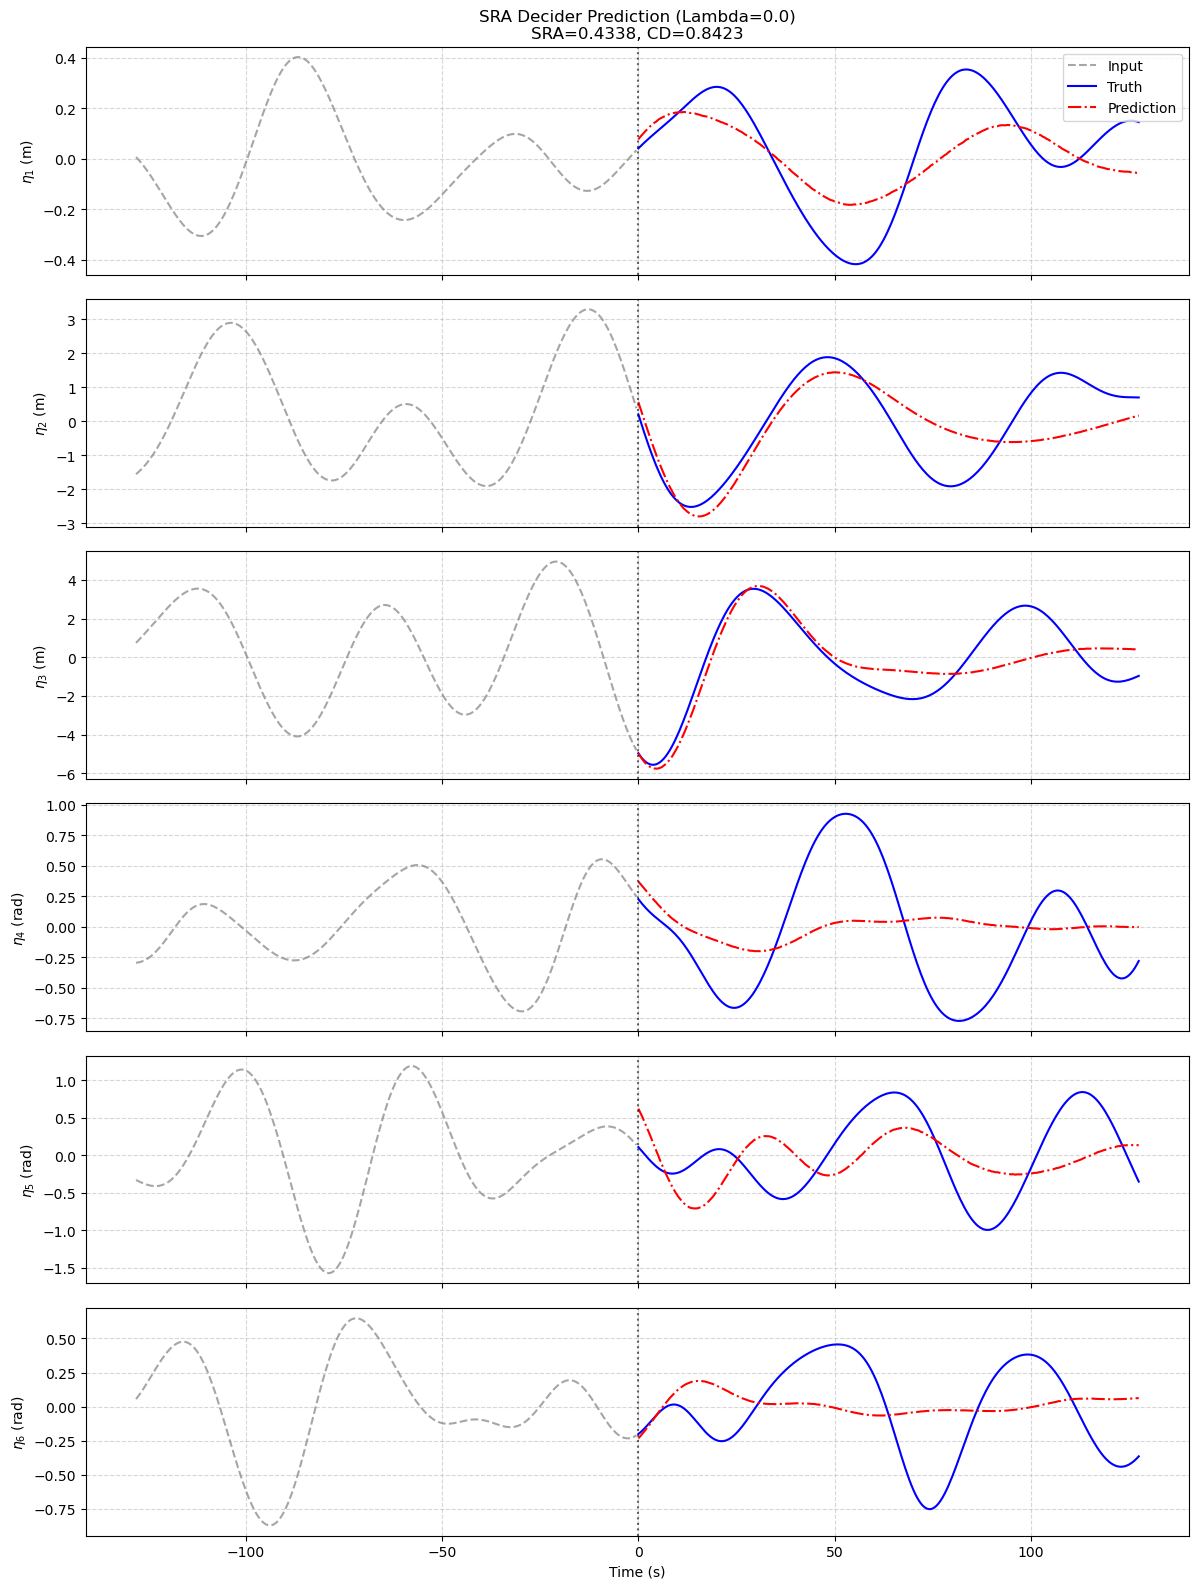

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# ==============================
# 1. 모델 아키텍처 재정의 (Sigmoid 제외 버전)
# ==============================
class ChannelLayerNorm(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)
    def forward(self, x): return self.norm(x.transpose(1, 2)).transpose(1, 2)

def batch_spearman_mean_abs_offdiag(x, eps=1e-8):
    ranks = torch.argsort(torch.argsort(x, dim=1), dim=1).float()
    ranks = ranks - ranks.mean(dim=1, keepdim=True)
    std = torch.sqrt((ranks ** 2).mean(dim=1, keepdim=True) + eps)
    corr = torch.matmul((ranks/std).transpose(1, 2), ranks/std) / x.shape[1]
    eye = torch.eye(x.shape[2], device=x.device).unsqueeze(0)
    return (corr.abs() * (1.0 - eye)).sum(dim=(1, 2)) / (x.shape[2] * (x.shape[2] - 1))

class CISharedEncoder(nn.Module):
    def __init__(self, hidden_channels, num_blocks, kernel_size, dropout):
        super().__init__()
        self.stem = nn.Conv1d(1, hidden_channels, kernel_size=7, padding=3, bias=True)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=kernel_size, padding=kernel_size//2, groups=hidden_channels, bias=True),
                ChannelLayerNorm(hidden_channels), nn.Conv1d(hidden_channels, hidden_channels, kernel_size=1, bias=True),
                nn.GELU(), nn.Dropout(dropout)
            ) for _ in range(num_blocks)
        ])
    def forward(self, x):
        B, T, C = x.shape
        x = self.stem(x.permute(0, 2, 1).contiguous().view(B * C, 1, T))
        for block in self.blocks: x = x + block(x)
        return x.transpose(1, 2).view(B, C, T, -1).permute(0, 2, 1, 3).contiguous()

class CISharedHead(nn.Module):
    def __init__(self, hidden_channels, out_len, head_hidden_dim, dropout):
        super().__init__()
        self.out_len = out_len
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(hidden_channels, head_hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(head_hidden_dim, out_len)
        )
    def forward(self, x):
        B, T, C, H = x.shape
        return self.head(x.permute(0, 2, 3, 1).contiguous().view(B * C, H, T)).view(B, C, self.out_len).permute(0, 2, 1).contiguous()

class CDEncoder(nn.Module):
    def __init__(self, in_dof, hidden_channels, num_blocks, kernel_size, dropout):
        super().__init__()
        self.stem = nn.Conv1d(in_dof, hidden_channels, kernel_size=7, padding=3, bias=True)
        self.blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(hidden_channels, hidden_channels, kernel_size=kernel_size, padding=kernel_size//2, groups=1, bias=True),
                ChannelLayerNorm(hidden_channels), nn.Conv1d(hidden_channels, hidden_channels, kernel_size=1, bias=True),
                nn.GELU(), nn.Dropout(dropout)
            ) for _ in range(num_blocks)
        ])
    def forward(self, x):
        x = self.stem(x.transpose(1, 2))
        for block in self.blocks: x = x + block(x)
        return x.transpose(1, 2)

class CDHead(nn.Module):
    def __init__(self, hidden_channels, out_len, out_dof, head_hidden_dim, dropout):
        super().__init__()
        self.out_len = out_len; self.out_dof = out_dof
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(hidden_channels, head_hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(head_hidden_dim, out_len * out_dof)
        )
    def forward(self, x):
        return self.head(x.transpose(1, 2)).view(-1, self.out_len, self.out_dof)

class SRADeciderHybridRegressor(nn.Module):
    def __init__(self, in_dof, out_dof, in_len, out_len, ci_hidden_channels, ci_num_blocks, cd_hidden_channels, cd_num_blocks, kernel_size, dropout, ci_head_hidden_dim, cd_head_hidden_dim, sra_threshold, sra_temperature):
        super().__init__()
        self.sra_threshold = float(sra_threshold); self.sra_temperature = float(sra_temperature)
        self.ci_encoder = CISharedEncoder(ci_hidden_channels, ci_num_blocks, kernel_size, dropout)
        self.ci_head = CISharedHead(ci_hidden_channels, out_len, ci_head_hidden_dim, dropout)
        self.cd_encoder = CDEncoder(in_dof, cd_hidden_channels, cd_num_blocks, kernel_size, dropout)
        self.cd_head = CDHead(cd_hidden_channels, out_len, out_dof, cd_head_hidden_dim, dropout)

    def compute_gate(self, src):
        sra_score = batch_spearman_mean_abs_offdiag(src)
        return torch.sigmoid((sra_score - self.sra_threshold) / self.sra_temperature).view(-1, 1, 1), sra_score

    def forward(self, src, return_gate=False):
        gate, sra_score = self.compute_gate(src)
        out = gate * self.cd_head(self.cd_encoder(src)) + (1.0 - gate) * self.ci_head(self.ci_encoder(src))
        if return_gate: return out, gate.squeeze(-1).squeeze(-1), sra_score
        return out

# ==============================
# 2. 모델 로드 (최적 모델)
# ==============================
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "results_SRADecider_LambdaSearch/best_model_lambda_0.0.pt"

checkpoint = torch.load(MODEL_PATH, map_location=device)
data_min = checkpoint["data_min"]
data_range = checkpoint["data_range"]
opt_lambda = checkpoint["lambda_cont"]
print(f"로드된 최적 모델 Lambda: {opt_lambda}")

model = SRADeciderHybridRegressor(**checkpoint["model_config"]).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# ==============================
# 3. 데이터 로드 및 예측
# ==============================
CSV_PATH = Path("dataset_grid/090_Tm_9.5_HS_9.5.csv")
df = pd.read_csv(CSV_PATH)

IN_LEN = checkpoint["in_len"]
OUT_LEN = checkpoint["out_len"]
dof_cols = df.columns[1:7]
values = df[dof_cols].to_numpy(dtype=np.float32)

# Test 구간 추출 (마지막 15%)
test_start_boundary = int(len(df) * 0.85)
start_idx = test_start_boundary + 180 
if start_idx + IN_LEN + OUT_LEN > len(df): start_idx = len(df) - IN_LEN - OUT_LEN

x_raw = values[start_idx:start_idx + IN_LEN]
y_true_raw = values[start_idx + IN_LEN:start_idx + IN_LEN + OUT_LEN]

x_tensor = torch.tensor((x_raw - data_min) / data_range, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
    y_pred_scaled, gate_val, sra_score = model(x_tensor, return_gate=True)
    y_pred_raw = y_pred_scaled.squeeze(0).cpu().numpy() * data_range + data_min

# ==============================
# 4. 시각화
# ==============================
fig, axes = plt.subplots(6, 1, figsize=(12, 16), sharex=True)
t_input = np.arange(-IN_LEN, 0) * 0.5
t_future = np.arange(OUT_LEN) * 0.5
latex_labels = [r"$\eta_1$ (m)", r"$\eta_2$ (m)", r"$\eta_3$ (m)", r"$\eta_4$ (rad)", r"$\eta_5$ (rad)", r"$\eta_6$ (rad)"]

for i in range(6):
    ax = axes[i]
    ax.plot(t_input, x_raw[:, i], "--", color="gray", alpha=0.7, label="Input")
    ax.plot(t_future, y_true_raw[:, i], color="blue", label="Truth")
    ax.plot(t_future, y_pred_raw[:, i], "-.", color="red", label="Prediction")
    ax.axvline(0, linestyle=":", color="k", alpha=0.6)
    ax.set_ylabel(latex_labels[i])
    ax.grid(True, linestyle="--", alpha=0.5)

axes[0].set_title(f"SRA Decider Prediction (Lambda={opt_lambda})\nSRA={sra_score.item():.4f}, CD={gate_val.item():.4f}")
axes[-1].set_xlabel("Time (s)")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()